# Báo cáo Đánh giá Hệ thống AI Hỗ trợ Chẩn đoán Siêu âm (Breast & Thyroid)

Notebook này trực quan hóa kết quả đánh giá toàn hệ thống, với trọng tâm là **làm nổi bật đóng góp
(contribution)** của từng cải tiến kỹ thuật và **mức độ cải thiện trước/sau** ở những nơi có phiên bản so sánh:

1. **Router** — Phân loại breast/thyroid + phát hiện OOD, so sánh **ngưỡng cũ vs ngưỡng mới**
2. **Vision Model (MTL)** — Segmentation + Classification trên BUSI (breast) và TN3K (thyroid)
3. **CoT Reasoning** — Ma trận đầy đủ **2 model (Gemini/GPT) × 2 chiến lược prompt (chuẩn/BIRADS)**
4. **RAG Retrieval** — **3 giai đoạn cải tiến** (trước xử lý → sau tiền xử lý → sau fine-tune embedding + rerank),
   tách riêng `production_query` khỏi so sánh chính (giải thích lý do bên dưới)
5. **RAG Faithfulness/Relevancy (Ragas)** — Vì sao điểm số ban đầu rất thấp, và mức cải thiện sau khi vá lỗi
6. **QA Agent (G-Eval)** — Chất lượng câu trả lời hỏi-đáp
7. **Pipeline tổng hợp** — Kết quả đầu-cuối trên các ca thực tế
8. **Tổng kết** — Bảng đóng góp & cải thiện xuyên suốt hệ thống

> **Lưu ý:** Đây là hệ thống hỗ trợ tầm soát bằng AI, không thay thế chẩn đoán của bác sĩ chuyên khoa.


In [1]:
import json
import glob
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

warnings.filterwarnings("ignore")

# ---- Cấu hình style chung ----
sns.set_theme(style="white", context="notebook")
plt.rcParams["figure.dpi"] = 130
plt.rcParams["savefig.dpi"] = 180
plt.rcParams["font.size"] = 13
plt.rcParams["axes.titleweight"] = "bold"
plt.rcParams["axes.titlesize"] = 16
plt.rcParams["axes.labelsize"] = 13
plt.rcParams["xtick.labelsize"] = 11.5
plt.rcParams["ytick.labelsize"] = 11.5
plt.rcParams["legend.fontsize"] = 11.5
plt.rcParams["axes.grid"] = False
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False
plt.rcParams["axes.edgecolor"] = "#94A3B8"
plt.rcParams["figure.facecolor"] = "white"
plt.rcParams["axes.facecolor"] = "white"

# Palette "Modern Editorial" — dịu mắt, tương phản tốt, chuyên nghiệp
PALETTE = {
    "primary": "#3B6E8F",
    "secondary": "#E08E45",
    "success": "#5B8C5A",
    "danger": "#C1666B",
    "warning": "#D4A657",
    "neutral": "#8C96A6",
    "purple": "#8266A0",
}
CAT_PALETTE = ["#3B6E8F", "#E08E45", "#5B8C5A", "#8266A0", "#C1666B", "#5EA3A3"]
# Palette "trước -> sau" dùng xuyên suốt cho mọi biểu đồ so sánh cải tiến
BEFORE_AFTER_PALETTE = ["#B8C0CC", "#E08E45", "#5B8C5A"]  # xám (trước) -> cam (giữa) -> xanh lá (sau/tốt nhất)
SEQ_CMAP = sns.light_palette("#3B6E8F", as_cmap=True)
SEQ_CMAP_WARM = sns.light_palette("#C1666B", as_cmap=True)

RESULTS_DIR = Path("results")
assert RESULTS_DIR.exists(), "Thư mục 'results' không tồn tại — hãy đặt notebook cùng cấp với thư mục results/"

def load_json(path):
    with open(path, "r", encoding="utf-8") as f:
        return json.load(f)

def load_jsonl(path):
    rows = []
    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if line:
                rows.append(json.loads(line))
    return rows

def annotate_bars(ax, fmt="%.3f", fontsize=11, padding=3):
    for cont in ax.containers:
        ax.bar_label(cont, fmt=fmt, fontsize=fontsize, padding=padding)

print("Thư viện đã sẵn sàng.")


Thư viện đã sẵn sàng.


## 1. Router — Phân loại loại ảnh & Phát hiện Out-of-Distribution (OOD)

Router là bước đầu tiên của pipeline: xác định ảnh đầu vào là siêu âm **vú (breast)** hay **tuyến giáp (thyroid)**,
đồng thời phát hiện ảnh **không thuộc phân phối huấn luyện** (OOD). Cùng một checkpoint model, nhưng **ngưỡng quyết
định OOD (threshold) đã được điều chỉnh** — đây là một cải tiến đáng chú ý, không cần train lại model.


In [2]:
router_new = load_json(RESULTS_DIR / "router" / "router_eval.json")
router_old = load_json(RESULTS_DIR / "router" / "router_eval_old.json")

idc = router_new["in_distribution_classification"]
ood_new = router_new["ood_detection"]["at_default_threshold"]
ood_old = router_old["ood_detection"]["at_default_threshold"]

print(f"Checkpoint (không đổi) : {router_new['checkpoint']}")
print(f"Accuracy phân loại      : {idc['accuracy']:.2%}  |  Macro F1: {idc['macro_f1']:.4f}")
print(f"AUROC phát hiện OOD     : {router_new['ood_detection']['auroc']:.4f}  (không đổi vì cùng model, chỉ đổi threshold)")
print()
print(f"Threshold CŨ = {ood_old['ood_threshold']}   ->  Precision={ood_old['precision']:.3f}, Recall={ood_old['recall']:.3f}, F1={ood_old['f1']:.3f}")
print(f"Threshold MỚI = {ood_new['ood_threshold']}   ->  Precision={ood_new['precision']:.3f}, Recall={ood_new['recall']:.3f}, F1={ood_new['f1']:.3f}")


Checkpoint (không đổi) : models/checkpoints/router_effnet_b0.pth
Accuracy phân loại      : 94.00%  |  Macro F1: 0.9380
AUROC phát hiện OOD     : 0.9266  (không đổi vì cùng model, chỉ đổi threshold)

Threshold CŨ = 0.6   ->  Precision=0.909, Recall=0.517, F1=0.659
Threshold MỚI = 0.7   ->  Precision=0.898, Recall=0.914, F1=0.906


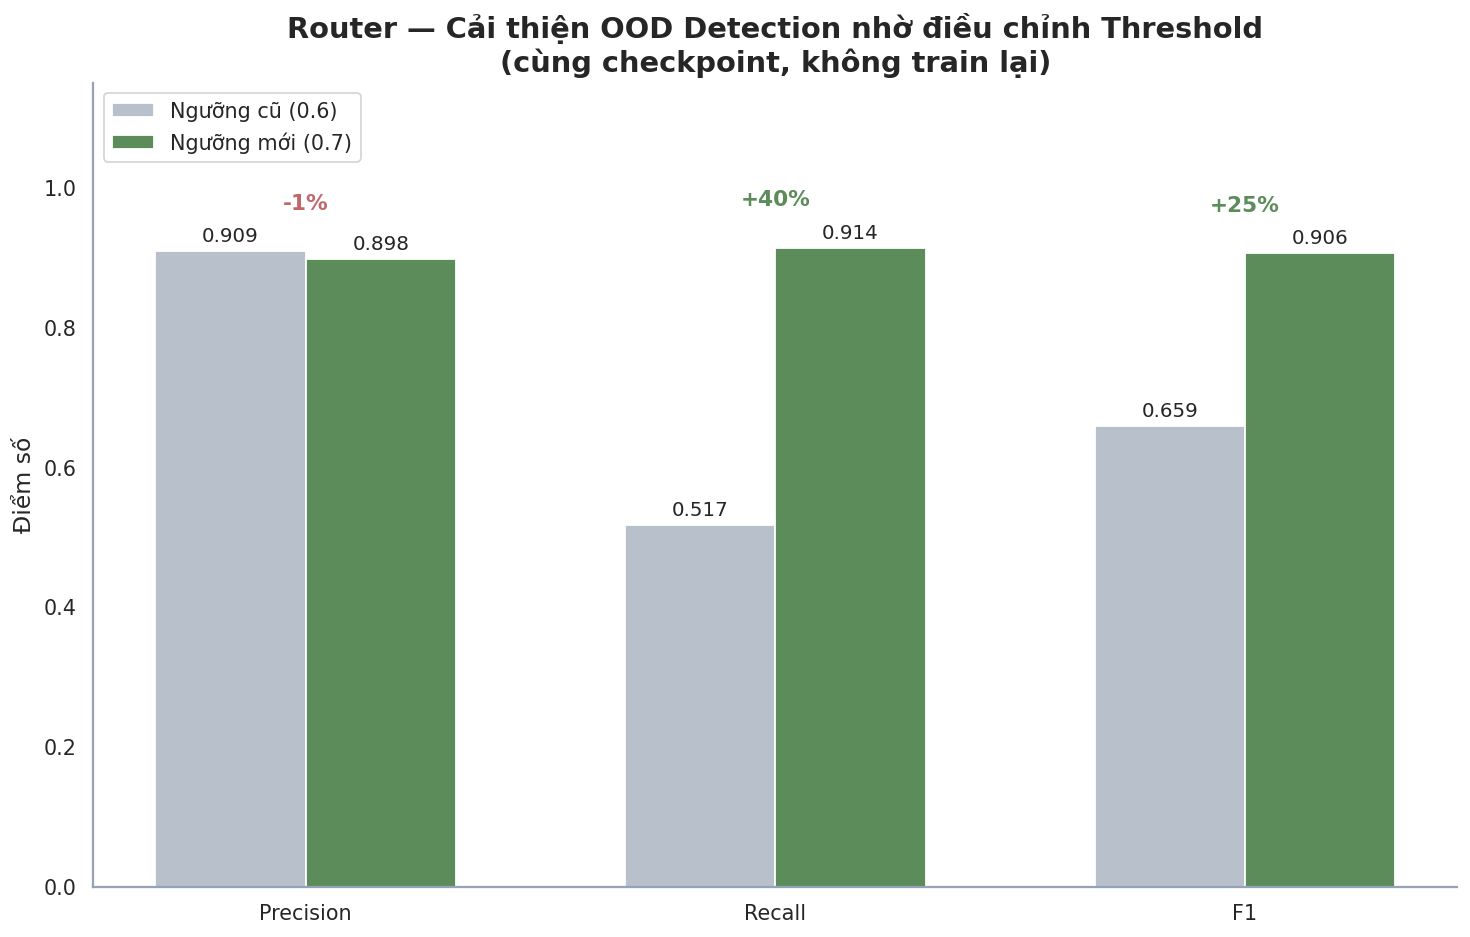

In [3]:
# --- Hình 1.1: Contribution — Cải thiện F1 chỉ nhờ điều chỉnh ngưỡng OOD (không cần train lại) ---
metrics_names = ["Precision", "Recall", "F1"]
before_vals = [ood_old["precision"], ood_old["recall"], ood_old["f1"]]
after_vals = [ood_new["precision"], ood_new["recall"], ood_new["f1"]]

x = np.arange(len(metrics_names))
width = 0.32

fig, ax = plt.subplots(figsize=(11.5, 7.4))
b1 = ax.bar(x - width/2, before_vals, width, label=f"Ngưỡng cũ ({ood_old['ood_threshold']})", color=BEFORE_AFTER_PALETTE[0])
b2 = ax.bar(x + width/2, after_vals, width, label=f"Ngưỡng mới ({ood_new['ood_threshold']})", color=BEFORE_AFTER_PALETTE[2])
annotate_bars(ax, fmt="%.3f")

for i, (bv, av) in enumerate(zip(before_vals, after_vals)):
    delta = av - bv
    if abs(delta) > 0.01:
        ax.annotate(f"{delta:+.0%}", xy=(i, max(bv, av) + 0.06), ha="center",
                     fontsize=12, fontweight="bold", color=PALETTE["success"] if delta > 0 else PALETTE["danger"])

ax.set_xticks(x); ax.set_xticklabels(metrics_names)
ax.set_ylim(0, 1.15)
ax.set_ylabel("Điểm số")
ax.set_title("Router — Cải thiện OOD Detection nhờ điều chỉnh Threshold\n(cùng checkpoint, không train lại)")
ax.legend(loc="upper left")
plt.tight_layout()
plt.show()


**Contribution nổi bật:** Chỉ bằng cách nâng ngưỡng OOD từ **0.6 → 0.7**, Recall tăng vọt từ **51.7% → 91.4%**
(F1: 0.659 → 0.906), mà không cần huấn luyện lại model. Đánh đổi là Precision giảm nhẹ (90.9% → 89.8%) — hợp lý về
mặt lâm sàng vì bỏ sót một ảnh OOD (đưa nhầm vào pipeline chẩn đoán) rủi ro hơn nhiều so với việc từ chối oan một ảnh hợp lệ.


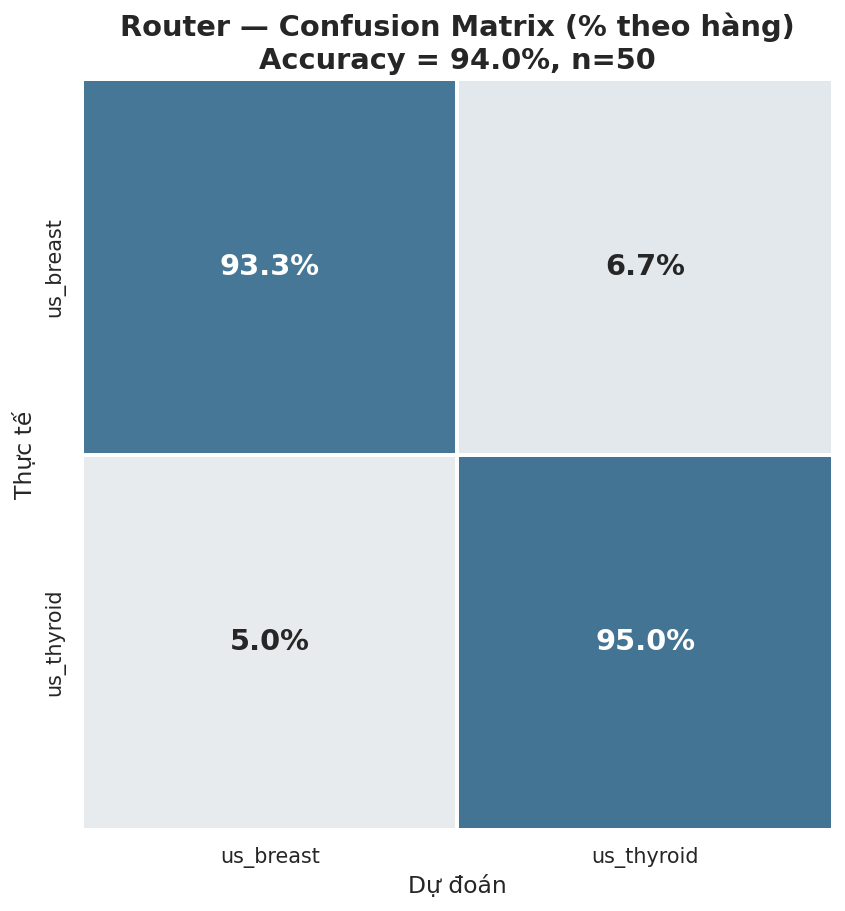

In [4]:
# --- Hình 1.2: Confusion matrix phân loại Router (breast vs thyroid), dạng tỉ lệ % ---
labels = idc["confusion_matrix"]["labels"]
cm = np.array(idc["confusion_matrix"]["matrix"])
cm_pct = cm / cm.sum(axis=1, keepdims=True) * 100

fig, ax = plt.subplots(figsize=(8.5, 7.2))
sns.heatmap(cm_pct, annot=True, fmt=".1f", cmap=SEQ_CMAP, cbar=False,
            xticklabels=labels, yticklabels=labels, ax=ax,
            linewidths=2, linecolor="white", annot_kws={"size": 16, "weight": "bold"},
            vmin=0, vmax=100, square=True)
for t in ax.texts:
    t.set_text(t.get_text() + "%")
ax.set_xlabel("Dự đoán"); ax.set_ylabel("Thực tế")
ax.set_title(f"Router — Confusion Matrix (% theo hàng)\nAccuracy = {idc['accuracy']:.1%}, n={idc['n_samples']}")
plt.tight_layout()
plt.show()


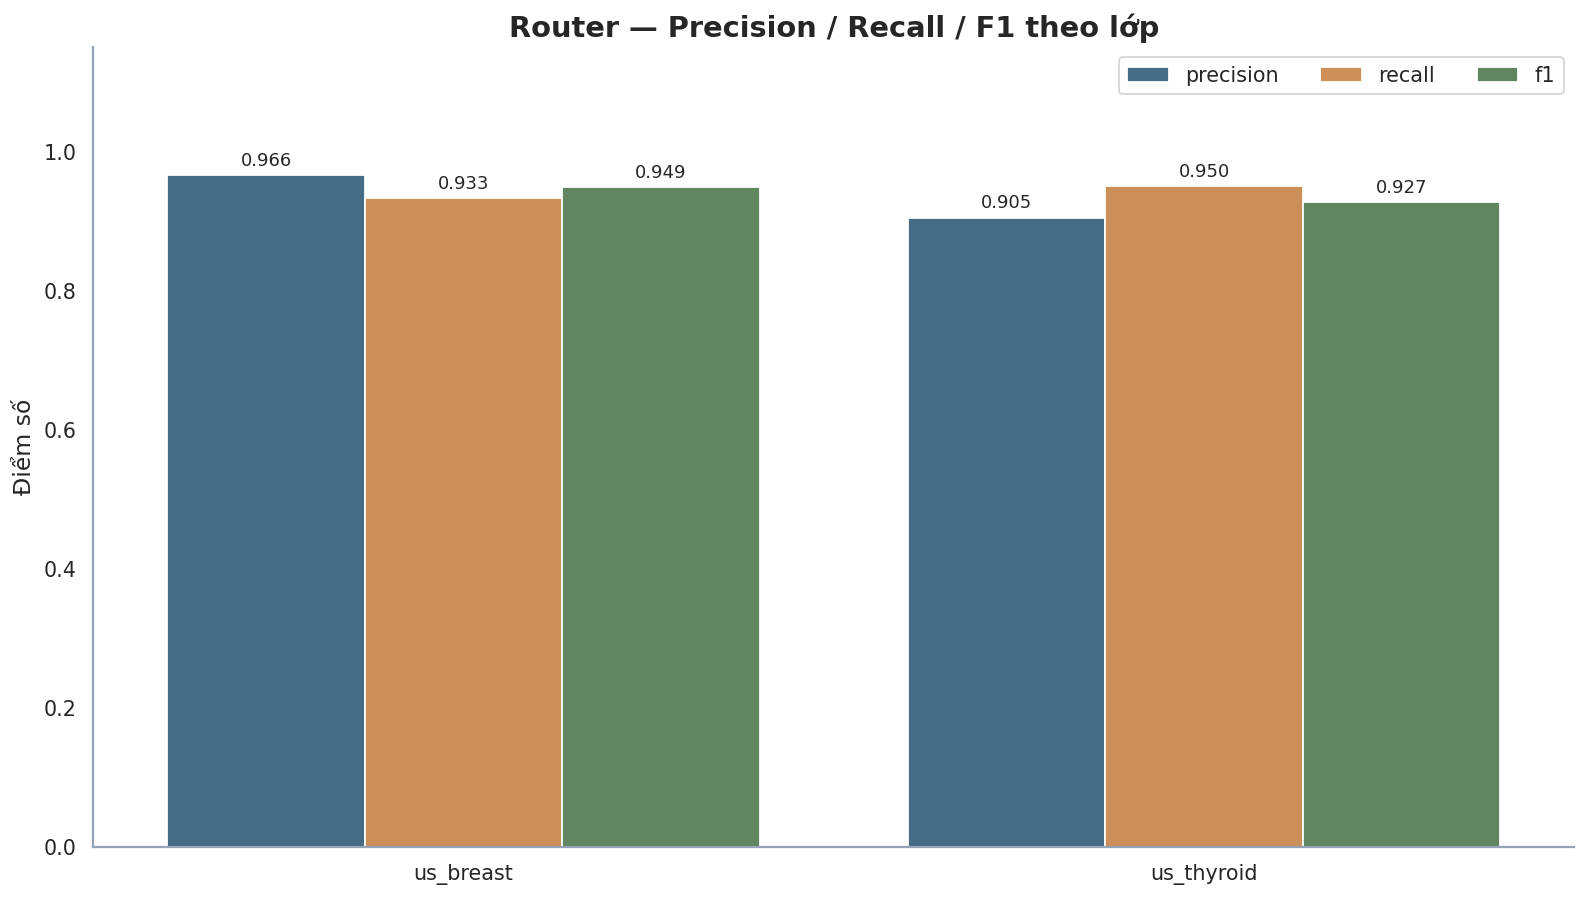

In [5]:
# --- Hình 1.3: Precision / Recall / F1 theo lớp (breast/thyroid) ---
per_class = idc["per_class"]
df_pc = pd.DataFrame(per_class).T.reset_index().rename(columns={"index": "class"})
df_pc_melt = df_pc.melt(id_vars=["class", "support"], value_vars=["precision", "recall", "f1"],
                         var_name="metric", value_name="score")

fig, ax = plt.subplots(figsize=(12.4, 7.1))
sns.barplot(data=df_pc_melt, x="class", y="score", hue="metric", ax=ax,
            palette=[PALETTE["primary"], PALETTE["secondary"], PALETTE["success"]])
annotate_bars(ax, fontsize=10)
ax.set_ylim(0, 1.15)
ax.set_ylabel("Điểm số"); ax.set_xlabel("")
ax.set_title("Router — Precision / Recall / F1 theo lớp")
ax.legend(title="", loc="upper right", ncol=3)
plt.tight_layout()
plt.show()


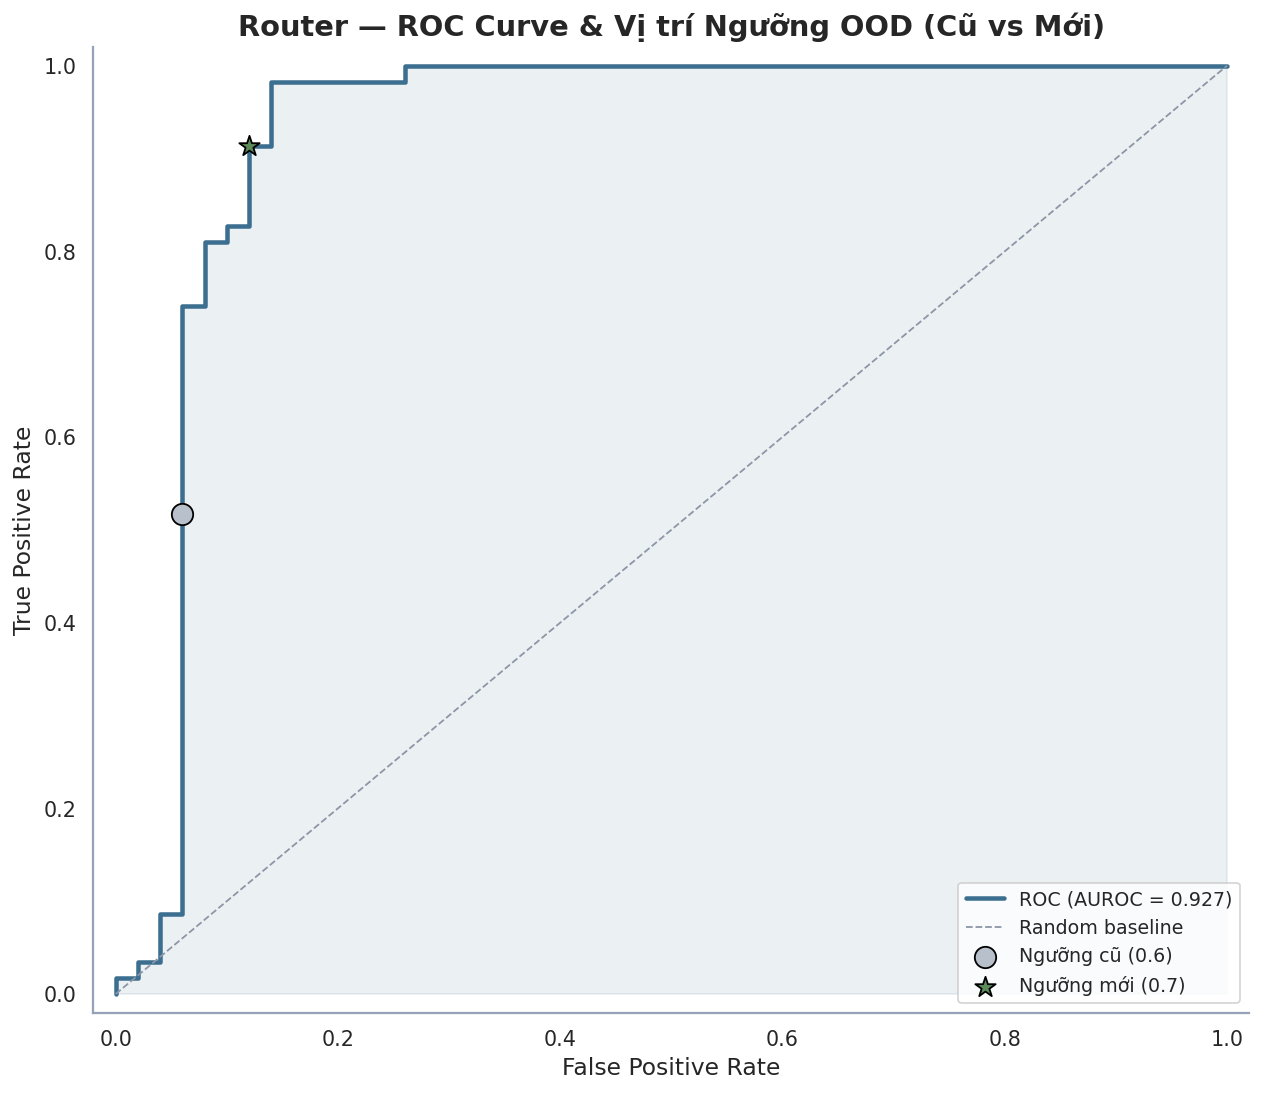

FPR @ 95% TPR: 14.00%


In [6]:
# --- Hình 1.4: ROC Curve cho OOD detection + vị trí 2 ngưỡng (cũ vs mới) ---
roc = pd.DataFrame(router_new["ood_detection"]["roc_curve"]).replace([np.inf, -np.inf], np.nan)
auroc = router_new["ood_detection"]["auroc"]

fig, ax = plt.subplots(figsize=(9.9, 8.6))
ax.plot(roc["fpr"], roc["tpr"], color=PALETTE["primary"], linewidth=2.5, label=f"ROC (AUROC = {auroc:.3f})")
ax.plot([0, 1], [0, 1], linestyle="--", color=PALETTE["neutral"], linewidth=1, label="Random baseline")
ax.fill_between(roc["fpr"], roc["tpr"], alpha=0.10, color=PALETTE["primary"])

fpr_old = ood_old["fp"] / (ood_old["fp"] + ood_old["tn"])
fpr_new = ood_new["fp"] / (ood_new["fp"] + ood_new["tn"])
ax.scatter([fpr_old], [ood_old["recall"]], color=BEFORE_AFTER_PALETTE[0], zorder=5, s=140,
           edgecolor="black", linewidth=1, label=f"Ngưỡng cũ ({ood_old['ood_threshold']})")
ax.scatter([fpr_new], [ood_new["recall"]], color=BEFORE_AFTER_PALETTE[2], zorder=5, s=140,
           marker="*", edgecolor="black", linewidth=1, label=f"Ngưỡng mới ({ood_new['ood_threshold']})")

ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("Router — ROC Curve & Vị trí Ngưỡng OOD (Cũ vs Mới)")
ax.legend(loc="lower right", fontsize=10.5)
ax.set_xlim(-0.02, 1.02); ax.set_ylim(-0.02, 1.02)
plt.tight_layout()
plt.show()

print(f"FPR @ 95% TPR: {router_new['ood_detection']['fpr_at_95tpr']:.2%}")


**Nhận xét — Router:** Mô hình router (EfficientNet-B0) đạt accuracy **94%** phân loại breast/thyroid, macro F1 **0.938**.
Việc chỉ điều chỉnh ngưỡng OOD (không cần train lại) đã cải thiện đáng kể khả năng phát hiện ảnh ngoài phân phối —
một minh chứng rõ ràng cho việc tinh chỉnh vận hành (operational tuning) đôi khi mang lại lợi ích lớn hơn thay đổi model.


## 2. Vision Model (Multi-Task: Segmentation + Classification)

Mô hình thị giác đa nhiệm (backbone EfficientNet-B4, đầu ra segmentation dạng U-Net + đầu phân loại) được đánh giá
riêng trên 2 bộ dữ liệu: **BUSI** (breast) và **TN3K** (thyroid).


In [7]:
vision_eval = load_json(RESULTS_DIR / "vision" / "vision_eval.json")

rows = []
for dataset_key, d in vision_eval.items():
    seg = d["segmentation"]["lesion_samples"]
    cls = d["classification"]
    rows.append({
        "dataset": d["classification"]["dataset"],
        "params_M": d["model_parameters"]["total_M"],
        "gmacs": d["flops"]["gmacs"],
        "dice_mean": seg["dice"]["mean"],
        "dice_median": seg["dice"]["median"],
        "iou_mean": seg["iou"]["mean"],
        "iou_median": seg["iou"]["median"],
        "cls_accuracy": cls["accuracy"],
        "cls_macro_f1": cls.get("macro_f1", cls.get("binary_f1")),
        "n_seg_samples": seg["dice"]["n"],
        "n_cls_samples": cls["n_samples"],
        "inference_ms_mean": d["inference_time"]["forward_only"]["mean_ms"],
    })
df_vision = pd.DataFrame(rows)
df_vision


,dataset,params_M,gmacs,dice_mean,dice_median,iou_mean,iou_median,cls_accuracy,cls_macro_f1,n_seg_samples,n_cls_samples,inference_ms_mean
0,BUSI,18.13,2.738,0.6357,0.7439,0.5158,0.5922,0.8000,0.8078,86,115,127.27
1,TN3K,18.13,2.738,0.7720,0.8405,0.6686,0.7249,0.7228,0.7225,101,101,131.01


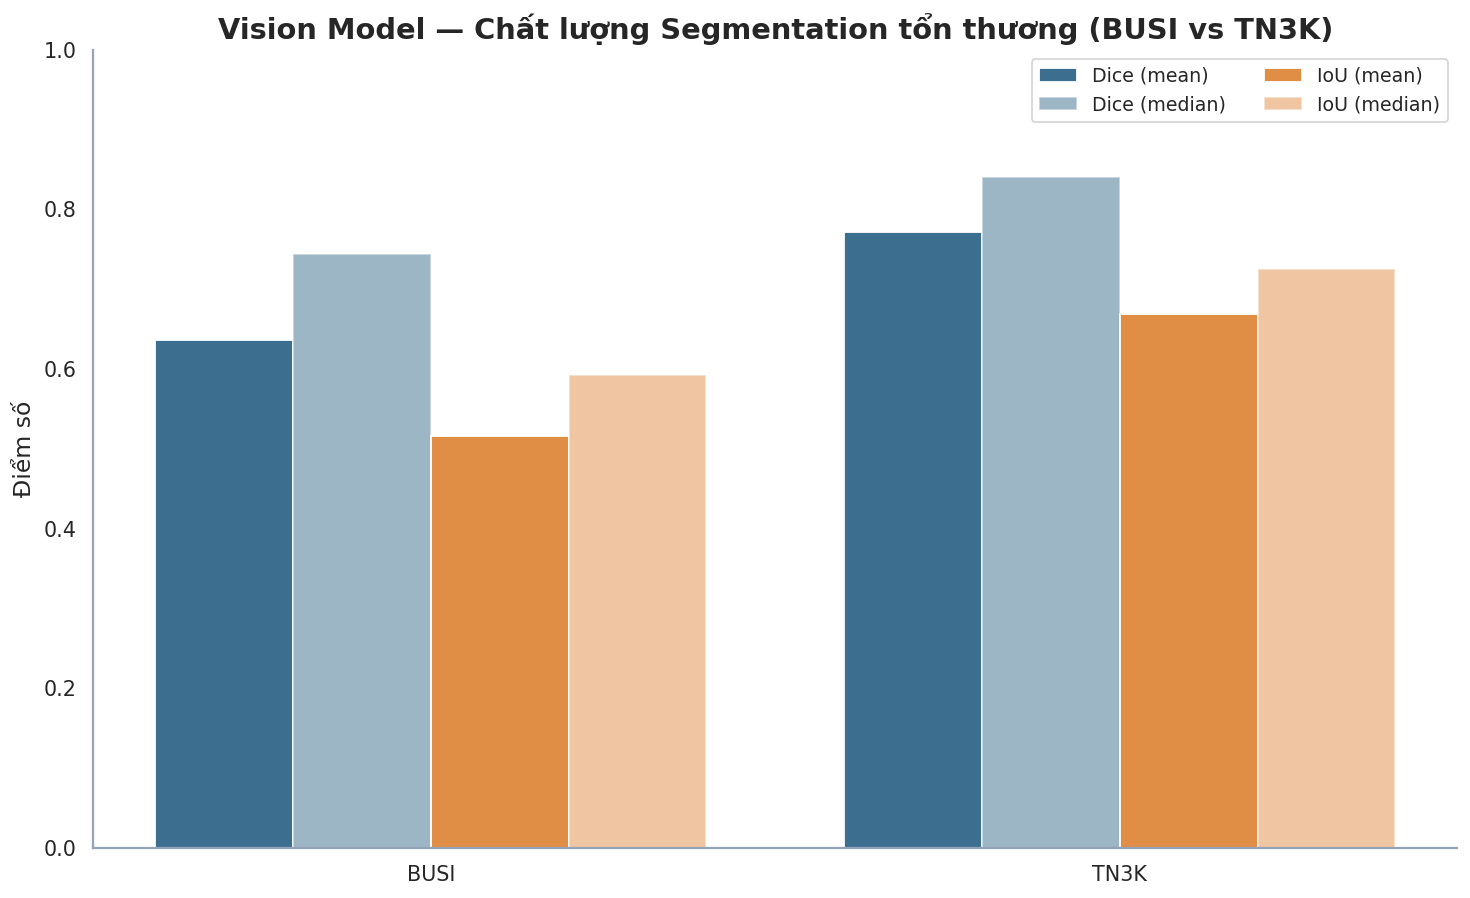

In [8]:
# --- Hình 2.1: So sánh Dice / IoU segmentation giữa 2 dataset ---
fig, ax = plt.subplots(figsize=(11.5, 7.1))
x = np.arange(len(df_vision))
width = 0.2

ax.bar(x - 1.5*width, df_vision["dice_mean"], width, label="Dice (mean)", color=PALETTE["primary"])
ax.bar(x - 0.5*width, df_vision["dice_median"], width, label="Dice (median)", color=PALETTE["primary"], alpha=0.5)
ax.bar(x + 0.5*width, df_vision["iou_mean"], width, label="IoU (mean)", color=PALETTE["secondary"])
ax.bar(x + 1.5*width, df_vision["iou_median"], width, label="IoU (median)", color=PALETTE["secondary"], alpha=0.5)

ax.set_xticks(x); ax.set_xticklabels(df_vision["dataset"])
ax.set_ylim(0, 1)
ax.set_ylabel("Điểm số")
ax.set_title("Vision Model — Chất lượng Segmentation tổn thương (BUSI vs TN3K)")
ax.legend(ncol=2, fontsize=10.5)
plt.tight_layout()
plt.show()


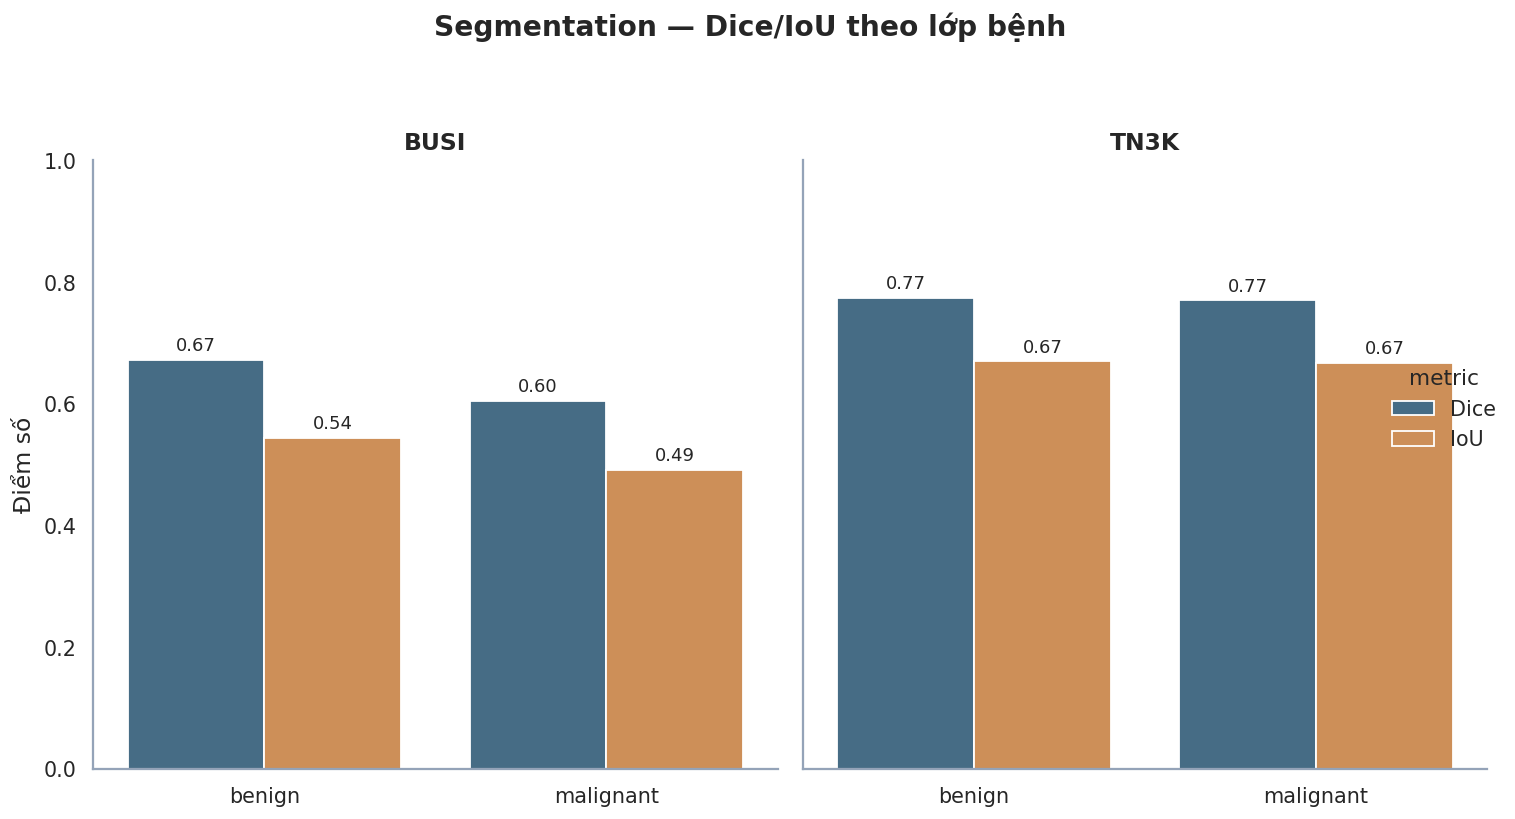

In [9]:
# --- Hình 2.2: Dice/IoU theo lớp bệnh (benign vs malignant) cho từng dataset ---
rows = []
for dataset_key, d in vision_eval.items():
    dset = d["classification"]["dataset"]
    for cls_name, vals in d["segmentation"]["per_class_seg"].items():
        rows.append({"dataset": dset, "class": cls_name, "metric": "Dice", "value": vals["dice"]["mean"]})
        rows.append({"dataset": dset, "class": cls_name, "metric": "IoU", "value": vals["iou"]["mean"]})
df_seg_class = pd.DataFrame(rows)

g = sns.catplot(data=df_seg_class, x="class", y="value", hue="metric", col="dataset",
                 kind="bar", palette=[PALETTE["primary"], PALETTE["secondary"]],
                 height=6, aspect=0.9, legend_out=True)
g.set_axis_labels("", "Điểm số")
g.set_titles("{col_name}")
for ax in g.axes.flat:
    ax.set_ylim(0, 1)
    annotate_bars(ax, fmt="%.2f", fontsize=10)
g.figure.suptitle("Segmentation — Dice/IoU theo lớp bệnh", y=1.05, fontweight="bold")
plt.tight_layout()
plt.show()


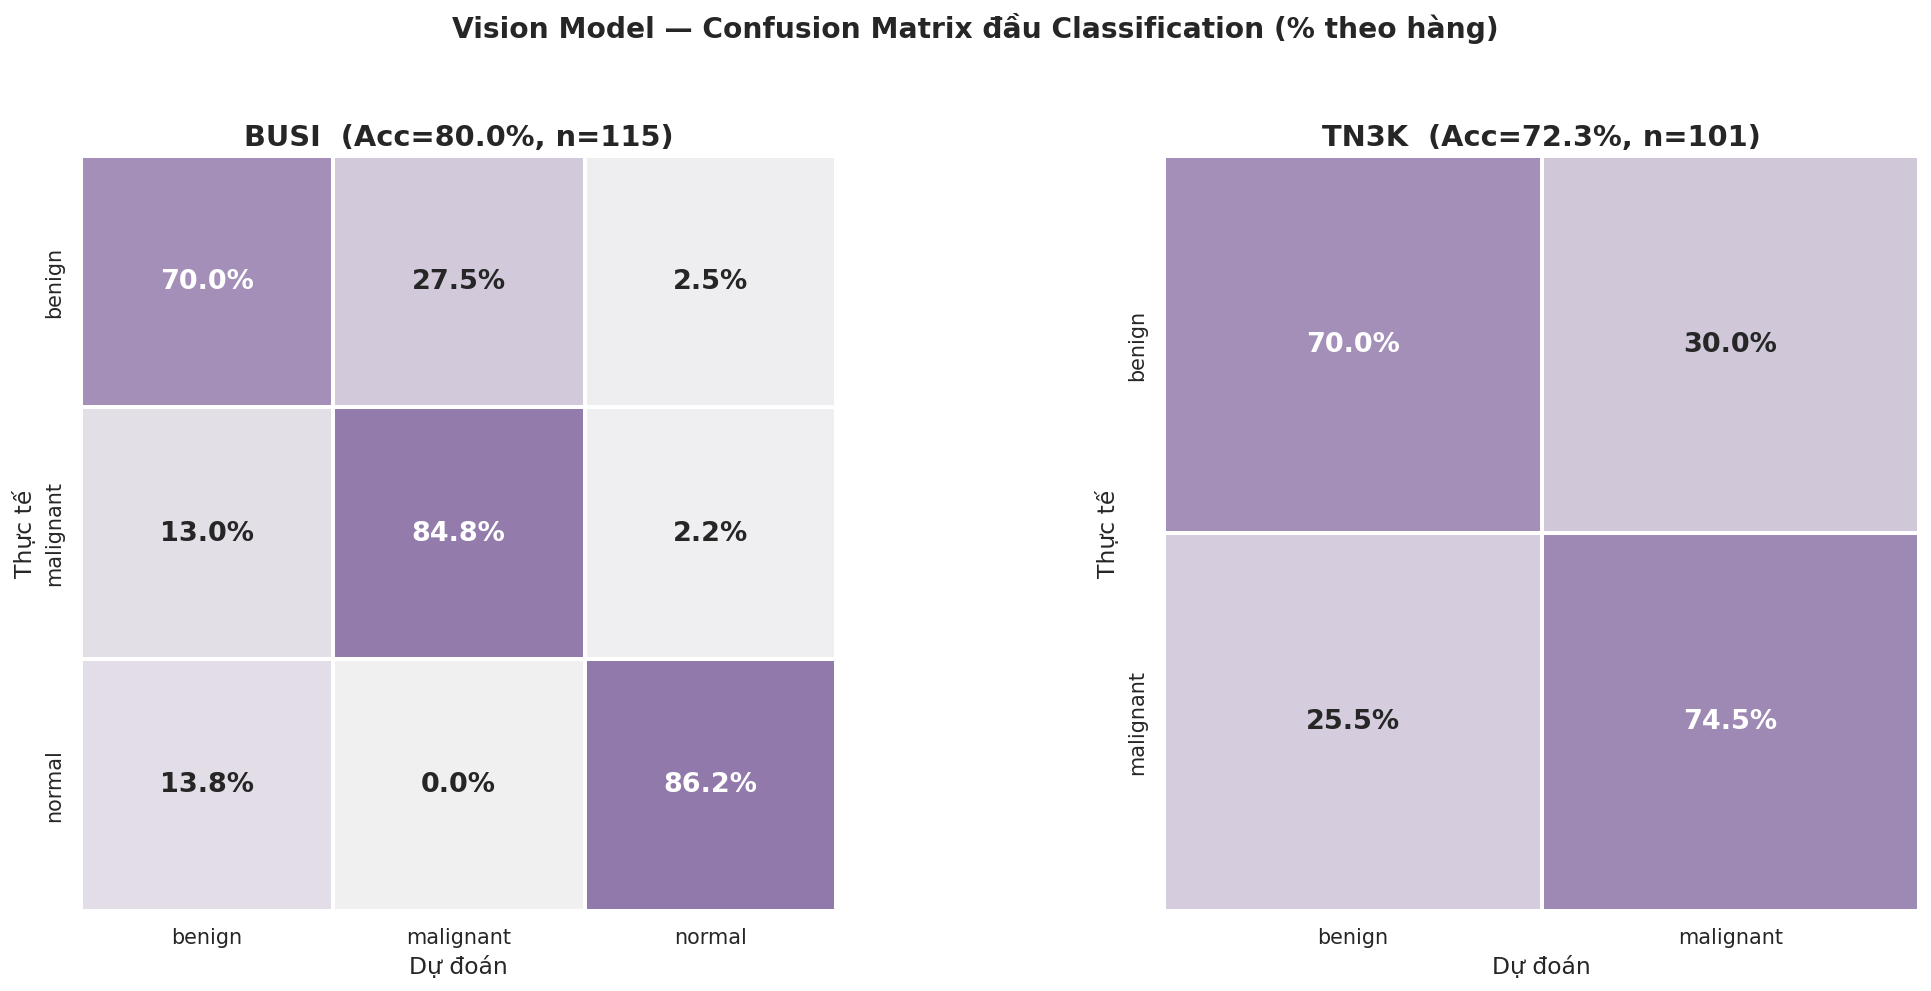

In [10]:
# --- Hình 2.3: Confusion matrix Classification (đầu phân loại của Vision Model), dạng tỉ lệ % ---
purple_cmap = sns.light_palette("#8266A0", as_cmap=True)
fig, axes = plt.subplots(1, 2, figsize=(17.0, 7.4))
for ax, (dataset_key, d) in zip(axes, vision_eval.items()):
    cls = d["classification"]
    labels = cls["confusion_matrix"]["labels"]
    cm = np.array(cls["confusion_matrix"]["matrix"])
    cm_pct = cm / cm.sum(axis=1, keepdims=True) * 100
    sns.heatmap(cm_pct, annot=True, fmt=".1f", cmap=purple_cmap, cbar=False,
                xticklabels=labels, yticklabels=labels, ax=ax,
                linewidths=2, linecolor="white", annot_kws={"size": 15, "weight": "bold"},
                vmin=0, vmax=100, square=True)
    for t in ax.texts:
        t.set_text(t.get_text() + "%")
    ax.set_title(f"{cls['dataset']}  (Acc={cls['accuracy']:.1%}, n={cls['n_samples']})")
    ax.set_xlabel("Dự đoán"); ax.set_ylabel("Thực tế")
fig.suptitle("Vision Model — Confusion Matrix đầu Classification (% theo hàng)", y=1.03, fontweight="bold")
plt.tight_layout()
plt.show()


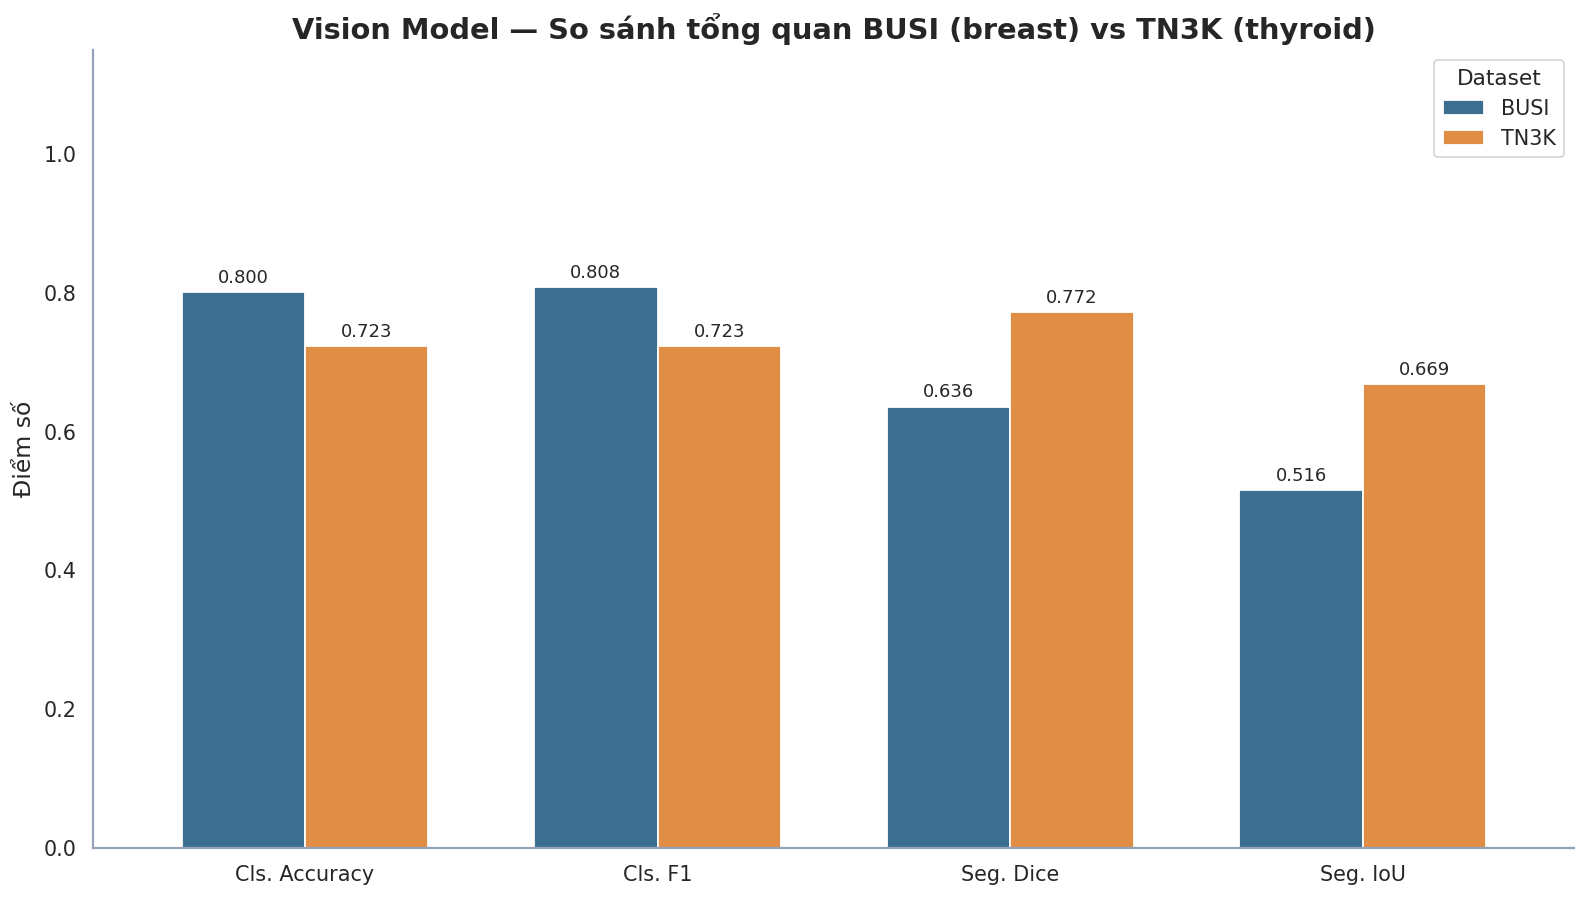

In [11]:
# --- Hình 2.4: So sánh hiệu năng tổng quan (accuracy, Dice, IoU, F1) giữa 2 dataset ---
metrics_compare = df_vision.set_index("dataset")[["cls_accuracy", "cls_macro_f1", "dice_mean", "iou_mean"]]
metrics_compare.columns = ["Cls. Accuracy", "Cls. F1", "Seg. Dice", "Seg. IoU"]

fig, ax = plt.subplots(figsize=(12.4, 7.1))
metrics_compare.T.plot(kind="bar", ax=ax, color=[PALETTE["primary"], PALETTE["secondary"]], width=0.7)
annotate_bars(ax, fontsize=10)
ax.set_ylim(0, 1.15)
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
ax.set_ylabel("Điểm số")
ax.set_title("Vision Model — So sánh tổng quan BUSI (breast) vs TN3K (thyroid)")
ax.legend(title="Dataset")
plt.tight_layout()
plt.show()


**Nhận xét — Vision Model:** Segmentation tốt hơn rõ rệt trên **TN3K/thyroid** (Dice mean 0.772) so với
**BUSI/breast** (Dice mean 0.636). Ngược lại, classification nghiêng về breast (80% vs 72.3%) — bài toán 3 lớp trên
BUSI được hỗ trợ tốt nhờ lớp "normal" dễ nhận diện, trong khi bài toán nhị phân trên TN3K khó phân biệt hơn.


## 3. Chain-of-Thought (CoT) Reasoning — Ma trận đầy đủ Model × Prompt Strategy

Với đợt đánh giá đầy đủ, ta có **4 cấu hình** tạo thành ma trận 2×2, cho phép tách bạch rõ ràng
**đóng góp của việc đổi model LLM** và **đóng góp của việc thêm prompt BIRADS**:

| | Prompt chuẩn | Prompt + BIRADS |
|---|---|---|
| **Gemini** | `cot_gemini` | `cot_gemini_birads` |
| **GPT** | `cot_gpt` | `cot_gpt_birads` |


In [12]:
cot_configs = {
    "Gemini (chuẩn)": {"path": RESULTS_DIR / "cot_gemini" / "cot_eval_summary.json", "model": "Gemini", "prompt": "Chuẩn"},
    "Gemini + BIRADS": {"path": RESULTS_DIR / "cot_gemini_birads" / "cot_eval_summary.json", "model": "Gemini", "prompt": "BIRADS"},
    "GPT (chuẩn)": {"path": RESULTS_DIR / "cot_gpt" / "cot_eval_summary.json", "model": "GPT", "prompt": "Chuẩn"},
    "GPT + BIRADS": {"path": RESULTS_DIR / "cot_gpt_birads" / "cot_eval_summary.json", "model": "GPT", "prompt": "BIRADS"},
}

rows = []
for cfg_name, meta in cot_configs.items():
    data = load_json(meta["path"])
    for ds_key, ds in data.items():
        gt = ds["cot_vs_ground_truth"]
        cnn = ds["cot_vs_cnn"]
        rows.append({
            "config": cfg_name, "model": meta["model"], "prompt": meta["prompt"],
            "dataset": ds["dataset"], "organ": ds["organ"], "n_total": ds["n_total"],
            "macro_f1": gt["macro_f1"], "macro_precision": gt["macro_precision"],
            "macro_recall": gt["macro_recall"], "weighted_f1": gt["weighted_f1"],
            "cohen_kappa_cnn": cnn["cohen_kappa_cnn_vs_cot"],
            "label_agreement_pct": cnn["label_agreement"]["true_pct"],
            "hard_conflict_pct": cnn["hard_conflict"]["true_pct"],
            "latency_mean_ms": ds["latency_cot_ms"]["mean"],
            "latency_median_ms": ds["latency_cot_ms"]["median"],
            "latency_p95_ms": ds["latency_cot_ms"]["p95"],
        })
df_cot = pd.DataFrame(rows)
df_cot


,config,model,prompt,dataset,organ,n_total,macro_f1,macro_precision,macro_recall,weighted_f1,cohen_kappa_cnn,label_agreement_pct,hard_conflict_pct,latency_mean_ms,latency_median_ms,latency_p95_ms
0,Gemini (chuẩn),Gemini,Chuẩn,BUSI,breast,106,0.7755,0.8267,0.7858,0.7580,0.4608,64.15,30.19,7196.57,1403.70,38212.30
1,Gemini (chuẩn),Gemini,Chuẩn,TN3K,thyroid,102,0.5335,0.5982,0.5686,0.5335,0.1832,57.84,42.16,7069.30,1493.82,38047.79
2,Gemini + BIRADS,Gemini,BIRADS,BUSI,breast,50,0.8292,0.8342,0.8268,0.7978,0.5336,72.00,22.00,10317.25,1857.60,44127.58
3,Gemini + BIRADS,Gemini,BIRADS,TN3K,thyroid,50,0.7565,0.7667,0.7564,0.7577,0.4531,72.00,28.00,10317.11,2084.94,43946.44
4,GPT (chuẩn),GPT,Chuẩn,BUSI,breast,115,0.6646,0.7587,0.7141,0.6155,0.3241,53.91,40.87,4239.82,3555.52,5860.05
5,GPT (chuẩn),GPT,Chuẩn,TN3K,thyroid,102,0.5414,0.6159,0.5784,0.5414,0.2031,58.82,41.18,3833.85,3460.32,5217.82
6,GPT + BIRADS,GPT,BIRADS,BUSI,breast,115,0.8449,0.8456,0.8464,0.8263,0.5888,73.04,22.61,4320.68,4014.21,6383.21
7,GPT + BIRADS,GPT,BIRADS,TN3K,thyroid,102,0.5571,0.6555,0.5980,0.5571,0.2049,58.82,41.18,4919.66,4325.72,8416.51


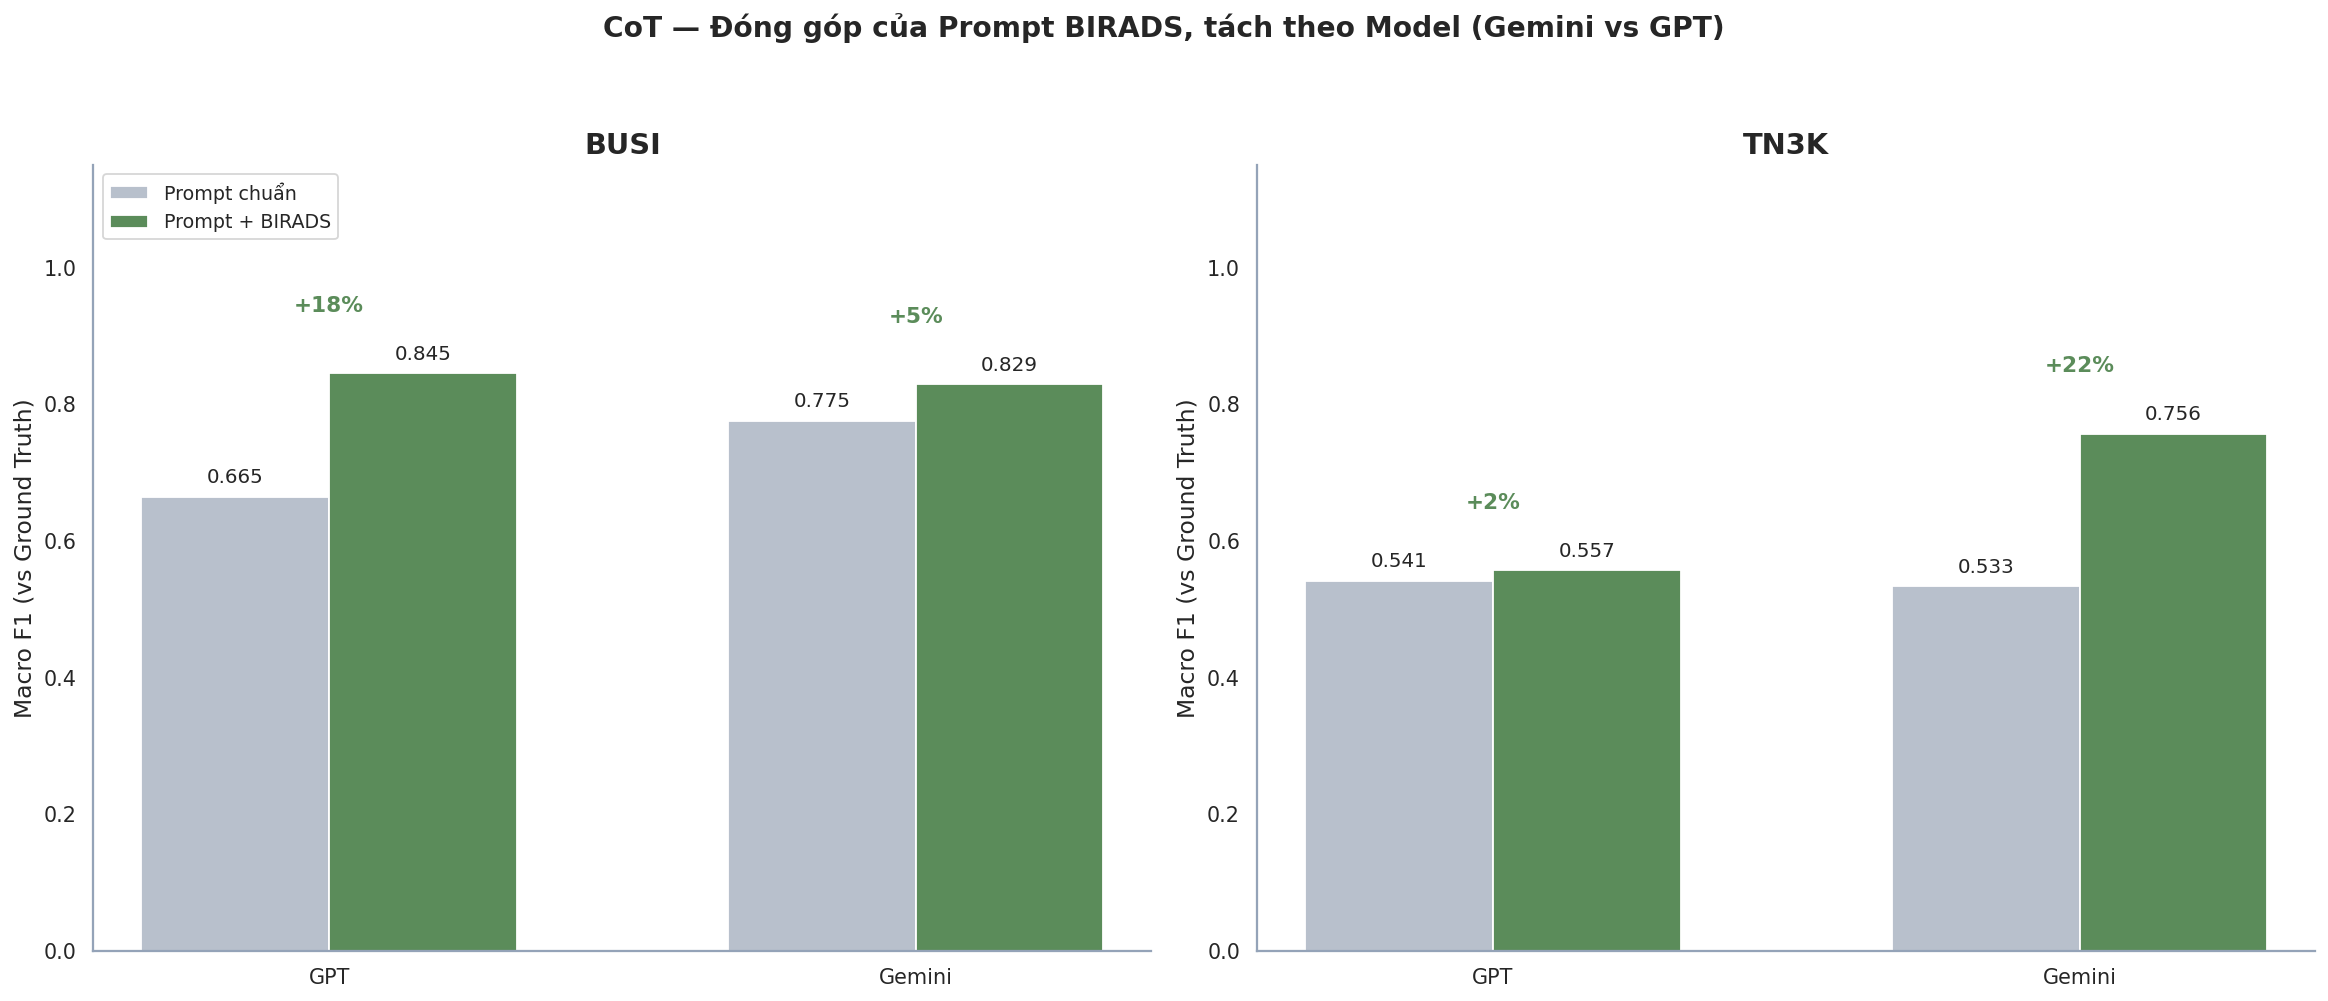

In [13]:
# --- Hình 3.1: Macro F1 — Ma trận 2x2 đầy đủ (Model x Prompt Strategy) ---
fig, axes = plt.subplots(1, 2, figsize=(18.1, 7.4))

for ax, dataset_name in zip(axes, ["BUSI", "TN3K"]):
    sub = df_cot[df_cot["dataset"] == dataset_name]
    pivot = sub.pivot(index="model", columns="prompt", values="macro_f1")[["Chuẩn", "BIRADS"]]
    x = np.arange(len(pivot.index))
    width = 0.32
    ax.bar(x - width/2, pivot["Chuẩn"], width, label="Prompt chuẩn", color=BEFORE_AFTER_PALETTE[0])
    ax.bar(x + width/2, pivot["BIRADS"], width, label="Prompt + BIRADS", color=BEFORE_AFTER_PALETTE[2])
    for i, model in enumerate(pivot.index):
        v0, v1 = pivot.loc[model, "Chuẩn"], pivot.loc[model, "BIRADS"]
        ax.text(i - width/2, v0 + 0.02, f"{v0:.3f}", ha="center", fontsize=11)
        ax.text(i + width/2, v1 + 0.02, f"{v1:.3f}", ha="center", fontsize=11)
        delta = v1 - v0
        color = PALETTE["success"] if delta > 0 else PALETTE["danger"]
        ax.annotate(f"{delta:+.0%}", xy=(i, max(v0, v1) + 0.09), ha="center",
                     fontsize=12, fontweight="bold", color=color)
    ax.set_xticks(x); ax.set_xticklabels(pivot.index)
    ax.set_ylim(0, 1.15)
    ax.set_title(dataset_name)
    ax.set_ylabel("Macro F1 (vs Ground Truth)")

axes[0].legend(loc="upper left", fontsize=10.5)
fig.suptitle("CoT — Đóng góp của Prompt BIRADS, tách theo Model (Gemini vs GPT)", y=1.04, fontweight="bold")
plt.tight_layout()
plt.show()


**Contribution — Prompt BIRADS:** Việc thêm khung suy luận theo tiêu chuẩn BI-RADS cải thiện Macro F1 ở **hầu hết
mọi tổ hợp** — đặc biệt rõ trên TN3K (Gemini: +22pp, GPT: +21pp) và trên BUSI với GPT (+18pp). Đây là bằng chứng
khá nhất quán rằng prompt có cấu trúc lâm sàng chuẩn giúp LLM suy luận chính xác hơn, không phụ thuộc vào model nền.


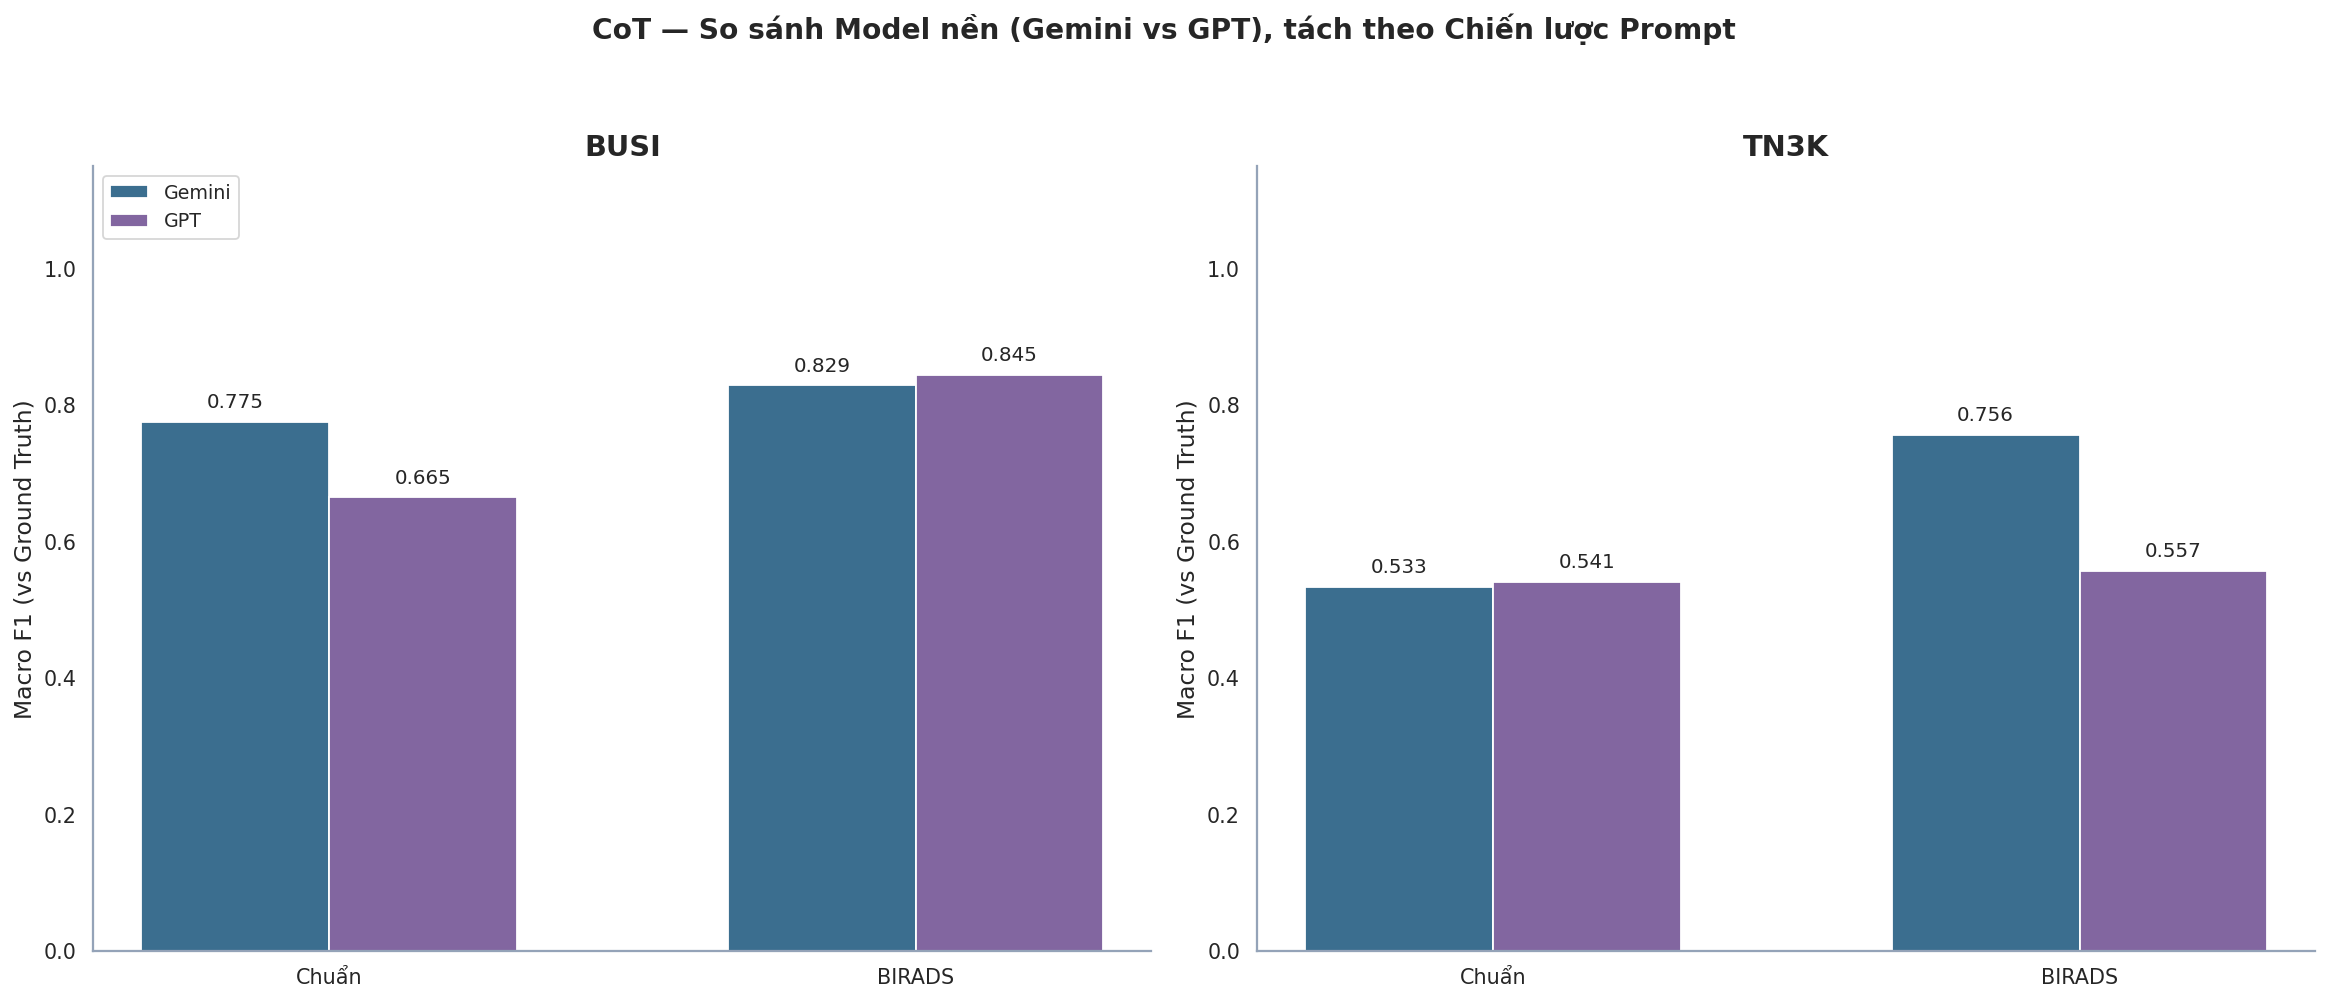

In [14]:
# --- Hình 3.2: Đóng góp của việc đổi Model (Gemini vs GPT), tách theo Prompt Strategy ---
fig, axes = plt.subplots(1, 2, figsize=(18.1, 7.4))

for ax, dataset_name in zip(axes, ["BUSI", "TN3K"]):
    sub = df_cot[df_cot["dataset"] == dataset_name]
    pivot = sub.pivot(index="prompt", columns="model", values="macro_f1").loc[["Chuẩn", "BIRADS"]]
    x = np.arange(len(pivot.index))
    width = 0.32
    ax.bar(x - width/2, pivot["Gemini"], width, label="Gemini", color=PALETTE["primary"])
    ax.bar(x + width/2, pivot["GPT"], width, label="GPT", color=PALETTE["purple"])
    for i, prompt in enumerate(pivot.index):
        v0, v1 = pivot.loc[prompt, "Gemini"], pivot.loc[prompt, "GPT"]
        ax.text(i - width/2, v0 + 0.02, f"{v0:.3f}", ha="center", fontsize=11)
        ax.text(i + width/2, v1 + 0.02, f"{v1:.3f}", ha="center", fontsize=11)
    ax.set_xticks(x); ax.set_xticklabels(pivot.index)
    ax.set_ylim(0, 1.15)
    ax.set_title(dataset_name)
    ax.set_ylabel("Macro F1 (vs Ground Truth)")

axes[0].legend(loc="upper left", fontsize=10.5)
fig.suptitle("CoT — So sánh Model nền (Gemini vs GPT), tách theo Chiến lược Prompt", y=1.04, fontweight="bold")
plt.tight_layout()
plt.show()


**Contribution — Lựa chọn Model:** Sự khác biệt giữa Gemini và GPT nhỏ hơn nhiều so với tác động của prompt BIRADS,
và không có model nào thắng tuyệt đối ở cả 2 dataset — GPT nhỉnh hơn trên BUSI+BIRADS, Gemini nhỉnh hơn trên TN3K+BIRADS.
**Kết luận: prompt BIRADS là đòn bẩy cải thiện chính, việc chọn LLM nền có vai trò thứ yếu.**


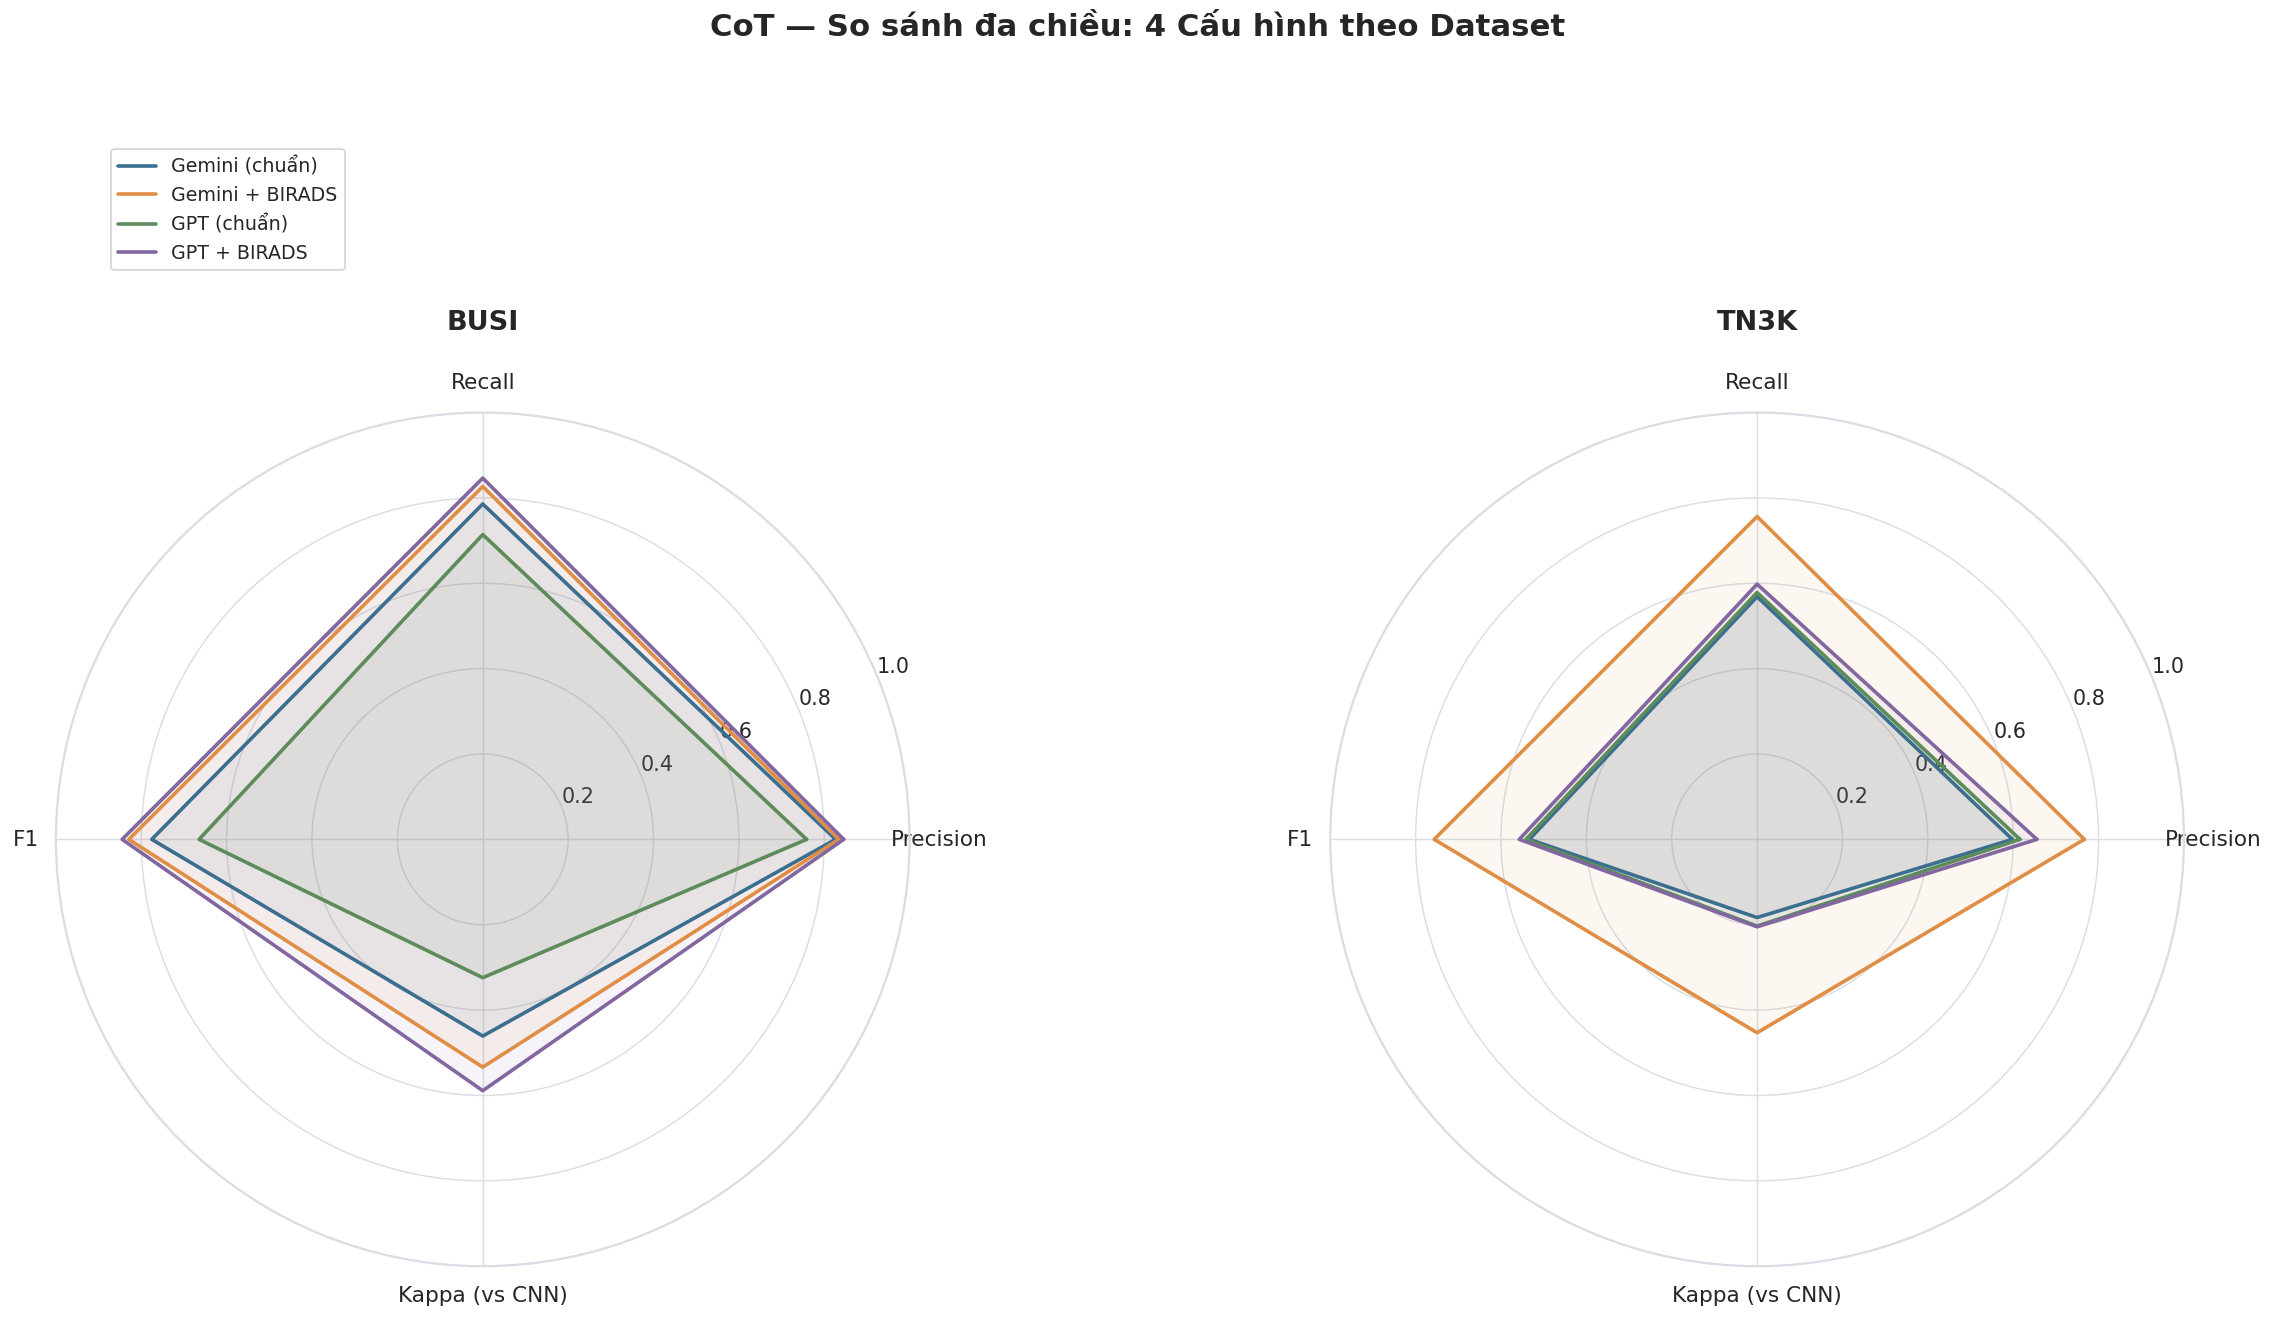

In [15]:
# --- Hình 3.3: Radar chart so sánh 4 cấu hình theo Precision / Recall / F1 / Kappa ---
from math import pi

metrics_radar = ["macro_precision", "macro_recall", "macro_f1", "cohen_kappa_cnn"]
metric_labels = ["Precision", "Recall", "F1", "Kappa (vs CNN)"]

fig, axes = plt.subplots(1, 2, figsize=(19.8, 9.5), subplot_kw=dict(polar=True))

for ax, dataset_name in zip(axes, ["BUSI", "TN3K"]):
    sub = df_cot[df_cot["dataset"] == dataset_name]
    N = len(metrics_radar)
    angles = [n / float(N) * 2 * pi for n in range(N)]
    angles += angles[:1]

    for i, (_, row) in enumerate(sub.iterrows()):
        values = [row[m] for m in metrics_radar]
        values += values[:1]
        ax.plot(angles, values, linewidth=2, label=row["config"], color=CAT_PALETTE[i])
        ax.fill(angles, values, alpha=0.07, color=CAT_PALETTE[i])

    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(metric_labels, fontsize=12)
    ax.set_ylim(0, 1)
    ax.set_title(dataset_name, fontsize=15, fontweight="bold", pad=24)
    ax.grid(True, color="#D9DEE4", linewidth=0.8)
    ax.spines["polar"].set_color("#D9DEE4")
    ax.set_facecolor("white")

axes[0].legend(loc="upper right", bbox_to_anchor=(0.35, 1.32), fontsize=10.5)
fig.suptitle("CoT — So sánh đa chiều: 4 Cấu hình theo Dataset", fontsize=17, fontweight="bold", y=1.05)
plt.tight_layout()
plt.show()


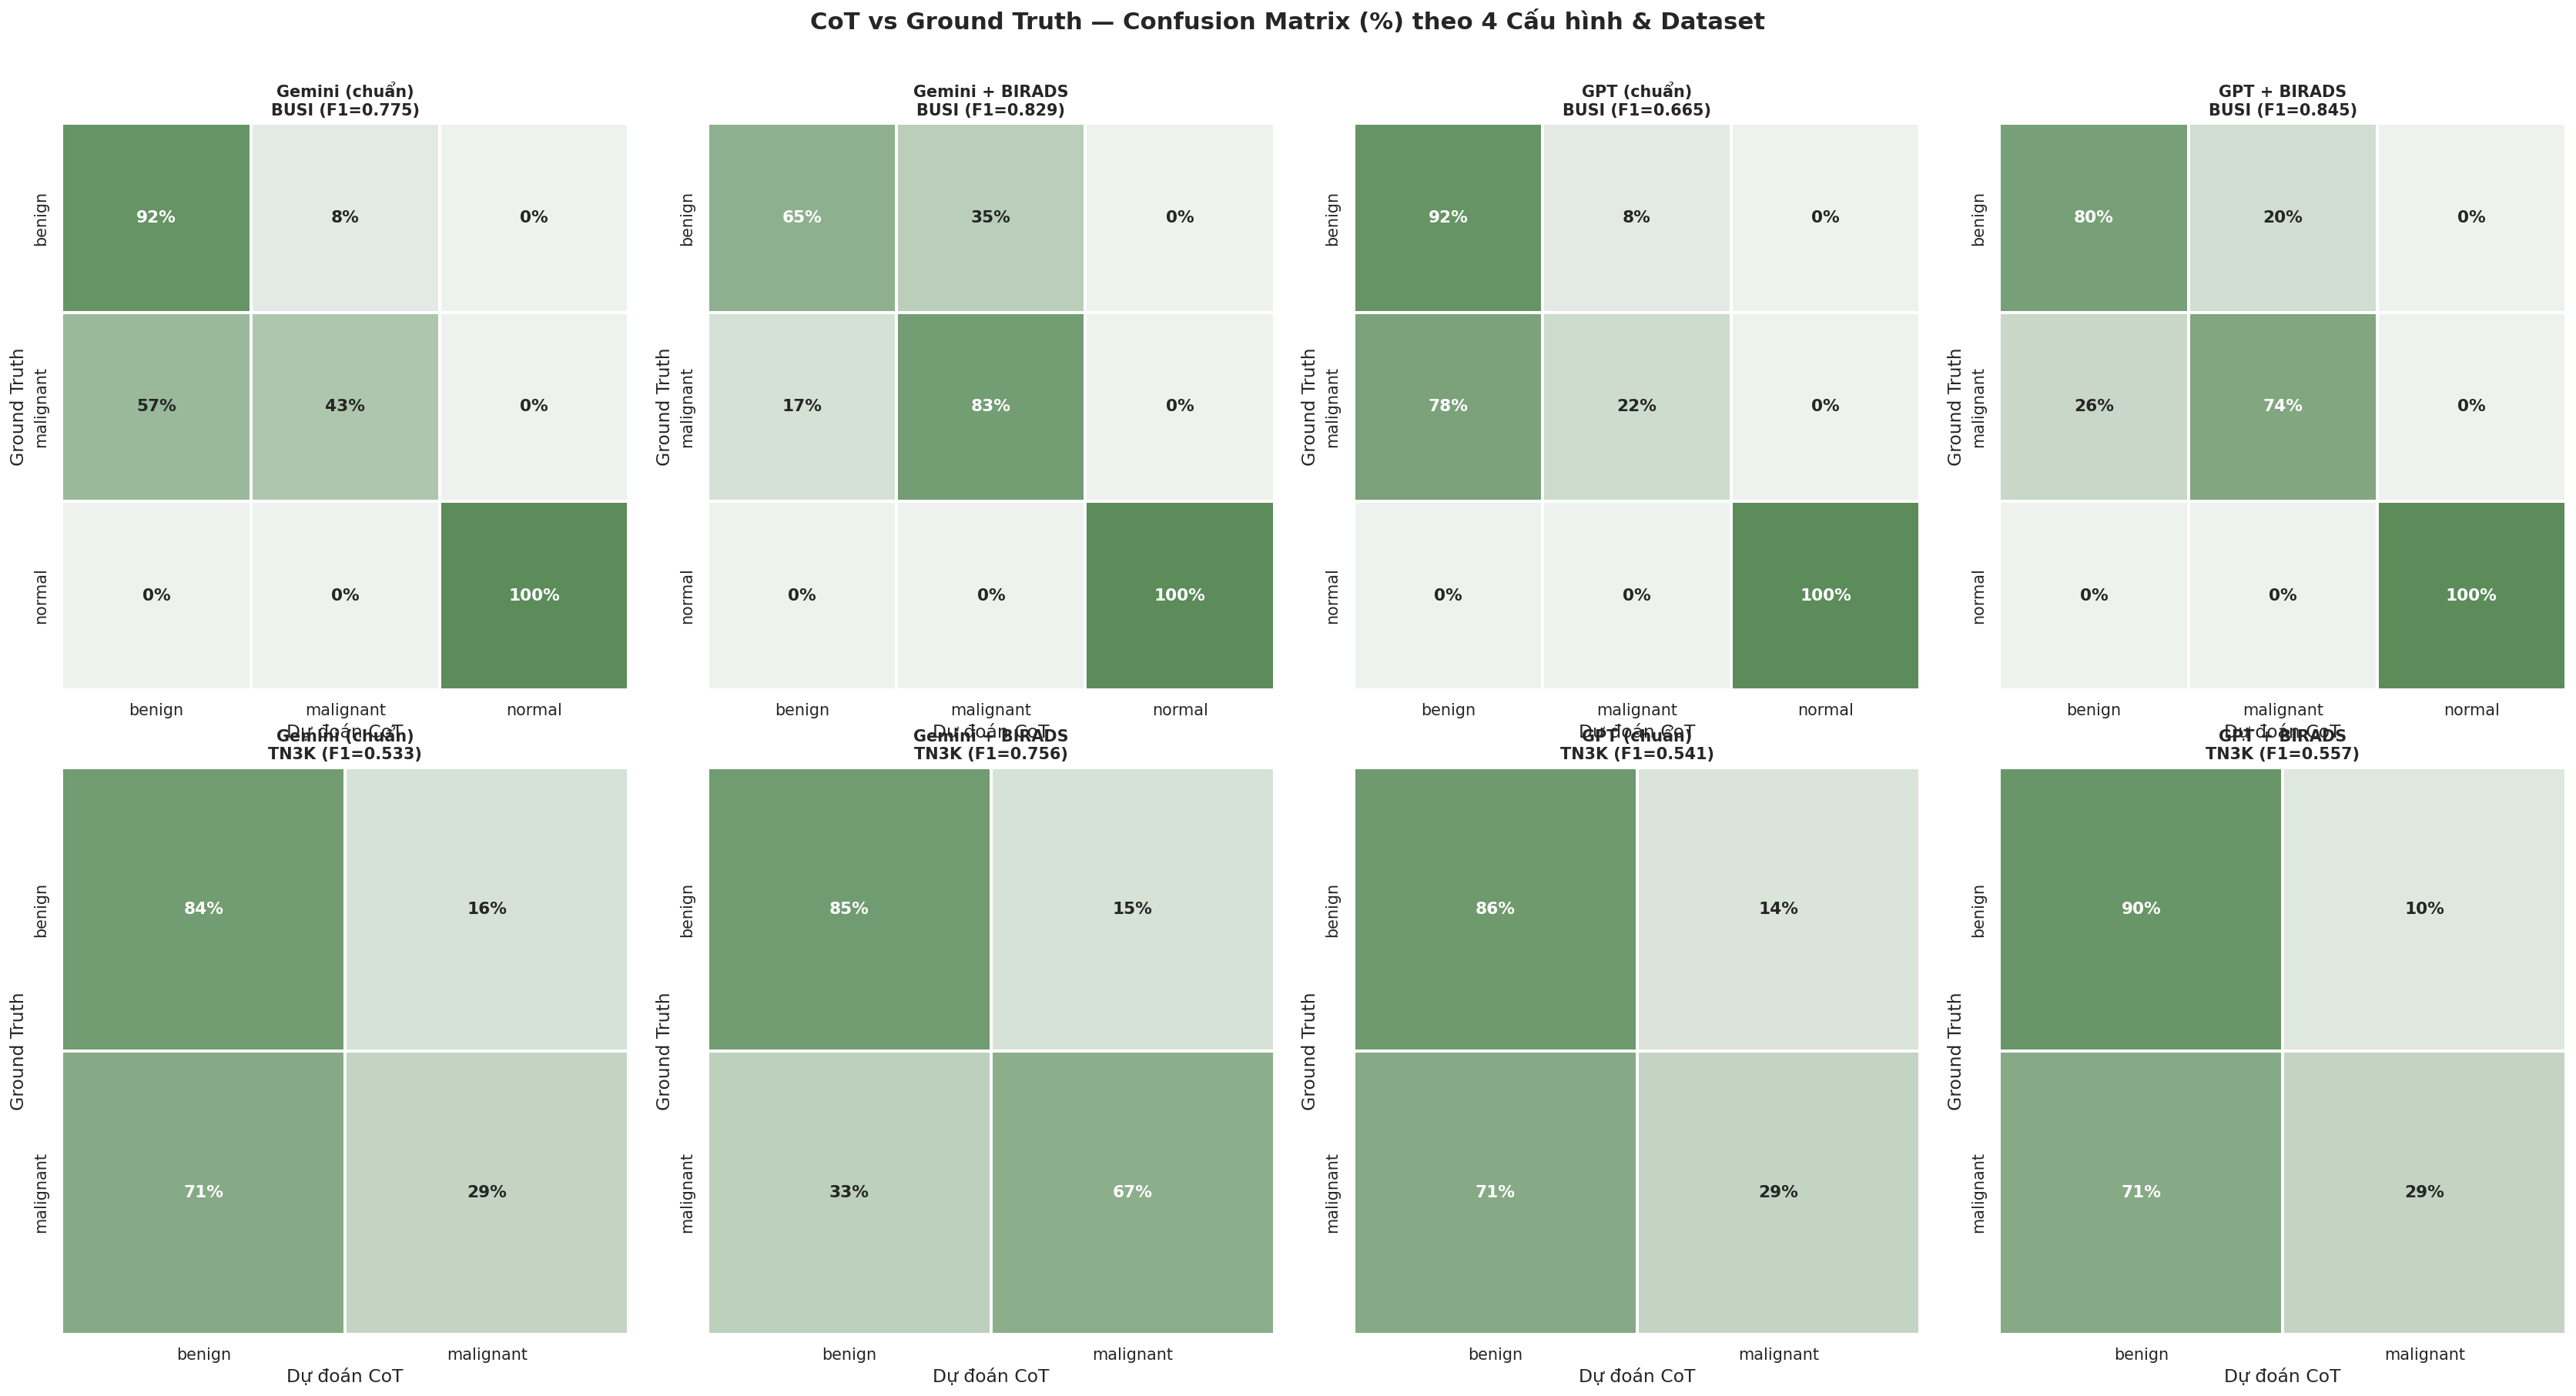

In [16]:
# --- Hình 3.4: Confusion matrices CoT vs Ground Truth cho 4 cấu hình (% theo hàng) ---
green_cmap = sns.light_palette("#5B8C5A", as_cmap=True)
fig, axes = plt.subplots(2, 4, figsize=(26.0, 13.5))

for col, (cfg_name, meta) in enumerate(cot_configs.items()):
    data = load_json(meta["path"])
    for row_i, ds_key in enumerate(["busi", "tn3k"]):
        ds = data[ds_key]
        cm_info = ds["cot_vs_ground_truth"]["confusion_matrix"]
        labels = cm_info["labels"]
        cm = np.array(cm_info["matrix"])
        cm_pct = cm / cm.sum(axis=1, keepdims=True) * 100
        ax = axes[row_i, col]
        sns.heatmap(cm_pct, annot=True, fmt=".0f", cmap=green_cmap, cbar=False,
                    xticklabels=labels, yticklabels=labels, ax=ax,
                    linewidths=2, linecolor="white", annot_kws={"size": 12, "weight": "bold"},
                    vmin=0, vmax=100, square=True)
        for t in ax.texts:
            t.set_text(t.get_text() + "%")
        ax.set_title(f"{cfg_name}\n{ds['dataset']} (F1={ds['cot_vs_ground_truth']['macro_f1']:.3f})", fontsize=11.5)
        ax.set_xlabel("Dự đoán CoT"); ax.set_ylabel("Ground Truth")

fig.suptitle("CoT vs Ground Truth — Confusion Matrix (%) theo 4 Cấu hình & Dataset", fontsize=17, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()


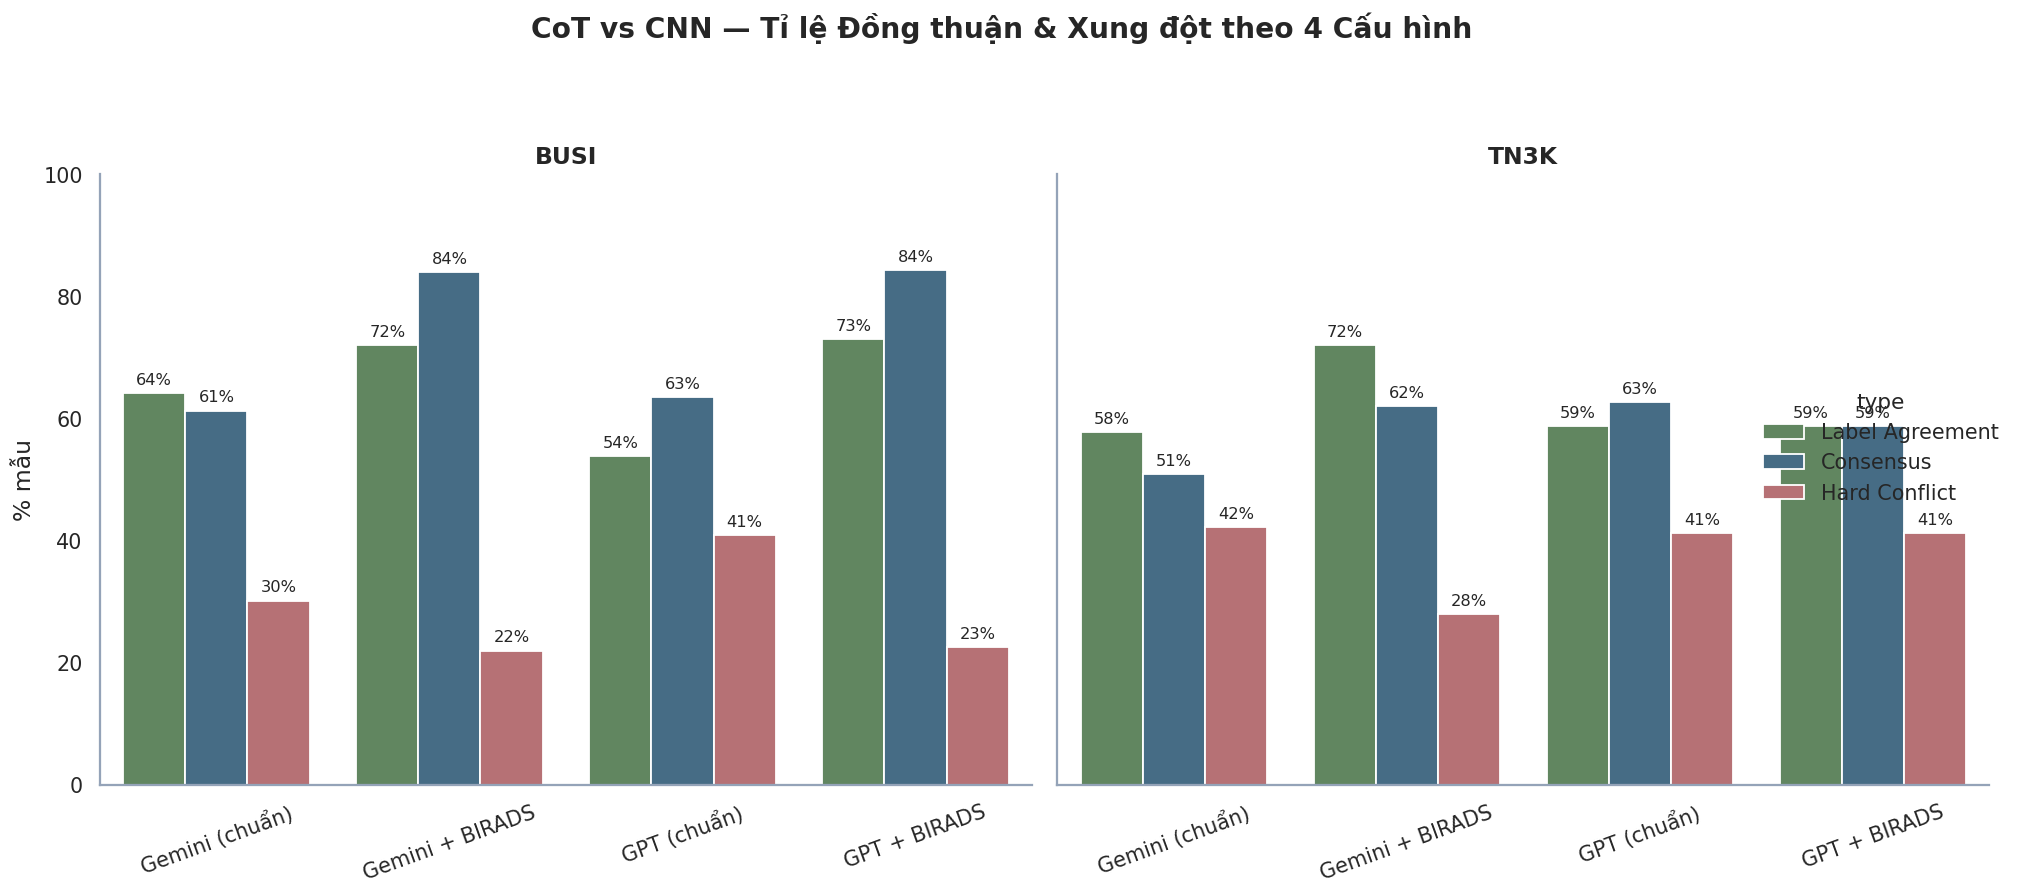

In [17]:
# --- Hình 3.5: Đồng thuận CoT vs CNN (label agreement, consensus, hard conflict) ---
agree_rows = []
for cfg_name, meta in cot_configs.items():
    data = load_json(meta["path"])
    for ds_key, ds in data.items():
        cnn = ds["cot_vs_cnn"]
        agree_rows.append({"config": cfg_name, "dataset": ds["dataset"],
                            "type": "Label Agreement", "pct": cnn["label_agreement"]["true_pct"]})
        agree_rows.append({"config": cfg_name, "dataset": ds["dataset"],
                            "type": "Consensus", "pct": cnn["consensus"]["true_pct"]})
        agree_rows.append({"config": cfg_name, "dataset": ds["dataset"],
                            "type": "Hard Conflict", "pct": cnn["hard_conflict"]["true_pct"]})
df_agree = pd.DataFrame(agree_rows)

g = sns.catplot(data=df_agree, x="config", y="pct", hue="type", col="dataset",
                 kind="bar", height=6.5, aspect=1.05, palette=[PALETTE["success"], PALETTE["primary"], PALETTE["danger"]])
g.set_axis_labels("", "% mẫu")
g.set_titles("{col_name}")
for ax in g.axes.flat:
    ax.tick_params(axis="x", rotation=20)
    ax.set_ylim(0, 100)
    annotate_bars(ax, fmt="%.0f%%", fontsize=9)
g.figure.suptitle("CoT vs CNN — Tỉ lệ Đồng thuận & Xung đột theo 4 Cấu hình", y=1.06, fontweight="bold")
plt.tight_layout()
plt.show()


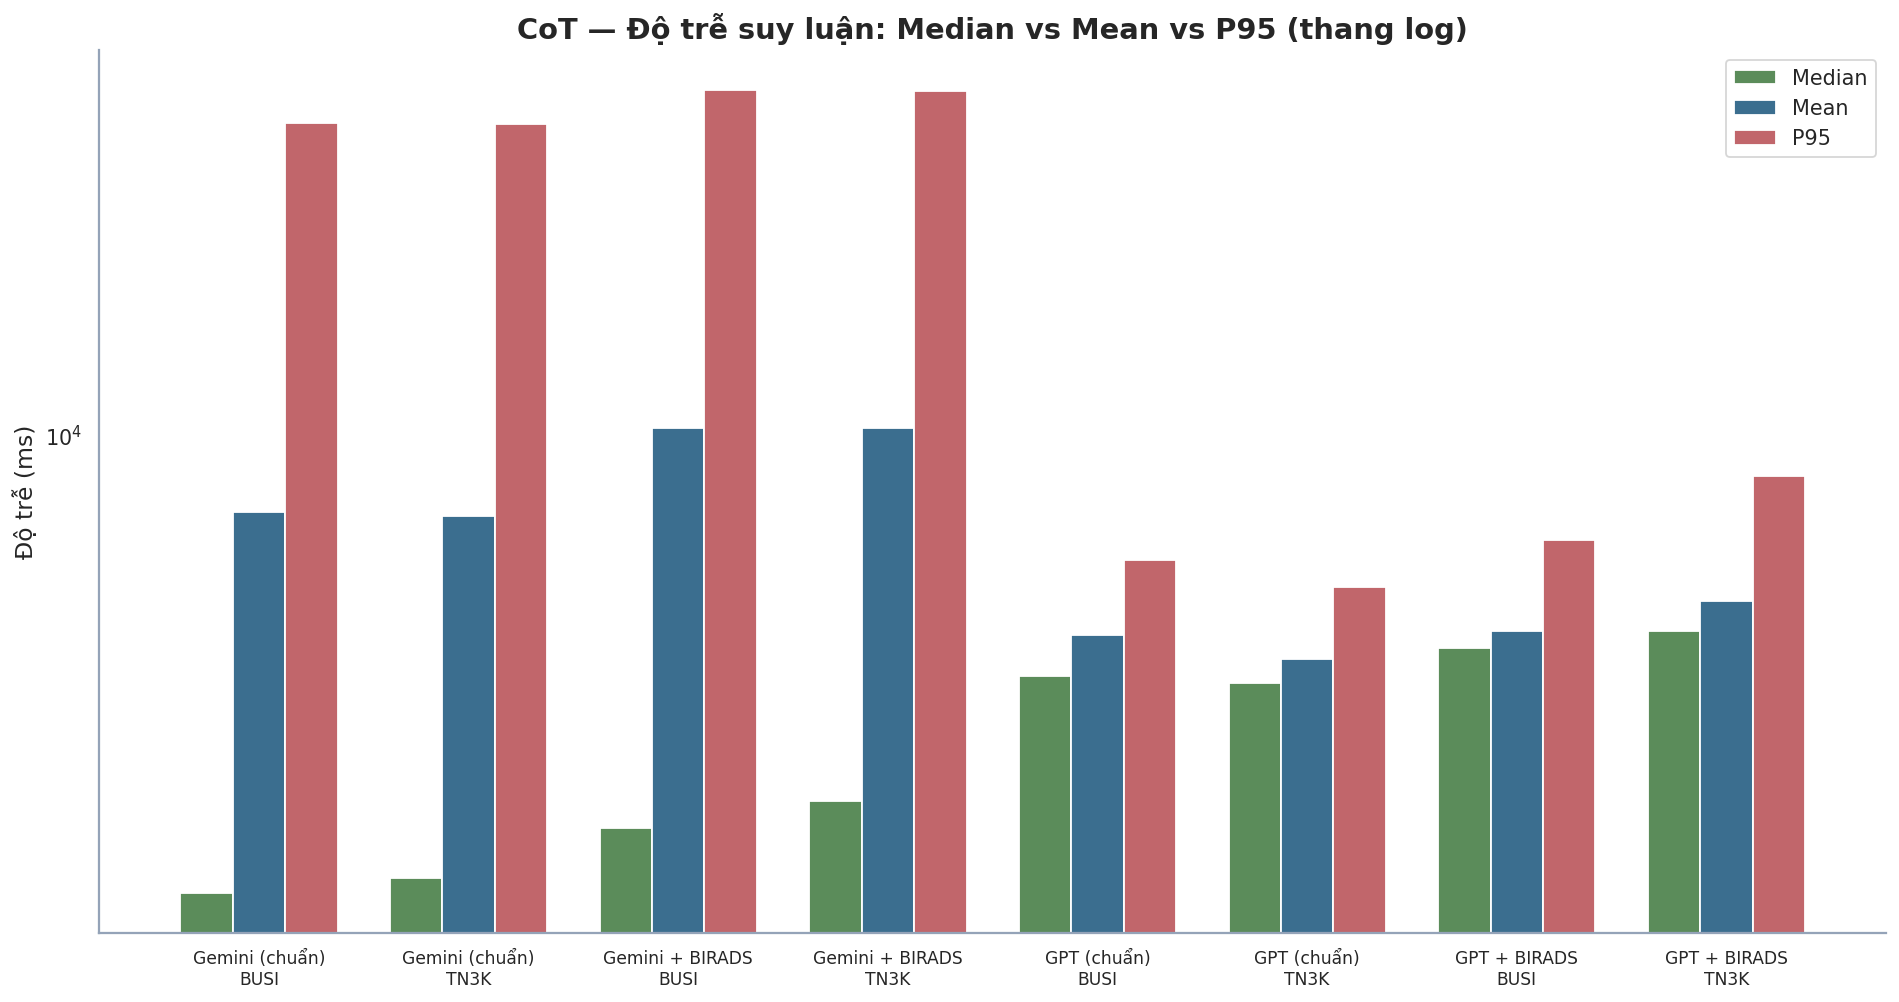

In [18]:
# --- Hình 3.6: Độ trễ CoT (mean vs median vs p95) — cho thấy đuôi dài (long-tail latency) ---
fig, ax = plt.subplots(figsize=(14.8, 7.9))
x = np.arange(len(df_cot))
width = 0.25

ax.bar(x - width, df_cot["latency_median_ms"], width, label="Median", color=PALETTE["success"])
ax.bar(x, df_cot["latency_mean_ms"], width, label="Mean", color=PALETTE["primary"])
ax.bar(x + width, df_cot["latency_p95_ms"], width, label="P95", color=PALETTE["danger"])

ax.set_xticks(x)
ax.set_xticklabels([f"{r['config']}\n{r['dataset']}" for _, r in df_cot.iterrows()], fontsize=9.5)
ax.set_ylabel("Độ trễ (ms)")
ax.set_title("CoT — Độ trễ suy luận: Median vs Mean vs P95 (thang log)")
ax.set_yscale("log")
ax.legend()
plt.tight_layout()
plt.show()


In [19]:
# --- Bảng 3.7: Tổng hợp toàn bộ chỉ số CoT (4 cấu hình) ---
summary_table = df_cot[["config", "dataset", "n_total", "macro_f1", "weighted_f1",
                          "cohen_kappa_cnn", "label_agreement_pct", "hard_conflict_pct",
                          "latency_median_ms"]].copy()
summary_table.columns = ["Cấu hình", "Dataset", "N", "Macro F1", "Weighted F1",
                          "Kappa (CNN)", "Label Agree %", "Hard Conflict %", "Latency median (ms)"]
summary_table = summary_table.round(3).sort_values(["Dataset", "Cấu hình"])
summary_table.style.background_gradient(subset=["Macro F1", "Weighted F1"], cmap="Greens")\
                    .background_gradient(subset=["Hard Conflict %"], cmap="Reds")\
                    .format({"Latency median (ms)": "{:.0f}"})


,Cấu hình,Dataset,N,Macro F1,Weighted F1,Kappa (CNN),Label Agree %,Hard Conflict %,Latency median (ms)
4,GPT (chuẩn),BUSI,115,0.665000,0.616000,0.324000,53.910000,40.870000,3556
6,GPT + BIRADS,BUSI,115,0.845000,0.826000,0.589000,73.040000,22.610000,4014
0,Gemini (chuẩn),BUSI,106,0.776000,0.758000,0.461000,64.150000,30.190000,1404
2,Gemini + BIRADS,BUSI,50,0.829000,0.798000,0.534000,72.000000,22.000000,1858
5,GPT (chuẩn),TN3K,102,0.541000,0.541000,0.203000,58.820000,41.180000,3460
7,GPT + BIRADS,TN3K,102,0.557000,0.557000,0.205000,58.820000,41.180000,4326
1,Gemini (chuẩn),TN3K,102,0.534000,0.534000,0.183000,57.840000,42.160000,1494
3,Gemini + BIRADS,TN3K,50,0.756000,0.758000,0.453000,72.000000,28.000000,2085


**Nhận xét — CoT Reasoning:** Ma trận 2×2 cho thấy rõ **prompt BIRADS là yếu tố cải thiện chính** — nhất quán trên
cả 2 model và cả 2 dataset. Việc chọn Gemini hay GPT ảnh hưởng ít hơn nhiều và không có model nào vượt trội tuyệt
đối. Tỷ lệ **hard conflict** cũng giảm đáng kể khi dùng BIRADS. Độ trễ có đuôi dài rất lớn (P95 gấp 20-30 lần
median) — cần lưu ý khi thiết kế timeout/SLA cho production.


## 4. RAG Retrieval — Tiến trình Cải thiện qua 3 Giai đoạn

Retrieval được đánh giá qua **3 giai đoạn cải tiến kỹ thuật liên tiếp**:

1. **Trước xử lý** (`before_preprocess`) — baseline ban đầu
2. **Sau tiền xử lý tài liệu** (`after_preprocess`) — cải thiện chunking/cleaning văn bản nguồn
3. **Sau fine-tune embedding + rerank** (`after_finetune_embed_rerank`) — fine-tune model embedding và thêm bước rerank

Mỗi giai đoạn được đo bằng **2 cách query khác nhau, không gộp chung** vì bản chất khác nhau:

- **`natural_question`** — câu hỏi tự nhiên từ testset, dùng trực tiếp để truy vấn. Đây là chỉ số chính, phản
  ánh đúng năng lực retrieval của hệ thống.
- **`production_query`** — được build lại từ metadata thô có sẵn trong testset (`{organ} {modality} ...`), dùng
  để mô phỏng cách hệ thống ghép query trong production. **Tuy nhiên cách build này chưa phản ánh đúng luồng thực
  tế**: trong production, câu query được làm giàu từ suy luận ngữ cảnh của CNN (nhãn, vị trí tổn thương, hình dạng...)
  trước khi đưa vào RAG, và chỉ fallback về dạng `{organ} {modality}` đơn giản khi CNN thất bại. Vì testset không có
  đủ metadata suy luận phong phú như luồng thật, phép so sánh này **hiện chưa công bằng** — nên được xem là tín hiệu
  tham khảo riêng, tách khỏi biểu đồ so sánh chính.


In [20]:
rag_stages = {
    "Trước xử lý": RESULTS_DIR / "rag_ragas_before_preprocess" / "rag_retrieval.json",
    "Sau tiền xử lý": RESULTS_DIR / "rag_ragas_after_preprocess" / "rag_retrieval.json",
    "Sau fine-tune embed + rerank": RESULTS_DIR / "rag_ragas_after_finetune_embed_rerank" / "rag_retrieval.json",
}

rows = []
for stage_name, path in rag_stages.items():
    data = load_json(path)
    for qtype in ["production_query", "natural_question"]:
        d = data[qtype]
        rows.append({
            "stage": stage_name,
            "query_type": "Production Query" if qtype == "production_query" else "Natural Question",
            "recall_at_100": d["stage1"]["recall_at_100"],
            "hit_rate": d["stage1"]["hit_rate"],
            "ndcg_at_3": d["stage2"]["ndcg_at_3"],
            "precision_at_3": d["stage2"]["precision_at_3"],
            "mrr": d["stage2"]["mrr"],
        })
df_rag = pd.DataFrame(rows)
df_rag


,stage,query_type,recall_at_100,hit_rate,ndcg_at_3,precision_at_3,mrr
0,Trước xử lý,Production Query,0.039216,0.039216,0.000000,0.000000,0.000000
1,Trước xử lý,Natural Question,0.235294,0.235294,0.181256,0.084967,0.176471
2,Sau tiền xử lý,Production Query,0.159091,0.159091,0.045455,0.030303,0.045455
3,Sau tiền xử lý,Natural Question,0.954545,0.954545,0.748310,0.439394,0.727273
4,Sau fine-tune embed + rerank,Production Query,0.136364,0.136364,0.045455,0.030303,0.045455
5,Sau fine-tune embed + rerank,Natural Question,0.954545,0.954545,0.810749,0.500000,0.799242


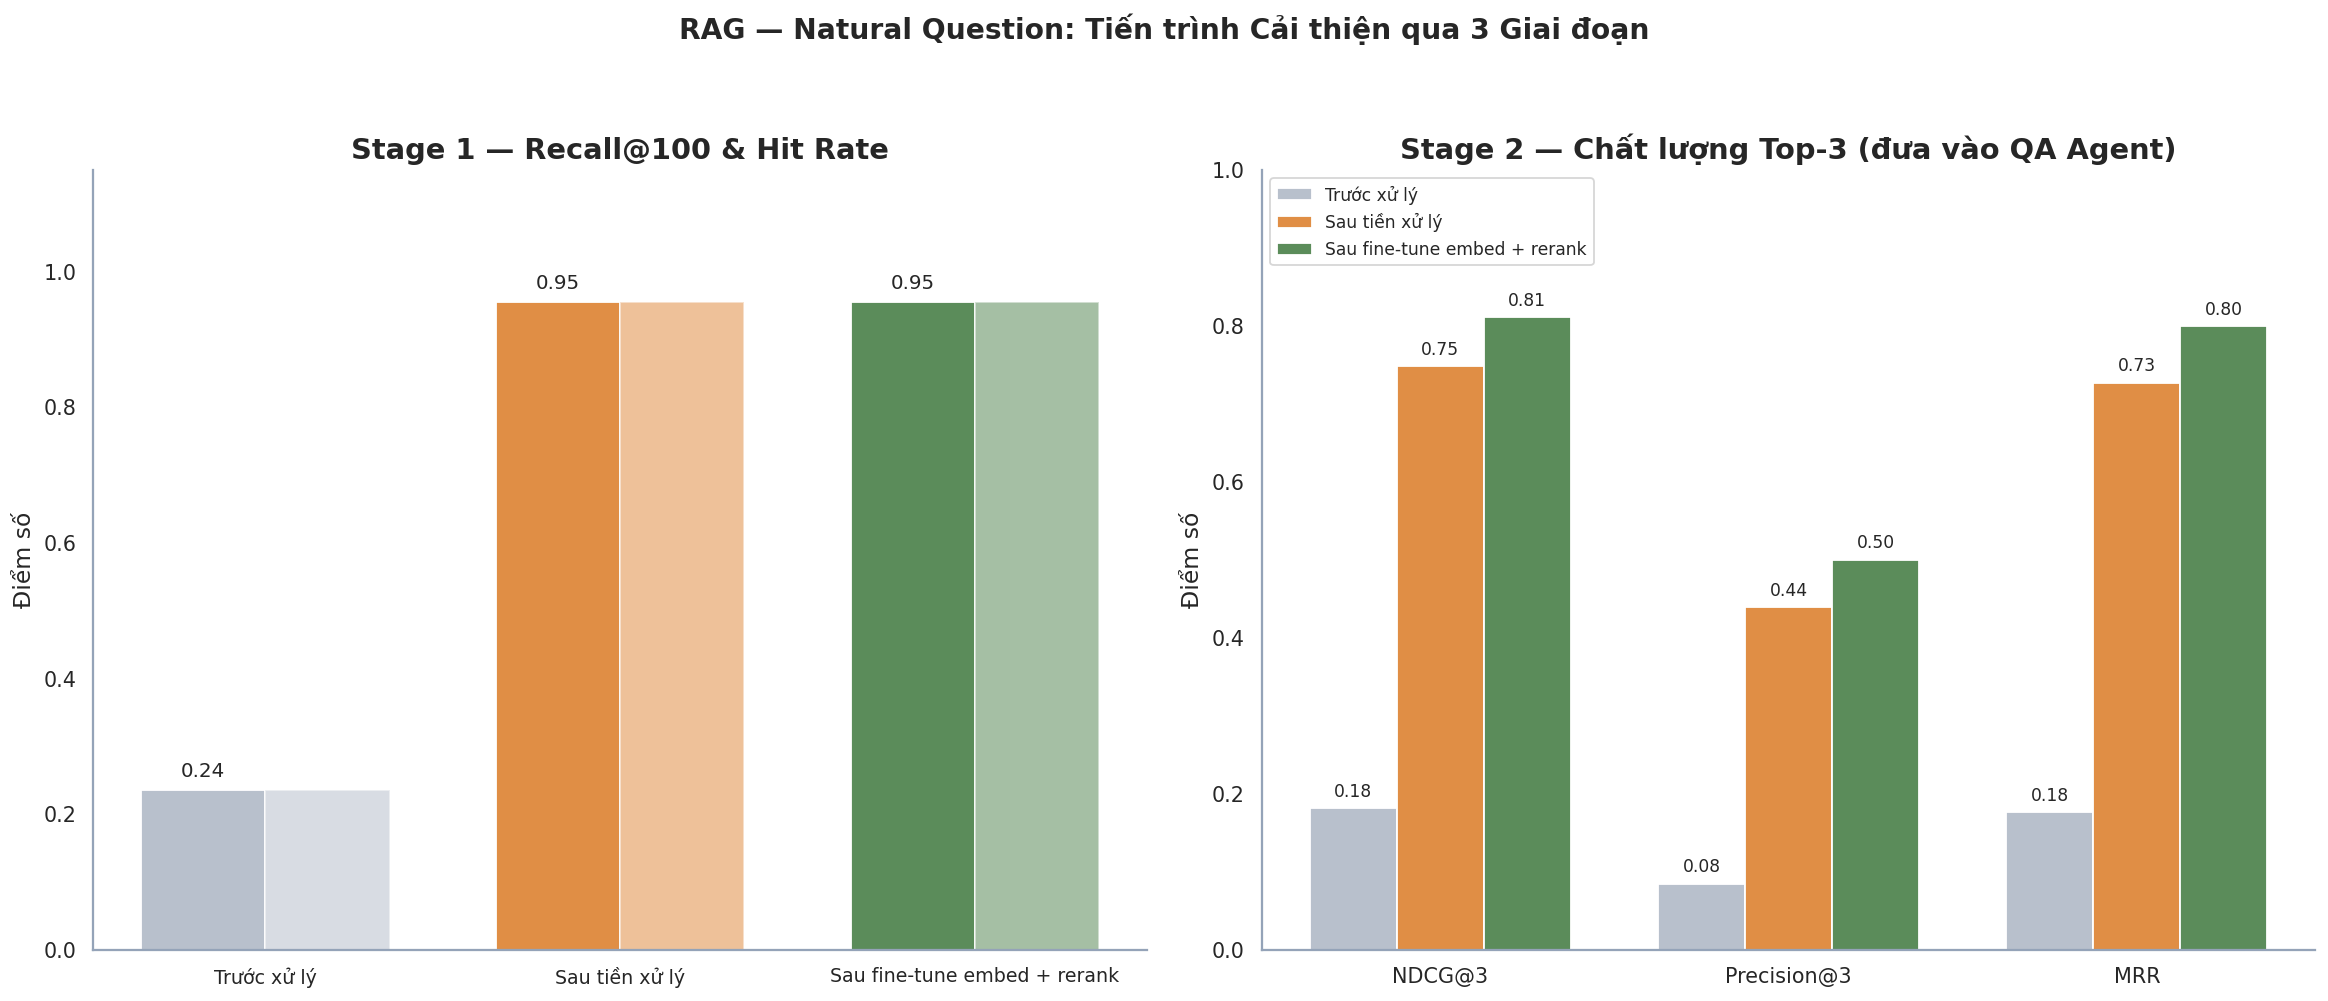

In [21]:
# --- Hình 4.1: NATURAL QUESTION — Tiến trình cải thiện qua 3 giai đoạn (chỉ số chính) ---
stage_order = list(rag_stages.keys())
df_nq = df_rag[df_rag["query_type"] == "Natural Question"].set_index("stage").loc[stage_order]

fig, axes = plt.subplots(1, 2, figsize=(18.1, 7.4))

# Stage 1: Recall@100 / Hit Rate
ax = axes[0]
x = np.arange(len(stage_order))
width = 0.35
ax.bar(x - width/2, df_nq["recall_at_100"], width, label="Recall@100", color=BEFORE_AFTER_PALETTE)
ax.bar(x + width/2, df_nq["hit_rate"], width, label="Hit Rate", color=BEFORE_AFTER_PALETTE, alpha=0.55)
for i, v in enumerate(df_nq["recall_at_100"]):
    ax.text(i - width/2, v + 0.02, f"{v:.2f}", ha="center", fontsize=11)
ax.set_xticks(x); ax.set_xticklabels(stage_order, fontsize=10.5)
ax.set_ylim(0, 1.15)
ax.set_title("Stage 1 — Recall@100 & Hit Rate")
ax.set_ylabel("Điểm số")

# Stage 2: NDCG@3 / Precision@3 / MRR
ax = axes[1]
metrics_s2 = ["ndcg_at_3", "precision_at_3", "mrr"]
metric_labels_s2 = ["NDCG@3", "Precision@3", "MRR"]
xx = np.arange(len(metrics_s2))
width2 = 0.25
for i, stage in enumerate(stage_order):
    vals = [df_nq.loc[stage, m] for m in metrics_s2]
    bars = ax.bar(xx + (i - 1) * width2, vals, width2, label=stage, color=BEFORE_AFTER_PALETTE[i])
    for xi, v in zip(xx + (i - 1) * width2, vals):
        ax.text(xi, v + 0.015, f"{v:.2f}", ha="center", fontsize=9.5, rotation=0)
ax.set_xticks(xx); ax.set_xticklabels(metric_labels_s2)
ax.set_ylim(0, 1.0)
ax.set_title("Stage 2 — Chất lượng Top-3 (đưa vào QA Agent)")
ax.set_ylabel("Điểm số")
ax.legend(fontsize=9.5, loc="upper left")

fig.suptitle("RAG — Natural Question: Tiến trình Cải thiện qua 3 Giai đoạn", y=1.04, fontweight="bold")
plt.tight_layout()
plt.show()


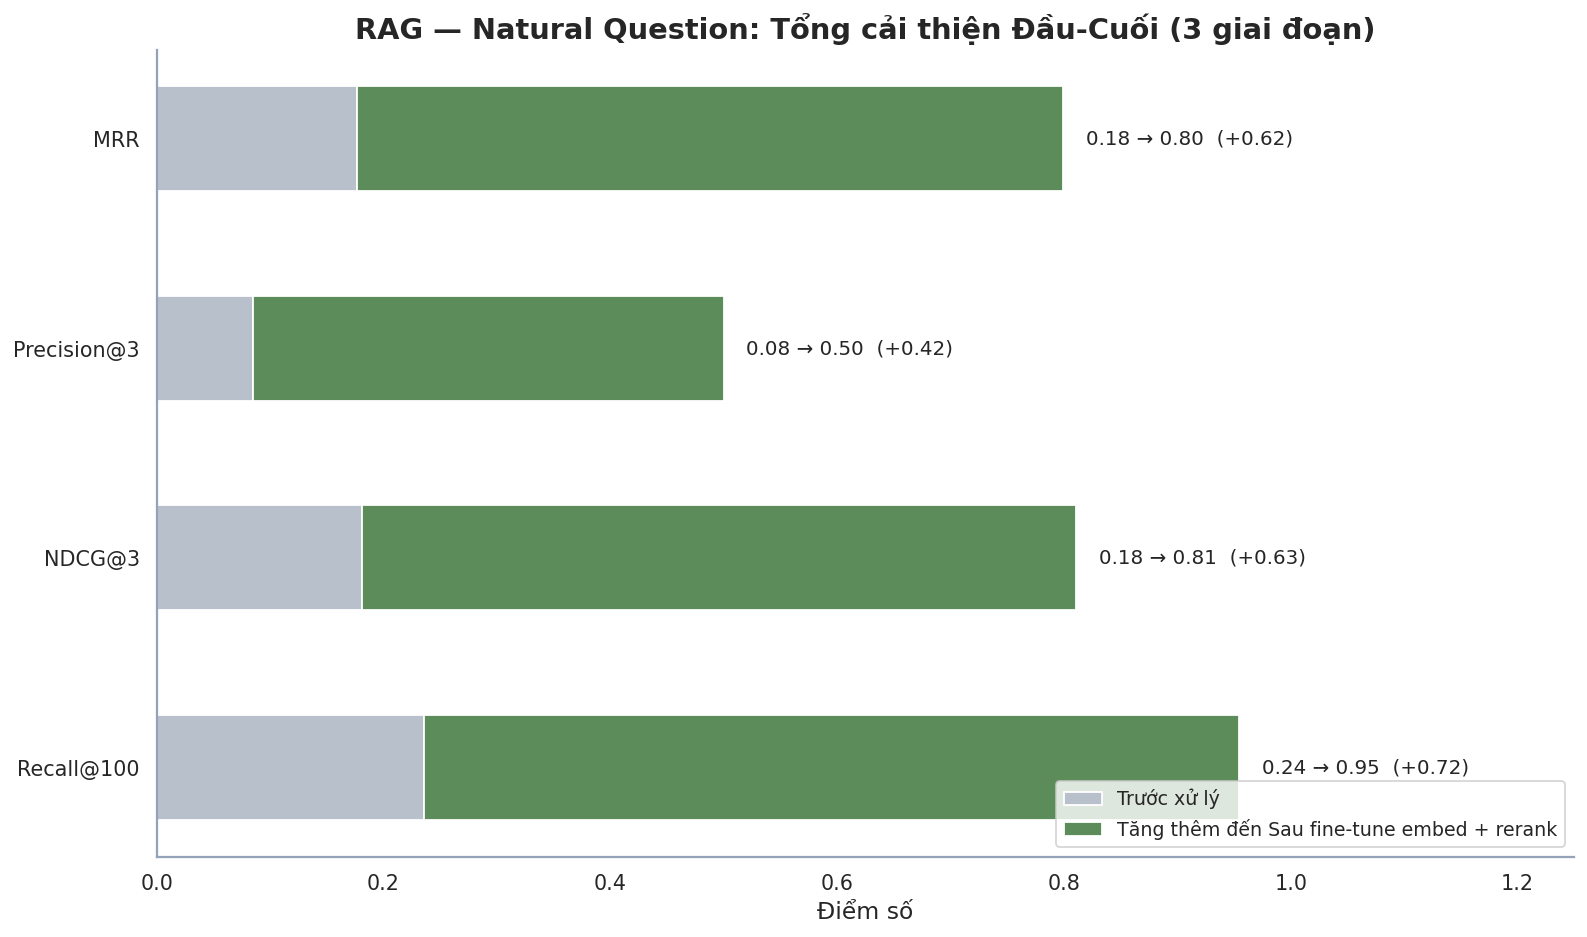

In [22]:
# --- Hình 4.2: Tổng hợp % cải thiện từ giai đoạn đầu đến cuối (Natural Question) ---
first_stage, last_stage = stage_order[0], stage_order[-1]
metrics_all = ["recall_at_100", "ndcg_at_3", "precision_at_3", "mrr"]
metric_labels_all = ["Recall@100", "NDCG@3", "Precision@3", "MRR"]

improvement = pd.DataFrame({
    "metric": metric_labels_all,
    "before": [df_nq.loc[first_stage, m] for m in metrics_all],
    "after": [df_nq.loc[last_stage, m] for m in metrics_all],
})
improvement["delta"] = improvement["after"] - improvement["before"]
improvement["pct_gain"] = np.where(improvement["before"] > 0,
                                     improvement["delta"] / improvement["before"] * 100,
                                     np.inf)

fig, ax = plt.subplots(figsize=(12.4, 7.4))
y = np.arange(len(improvement))
ax.barh(y, improvement["before"], height=0.5, color=BEFORE_AFTER_PALETTE[0], label=first_stage)
ax.barh(y, improvement["delta"], height=0.5, left=improvement["before"], color=BEFORE_AFTER_PALETTE[2],
        label=f"Tăng thêm đến {last_stage}")
for i, row in improvement.iterrows():
    ax.text(row["after"] + 0.02, i, f"{row['before']:.2f} → {row['after']:.2f}  ({row['delta']:+.2f})",
            va="center", fontsize=11)
ax.set_yticks(y); ax.set_yticklabels(improvement["metric"])
ax.set_xlim(0, 1.25)
ax.set_xlabel("Điểm số")
ax.set_title("RAG — Natural Question: Tổng cải thiện Đầu-Cuối (3 giai đoạn)")
ax.legend(loc="lower right", fontsize=10.5)
plt.tight_layout()
plt.show()


**Contribution nổi bật — Natural Question:** Retrieval cải thiện rất mạnh qua 3 giai đoạn — Recall@100 từ **23.5%
→ 95.5%**, NDCG@3 từ **0.18 → 0.81**. Phần lớn mức tăng đến từ bước **tiền xử lý tài liệu** (giai đoạn 1→2), cho
thấy chất lượng chunking/cleaning văn bản nguồn có ảnh hưởng lớn hơn cả việc fine-tune embedding. Bước **fine-tune
embedding + rerank** (giai đoạn 2→3) tiếp tục cải thiện NDCG@3 và MRR đáng kể dù Recall@100 gần bão hòa.


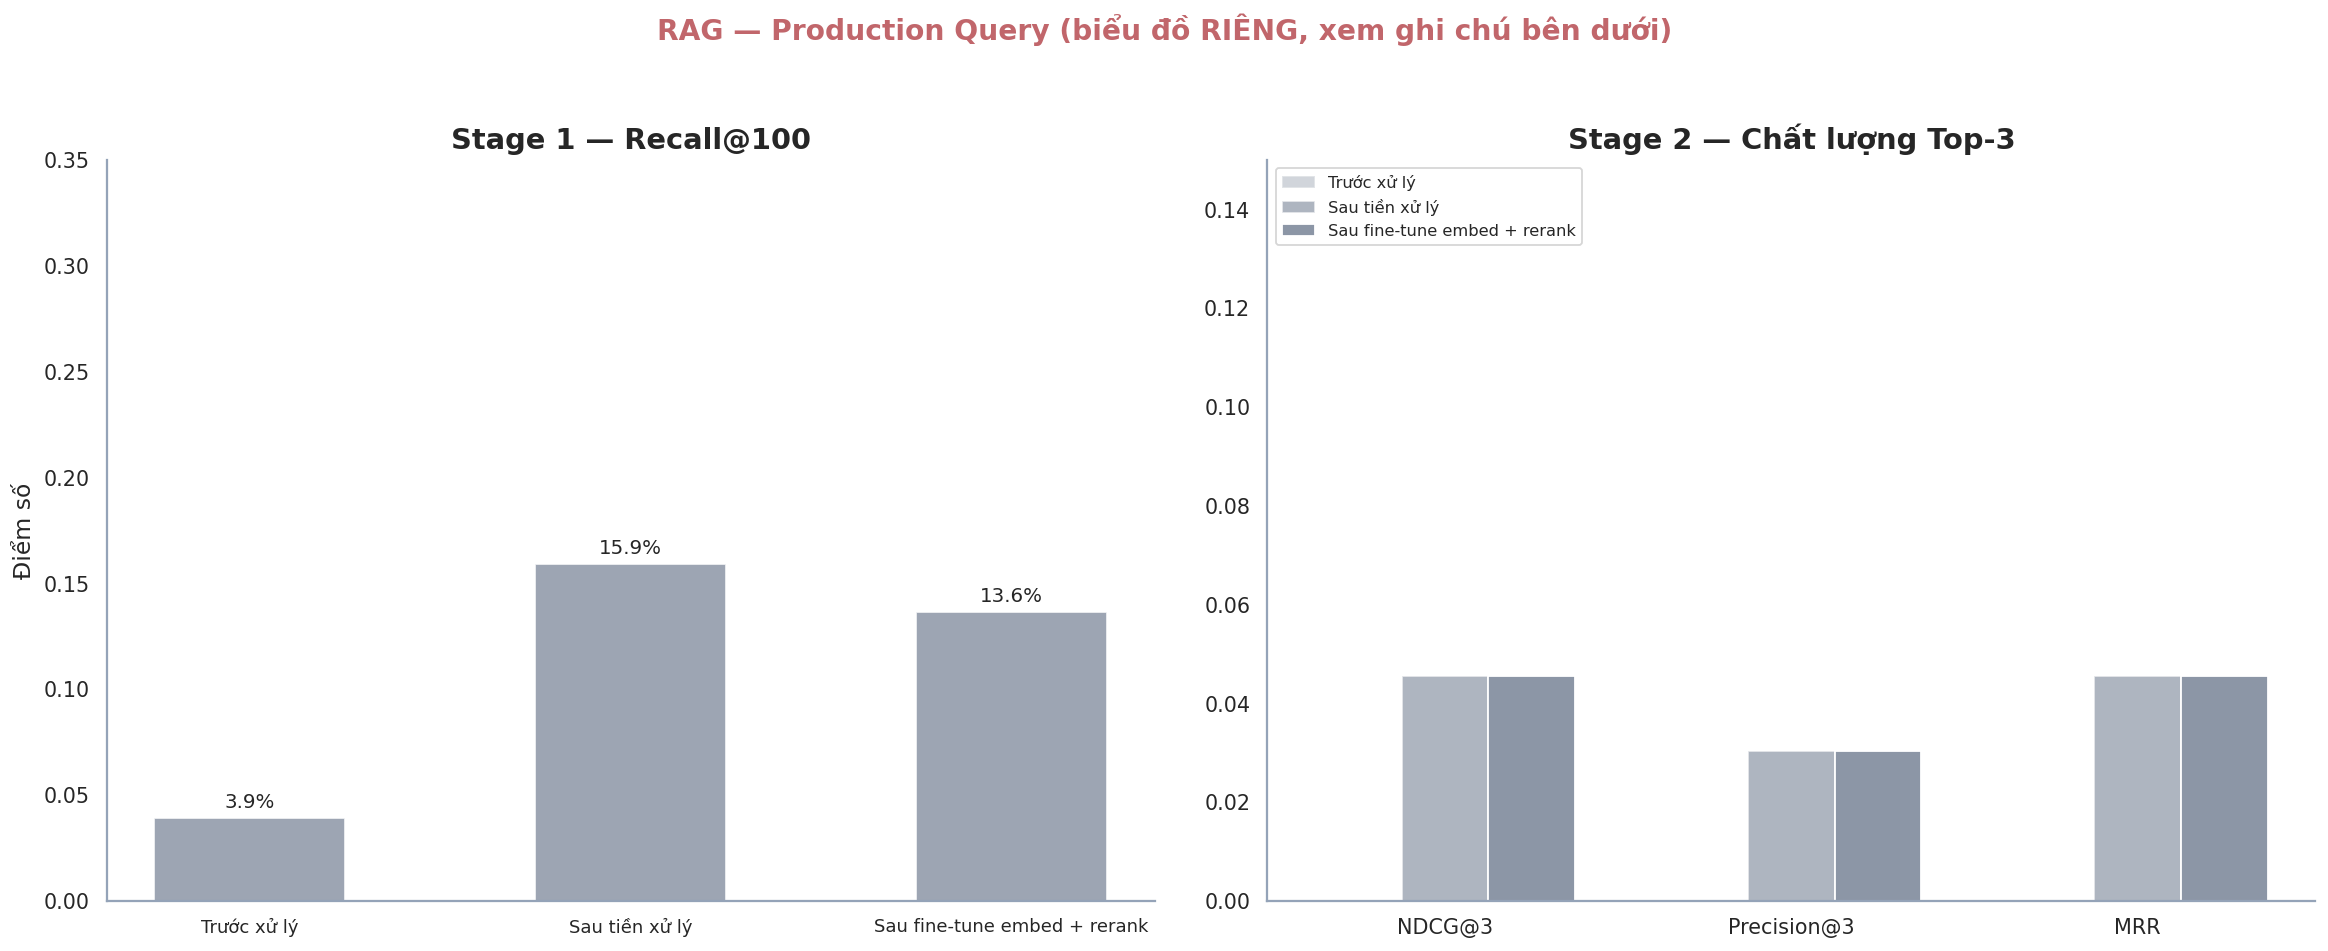

In [23]:
# --- Hình 4.3: PRODUCTION QUERY — biểu đồ riêng, không so sánh trực tiếp với Natural Question ---
df_pq = df_rag[df_rag["query_type"] == "Production Query"].set_index("stage").loc[stage_order]

fig, axes = plt.subplots(1, 2, figsize=(18.1, 7.1))

ax = axes[0]
ax.bar(stage_order, df_pq["recall_at_100"], color=PALETTE["neutral"], alpha=0.85, width=0.5)
for i, v in enumerate(df_pq["recall_at_100"]):
    ax.text(i, v + 0.005, f"{v:.1%}", ha="center", fontsize=11)
ax.set_ylim(0, 0.35)
ax.set_title("Stage 1 — Recall@100")
ax.set_ylabel("Điểm số")
ax.tick_params(axis="x", labelsize=10)

ax = axes[1]
metrics_s2 = ["ndcg_at_3", "precision_at_3", "mrr"]
metric_labels_s2 = ["NDCG@3", "Precision@3", "MRR"]
xx = np.arange(len(metrics_s2))
width2 = 0.25
for i, stage in enumerate(stage_order):
    vals = [df_pq.loc[stage, m] for m in metrics_s2]
    ax.bar(xx + (i - 1) * width2, vals, width2, label=stage, color=PALETTE["neutral"], alpha=0.4 + 0.3*i)
ax.set_xticks(xx); ax.set_xticklabels(metric_labels_s2)
ax.set_ylim(0, 0.15)
ax.set_title("Stage 2 — Chất lượng Top-3")
ax.legend(fontsize=9, loc="upper left")

fig.suptitle("RAG — Production Query (biểu đồ RIÊNG, xem ghi chú bên dưới)", y=1.03, fontweight="bold", color=PALETTE["danger"])
plt.tight_layout()
plt.show()


> ⚠️ **Ghi chú quan trọng về `production_query`:** Chỉ số này ở mức rất thấp và gần như không đổi qua 3 giai đoạn
> (Recall@100 dao động 4-16%, NDCG@3/Precision@3/MRR ~0-0.05). Như giải thích ở trên, đây **không hẳn là dấu hiệu
> hệ thống production kém** — nhiều khả năng là do phép mô phỏng trong đánh giá chưa tái tạo đúng độ phong phú của
> query thật (vốn được làm giàu từ ngữ cảnh CNN, không chỉ `{organ} {modality}` thô). Vì lý do này, **nên cân nhắc
> loại bỏ chỉ số `production_query` khỏi các báo cáo so sánh chính**, hoặc xây dựng lại kịch bản test mô phỏng đúng
> hơn luồng dữ liệu thực tế (bao gồm cả nhánh fallback khi CNN thất bại) trước khi dùng để đánh giá.


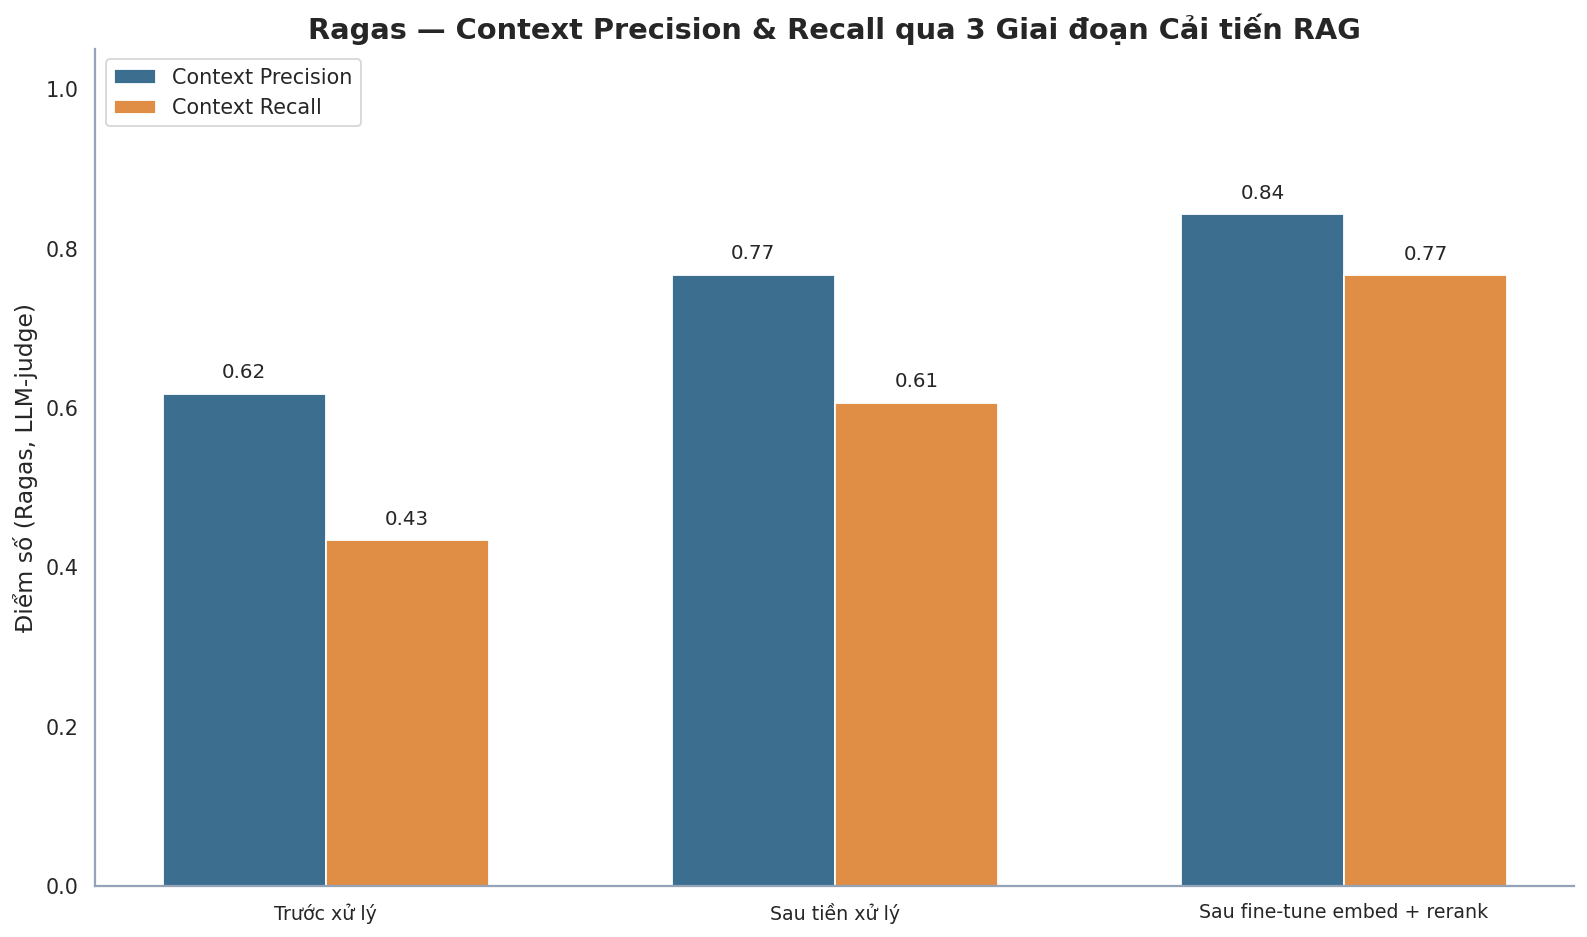

In [24]:
# --- Hình 4.4: Ragas Retrieval — Context Precision & Context Recall qua 3 giai đoạn ---
ragas_retrieval_stages = {
    "Trước xử lý": RESULTS_DIR / "rag_ragas_before_preprocess" / "ragas_retrieval.csv",
    "Sau tiền xử lý": RESULTS_DIR / "rag_ragas_after_preprocess" / "ragas_retrieval.csv",
    "Sau fine-tune embed + rerank": RESULTS_DIR / "rag_ragas_after_finetune_embed_rerank" / "ragas_retrieval.csv",
}

rows = []
for stage_name, path in ragas_retrieval_stages.items():
    df_s = pd.read_csv(path)
    rows.append({
        "stage": stage_name,
        "context_precision_mean": df_s["llm_context_precision_with_reference"].mean(),
        "context_recall_mean": df_s["context_recall"].mean(),
        "n": len(df_s),
    })
df_ragas_ret_summary = pd.DataFrame(rows)

fig, ax = plt.subplots(figsize=(12.4, 7.4))
x = np.arange(len(stage_order))
width = 0.32
ax.bar(x - width/2, df_ragas_ret_summary["context_precision_mean"], width,
       label="Context Precision", color=PALETTE["primary"])
ax.bar(x + width/2, df_ragas_ret_summary["context_recall_mean"], width,
       label="Context Recall", color=PALETTE["secondary"])
for i in range(len(stage_order)):
    ax.text(i - width/2, df_ragas_ret_summary["context_precision_mean"][i] + 0.02,
            f"{df_ragas_ret_summary['context_precision_mean'][i]:.2f}", ha="center", fontsize=11)
    ax.text(i + width/2, df_ragas_ret_summary["context_recall_mean"][i] + 0.02,
            f"{df_ragas_ret_summary['context_recall_mean'][i]:.2f}", ha="center", fontsize=11)
ax.set_xticks(x); ax.set_xticklabels(stage_order, fontsize=10.5)
ax.set_ylim(0, 1.05)
ax.set_ylabel("Điểm số (Ragas, LLM-judge)")
ax.set_title("Ragas — Context Precision & Recall qua 3 Giai đoạn Cải tiến RAG")
ax.legend(loc="upper left")
plt.tight_layout()
plt.show()


**Xác nhận độc lập từ Ragas (LLM-judge):** Context Precision tăng từ **0.62 → 0.84** và Context Recall tăng từ
**0.43 → 0.77** qua 3 giai đoạn — cùng xu hướng cải thiện nhất quán với chỉ số NDCG/Recall@100 đo bằng phương pháp
token-overlap ở trên, củng cố thêm độ tin cậy cho kết luận rằng các cải tiến RAG (tiền xử lý + fine-tune + rerank)
thực sự hiệu quả.


## 5. Ragas Pipeline — Faithfulness & Answer Relevancy: Vì sao điểm ban đầu rất thấp

Đây là câu hỏi mà bạn đặt ra — và câu trả lời **không nằm ở chất lượng câu trả lời của LLM, mà ở một lỗi trong
cách xây dựng dữ liệu đánh giá** (đã được xác nhận qua code trong `eval_ragas.py`):

> Ragas tính `answer_relevancy` bằng cách cho LLM **tự sinh ngược lại câu hỏi** từ câu trả lời (`response`), rồi đo
> **cosine similarity** giữa câu hỏi tự sinh đó với `user_input` gốc. Ở bản chạy **"Trước xử lý"**, `user_input`
> bị hard-code **giống hệt nhau cho toàn bộ record** (`"Phân tích đặc điểm siêu âm và đưa ra nhận định lâm sàng."`)
> thay vì phản ánh đúng câu truy vấn thực tế đã dùng để lấy `retrieved_contexts` cho từng ca. Vì `user_input` không
> liên quan gì đến nội dung `response`, điểm relevancy gần như luôn thấp — **bất kể câu trả lời của LLM có tốt hay
> không**. `Faithfulness` (đo mức bám sát `retrieved_contexts`) cũng bị ảnh hưởng gián tiếp vì tập context/response
> đi kèm dữ liệu lỗi này chưa được rà soát kỹ ở bản đầu.
>
> Lỗi này đã được phát hiện và sửa (tái tạo đúng `enriched_query` mà pipeline thực sự dùng ở từng ca, thay vì
> câu cố định) — thể hiện rõ trong 2 giai đoạn sau (`after_preprocess`, `after_finetune_embed_rerank`).


In [25]:
ragas_pipeline_stages = {
    "Trước xử lý\n(bug: user_input cố định)": RESULTS_DIR / "rag_ragas_before_preprocess" / "ragas_pipeline.csv",
    "Sau tiền xử lý\n(đã vá lỗi)": RESULTS_DIR / "rag_ragas_after_preprocess" / "ragas_pipeline.csv",
    "Sau fine-tune embed + rerank": RESULTS_DIR / "rag_ragas_after_finetune_embed_rerank" / "ragas_pipeline.csv",
}

rows = []
for stage_name, path in ragas_pipeline_stages.items():
    df_s = pd.read_csv(path)
    rows.append({
        "stage": stage_name,
        "n": len(df_s),
        "n_unique_user_input": df_s["user_input"].nunique(),
        "faithfulness_mean": df_s["faithfulness"].mean(),
        "faithfulness_median": df_s["faithfulness"].median(),
        "answer_relevancy_mean": df_s["answer_relevancy"].mean(),
        "answer_relevancy_median": df_s["answer_relevancy"].median(),
    })
df_ragas_pipe_summary = pd.DataFrame(rows)
df_ragas_pipe_summary


,stage,n,n_unique_user_input,faithfulness_mean,faithfulness_median,answer_relevancy_mean,answer_relevancy_median
0,Trước xử lý\n(bug: user_input cố định),45,1,0.034414,0.000000,0.057545,0.069742
1,Sau tiền xử lý\n(đã vá lỗi),41,34,0.099143,0.083333,0.289594,0.494756
2,Sau fine-tune embed + rerank,41,34,0.110804,0.111111,0.277684,0.000000


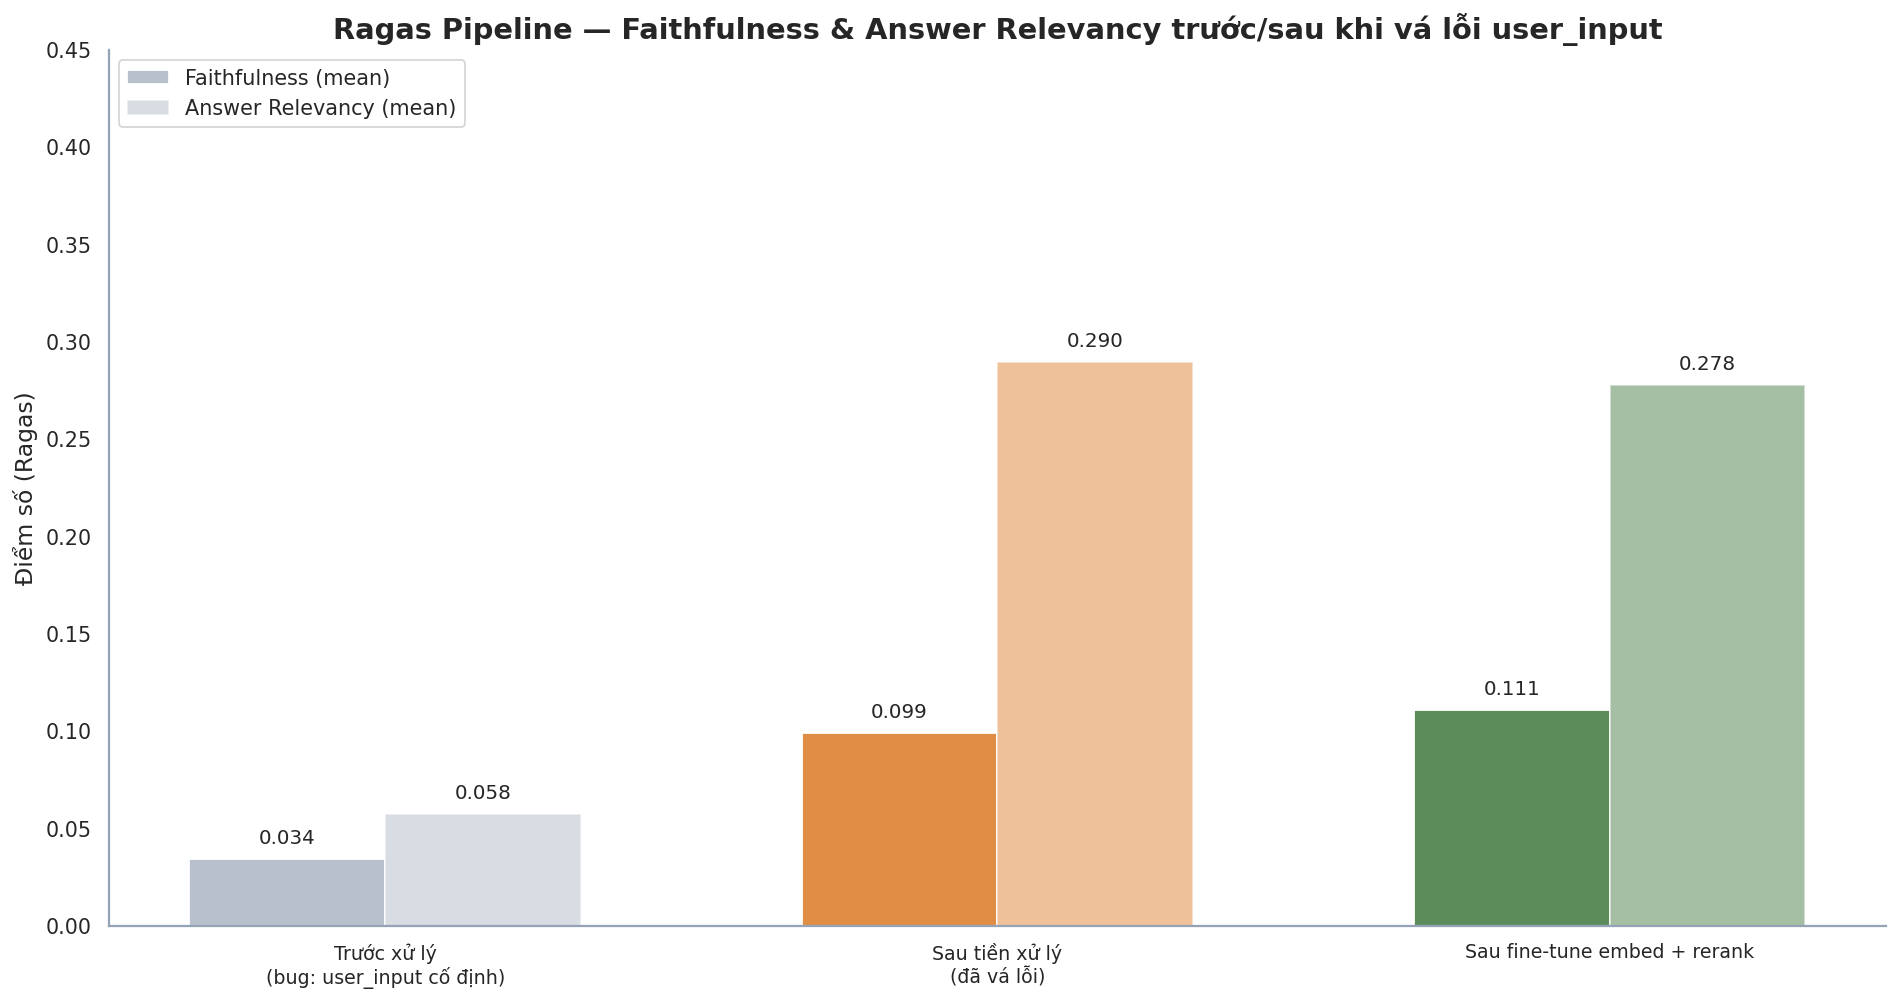

Số user_input DUY NHẤT trên tổng số record — minh chứng trực tiếp cho lỗi:
  Trước xử lý                   : 1 / 45 unique
  Sau tiền xử lý                : 34 / 41 unique
  Sau fine-tune embed + rerank  : 34 / 41 unique


In [26]:
# --- Hình 5.1: Faithfulness & Answer Relevancy trước/sau khi vá lỗi user_input ---
stage_labels_short = list(ragas_pipeline_stages.keys())

fig, ax = plt.subplots(figsize=(14.8, 7.9))
x = np.arange(len(stage_labels_short))
width = 0.32
ax.bar(x - width/2, df_ragas_pipe_summary["faithfulness_mean"], width,
       label="Faithfulness (mean)", color=BEFORE_AFTER_PALETTE)
ax.bar(x + width/2, df_ragas_pipe_summary["answer_relevancy_mean"], width,
       label="Answer Relevancy (mean)", color=BEFORE_AFTER_PALETTE, alpha=0.55)
for i in range(len(stage_labels_short)):
    ax.text(i - width/2, df_ragas_pipe_summary["faithfulness_mean"][i] + 0.008,
            f"{df_ragas_pipe_summary['faithfulness_mean'][i]:.3f}", ha="center", fontsize=11)
    ax.text(i + width/2, df_ragas_pipe_summary["answer_relevancy_mean"][i] + 0.008,
            f"{df_ragas_pipe_summary['answer_relevancy_mean'][i]:.3f}", ha="center", fontsize=11)
ax.set_xticks(x); ax.set_xticklabels(stage_labels_short, fontsize=10.5)
ax.set_ylim(0, 0.45)
ax.set_ylabel("Điểm số (Ragas)")
ax.set_title("Ragas Pipeline — Faithfulness & Answer Relevancy trước/sau khi vá lỗi user_input")
ax.legend(loc="upper left")
plt.tight_layout()
plt.show()

print("Số user_input DUY NHẤT trên tổng số record — minh chứng trực tiếp cho lỗi:")
for _, row in df_ragas_pipe_summary.iterrows():
    print(f"  {row['stage'].splitlines()[0]:<30}: {row['n_unique_user_input']} / {row['n']} unique")


**Bằng chứng trực tiếp:** Ở giai đoạn "Trước xử lý", chỉ có **1 giá trị `user_input` duy nhất** cho toàn bộ 45
record — xác nhận đúng bug mô tả ở trên. Sau khi vá (tái tạo `enriched_query` đúng theo từng ca), số `user_input`
duy nhất tăng lên 34/41, và điểm số cũng tăng theo: Faithfulness từ **0.034 → 0.111**, Answer Relevancy từ
**0.058 → 0.278-0.290**.

**Vì sao vẫn còn thấp so với G-Eval (mục 6, ~4.9-5.0/5)?** Hai bộ chỉ số đo những thứ khác nhau:
- **G-Eval** (mục 6) đánh giá câu trả lời `/chat` (câu hỏi follow-up của người dùng) dựa trên *toàn bộ ngữ cảnh
  report đã cache* — phạm vi đối chiếu rộng.
- **Ragas Faithfulness/Relevancy** ở đây đánh giá `tier_2`/`tier_3` (mô tả X-quang + gợi ý chẩn đoán ban đầu) chỉ
  đối chiếu với **3 chunk RAG cụ thể** đã truy hồi — phạm vi hẹp hơn nhiều. Một câu trả lời đúng về mặt y khoa vẫn
  có thể bị chấm faithfulness thấp nếu nó dùng kiến thức ngoài phạm vi 3 chunk đó. Đây là đặc điểm của cách đo,
  không nhất thiết phản ánh chất lượng nội dung kém — nhưng cũng là tín hiệu đáng để tiếp tục theo dõi retrieval
  Stage 2 (mục 4) vì chất lượng context truy hồi ảnh hưởng trực tiếp đến trần điểm faithfulness có thể đạt được.


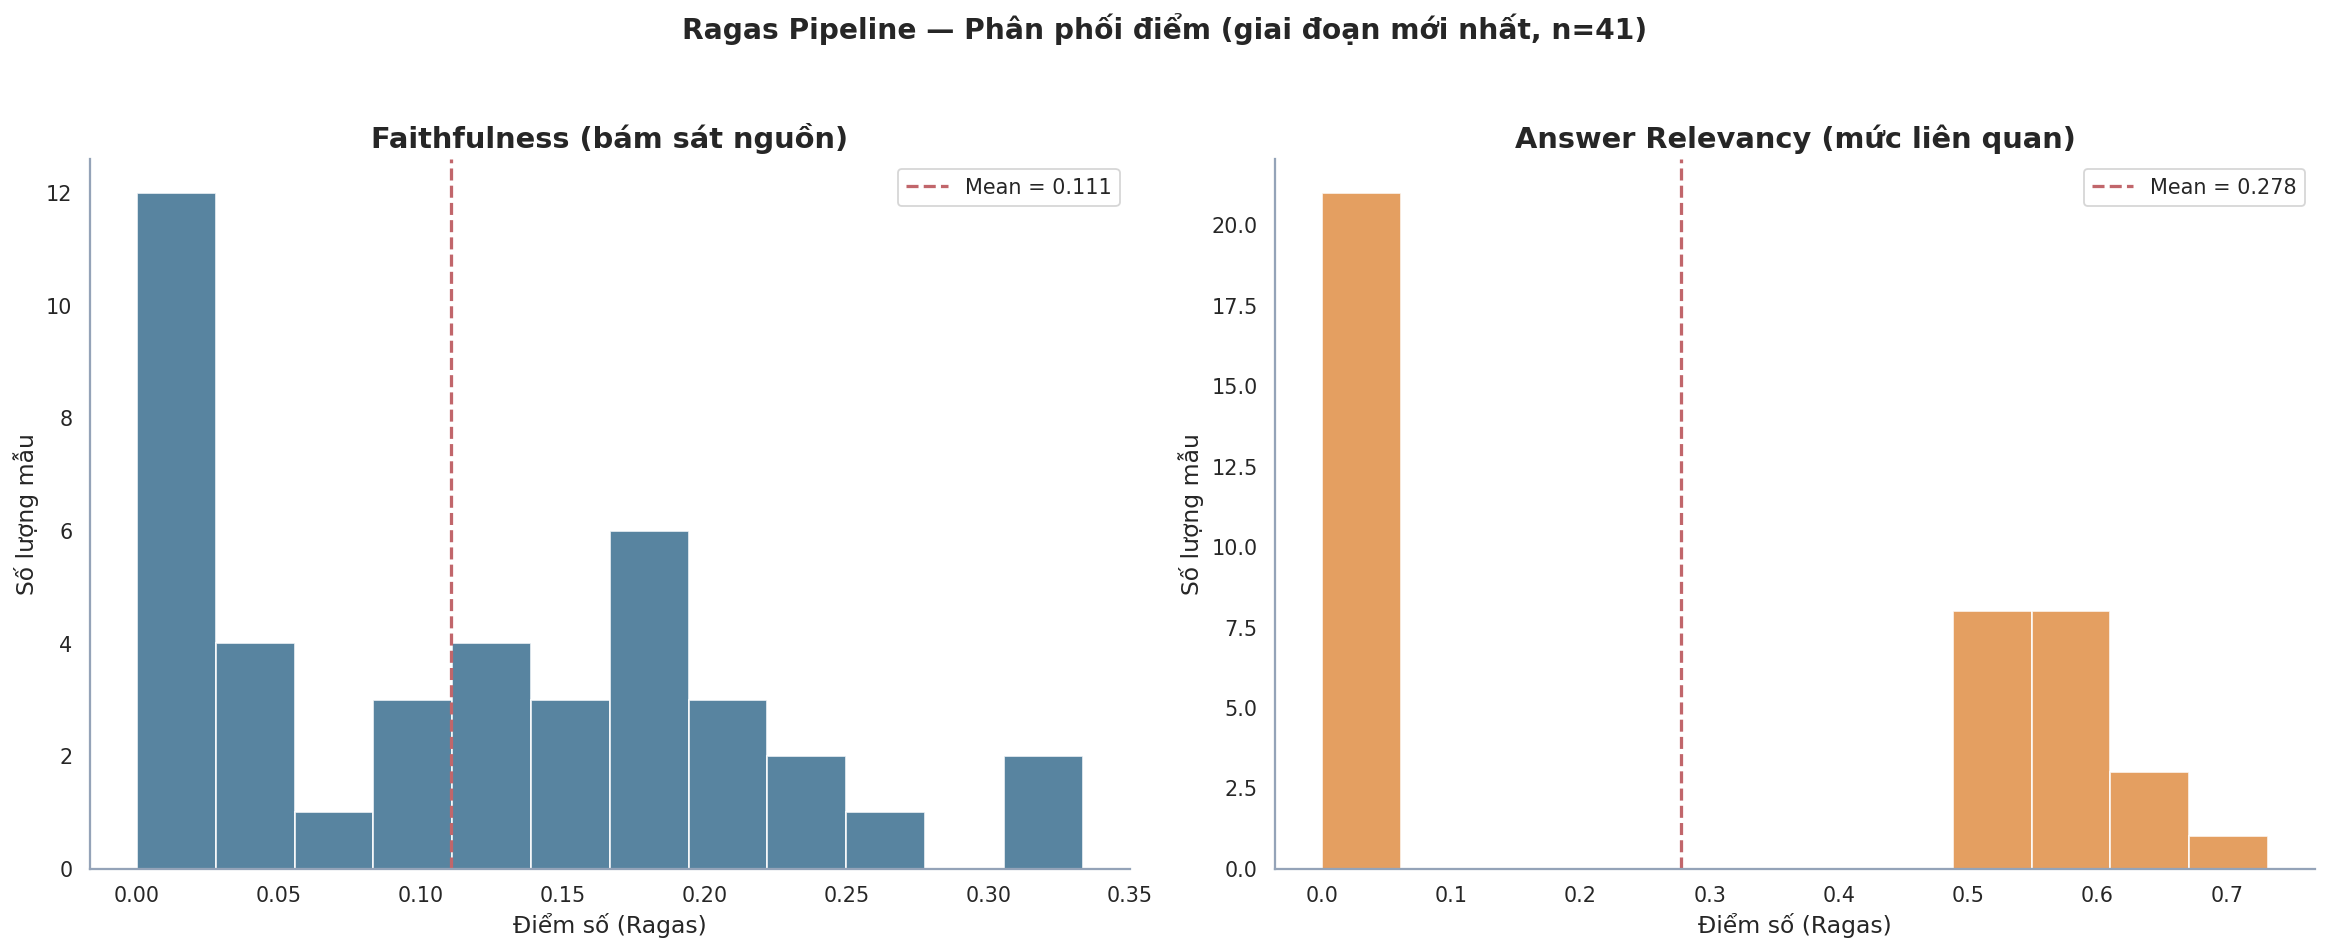

In [27]:
# --- Hình 5.2: Phân phối Faithfulness & Answer Relevancy (giai đoạn mới nhất) ---
df_latest_pipe = pd.read_csv(ragas_pipeline_stages[stage_labels_short[-1]])

fig, axes = plt.subplots(1, 2, figsize=(18.1, 7.1))
for ax, col, color, title in zip(
    axes, ["faithfulness", "answer_relevancy"], [PALETTE["primary"], PALETTE["secondary"]],
    ["Faithfulness (bám sát nguồn)", "Answer Relevancy (mức liên quan)"]
):
    ax.hist(df_latest_pipe[col], bins=12, color=color, alpha=0.85, edgecolor="white")
    ax.axvline(df_latest_pipe[col].mean(), color=PALETTE["danger"], linestyle="--", linewidth=1.8,
               label=f"Mean = {df_latest_pipe[col].mean():.3f}")
    ax.set_title(title)
    ax.set_xlabel("Điểm số (Ragas)")
    ax.set_ylabel("Số lượng mẫu")
    ax.legend()
fig.suptitle(f"Ragas Pipeline — Phân phối điểm (giai đoạn mới nhất, n={len(df_latest_pipe)})", fontweight="bold", y=1.03)
plt.tight_layout()
plt.show()


**Khuyến nghị tiếp theo:** Vì điểm số đã tăng đúng hướng sau khi vá lỗi nhưng vẫn ở mức khiêm tốn, nên xem đây là
**điểm cần điều tra tiếp** trước khi kết luận. Có thể thử: (1) tăng số chunk retrieved đưa vào đối chiếu thay vì cố
định top-3, (2) kiểm tra thủ công một số case điểm thấp để xem là do LLM lấy thông tin ngoài phạm vi context, hay
do bản thân retrieval Stage 2 vẫn chưa đưa đúng chunk liên quan (mục 4 cho thấy NDCG@3 mới đạt ~0.81, chưa hoàn hảo).


## 6. QA Agent — Chất lượng Câu trả lời (G-Eval)

Đánh giá chất lượng các câu trả lời hỏi-đáp follow-up (`/chat`, dựa trên context đã cache từ report) theo 5 tiêu
chí G-Eval: **faithfulness**, **relevance**, **safety**, **consistency**, **clarity**.


In [28]:
qa_eval = load_json(RESULTS_DIR / "qa_eval.json")
qa_summary = qa_eval["summary"]
df_qa = pd.DataFrame(qa_eval["records"])

print(f"Tổng số cặp QA               : {qa_summary['n_qa_pairs']}")
print(f"Số lỗi sinh câu trả lời      : {qa_summary['n_chat_failed']}")
print(f"Số lỗi chấm điểm G-Eval      : {qa_summary['n_geval_failed']}")
print()
for k, v in qa_summary["average_scores"].items():
    print(f"  {k:<15}: {v:.3f} / 5")


Tổng số cặp QA               : 449
Số lỗi sinh câu trả lời      : 0
Số lỗi chấm điểm G-Eval      : 1

  faithfulness   : 4.967 / 5
  relevance      : 4.996 / 5
  safety         : 4.811 / 5
  consistency    : 4.998 / 5
  clarity        : 4.296 / 5


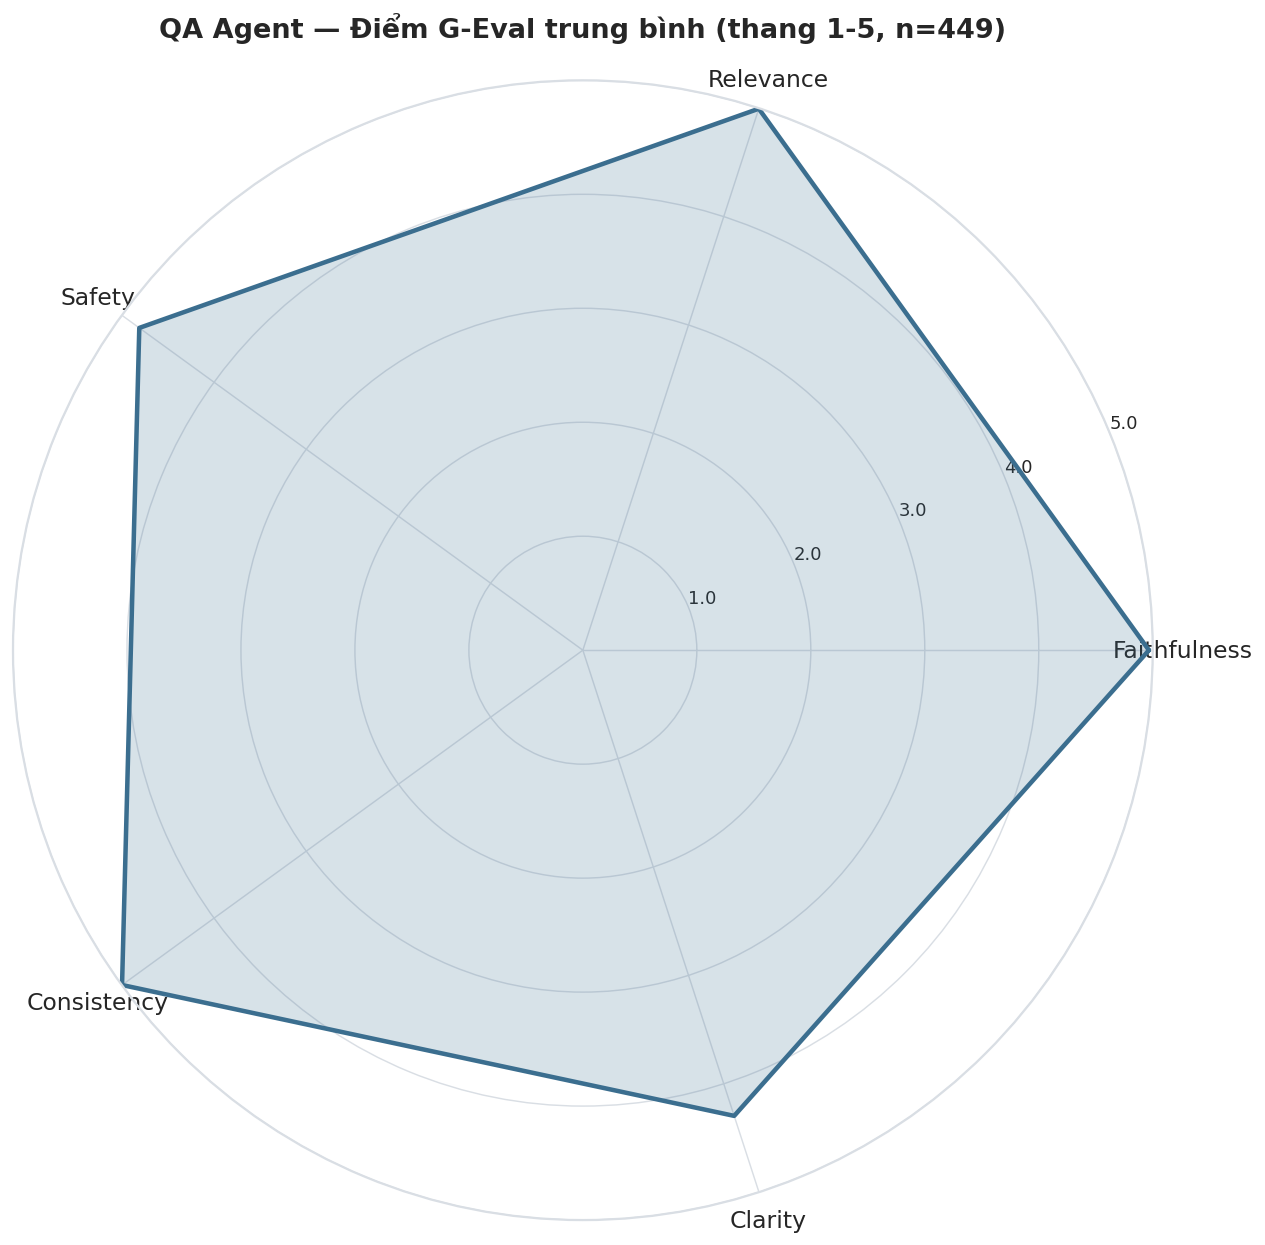

In [29]:
# --- Hình 6.1: Điểm trung bình theo từng tiêu chí G-Eval (radar) ---
from math import pi

criteria = list(qa_summary["average_scores"].keys())
values = list(qa_summary["average_scores"].values())
values_norm = [v / 5 for v in values]

N = len(criteria)
angles = [n / float(N) * 2 * pi for n in range(N)]
angles += angles[:1]
values_norm += values_norm[:1]

fig, ax = plt.subplots(figsize=(9.9, 9.9), subplot_kw=dict(polar=True))
ax.plot(angles, values_norm, linewidth=2.5, color=PALETTE["primary"])
ax.fill(angles, values_norm, alpha=0.2, color=PALETTE["primary"])
ax.set_xticks(angles[:-1])
ax.set_xticklabels([c.capitalize() for c in criteria], fontsize=13)
ax.set_ylim(0, 1)
ax.set_yticks([0.2, 0.4, 0.6, 0.8, 1.0])
ax.set_yticklabels(["1.0", "2.0", "3.0", "4.0", "5.0"], fontsize=10)
ax.grid(True, color="#D9DEE4", linewidth=0.8)
ax.spines["polar"].set_color("#D9DEE4")
ax.set_facecolor("white")
ax.set_title(f"QA Agent — Điểm G-Eval trung bình (thang 1-5, n={qa_summary['n_qa_pairs']})",
             fontsize=15, fontweight="bold", pad=24)
plt.tight_layout()
plt.show()


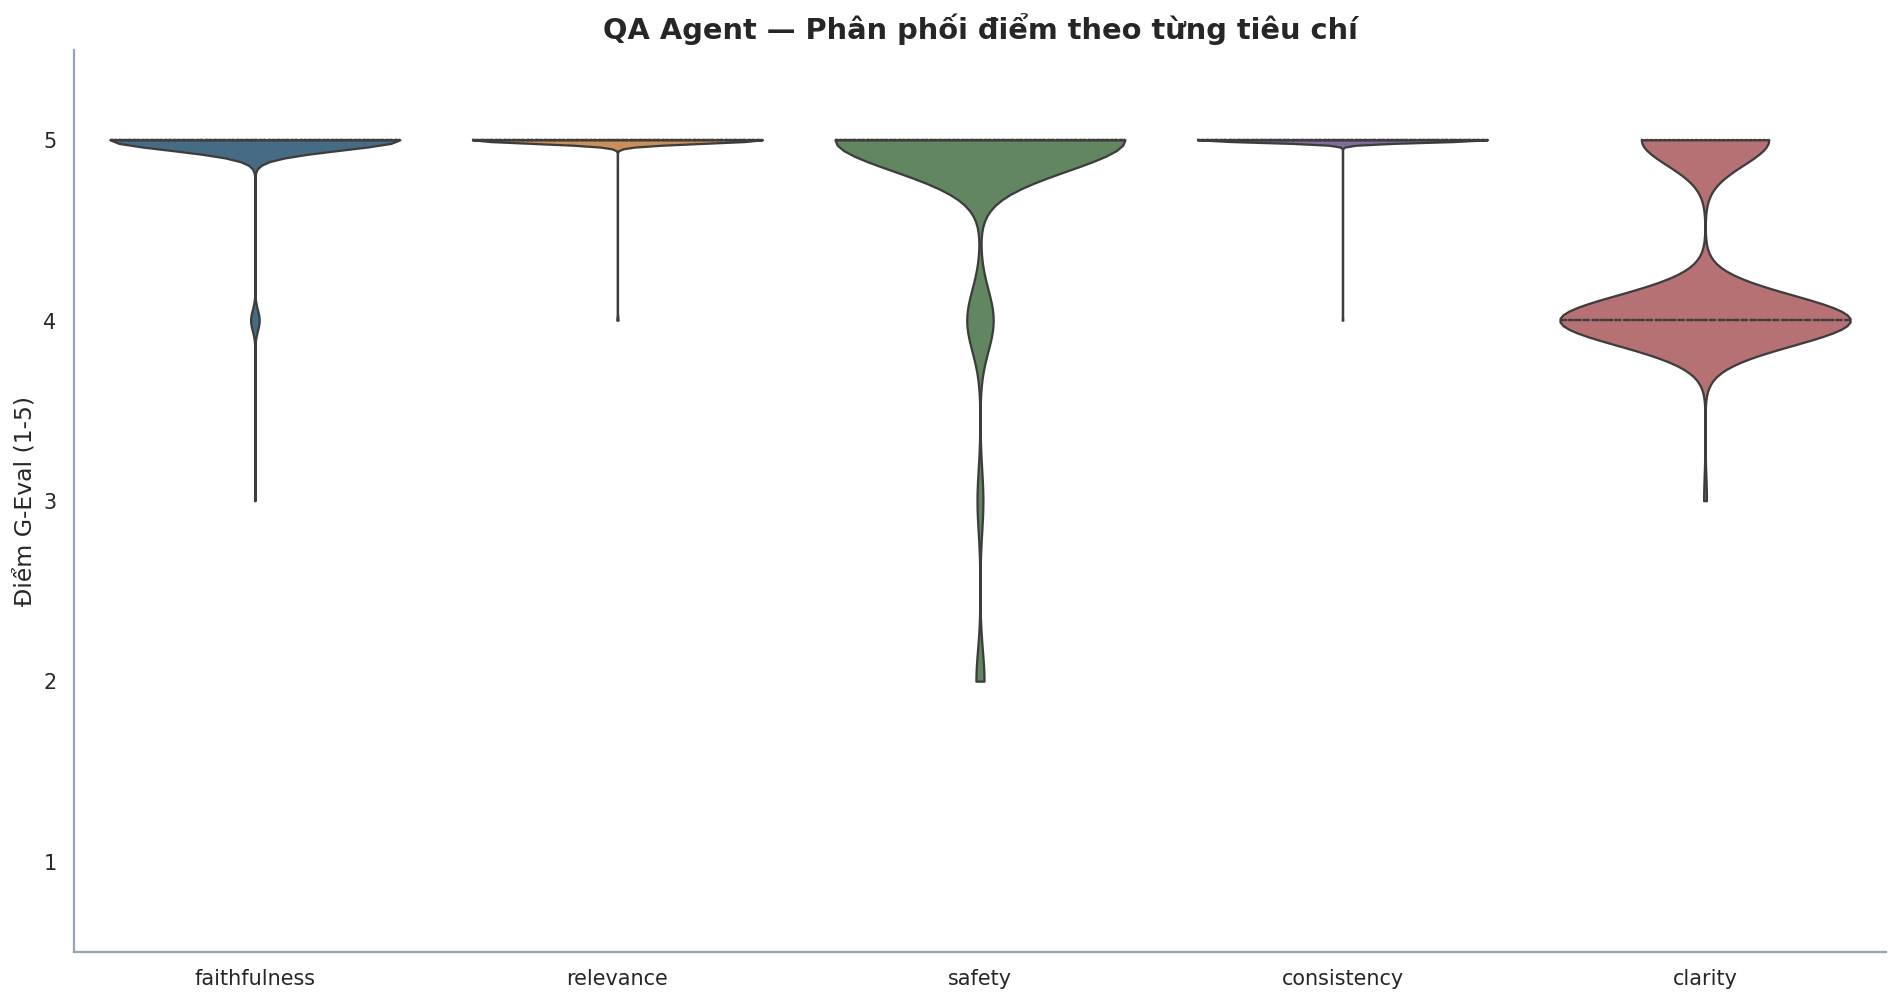

In [30]:
# --- Hình 6.2: Phân phối điểm số theo từng tiêu chí (violin plot) ---
score_cols = ["faithfulness", "relevance", "safety", "consistency", "clarity"]
df_qa_melt = df_qa.melt(value_vars=score_cols, var_name="criterion", value_name="score").dropna()

fig, ax = plt.subplots(figsize=(14.8, 7.9))
sns.violinplot(data=df_qa_melt, x="criterion", y="score", ax=ax, palette=CAT_PALETTE, cut=0, inner="quartile")
ax.set_ylim(0.5, 5.5)
ax.set_xlabel(""); ax.set_ylabel("Điểm G-Eval (1-5)")
ax.set_title("QA Agent — Phân phối điểm theo từng tiêu chí")
plt.tight_layout()
plt.show()


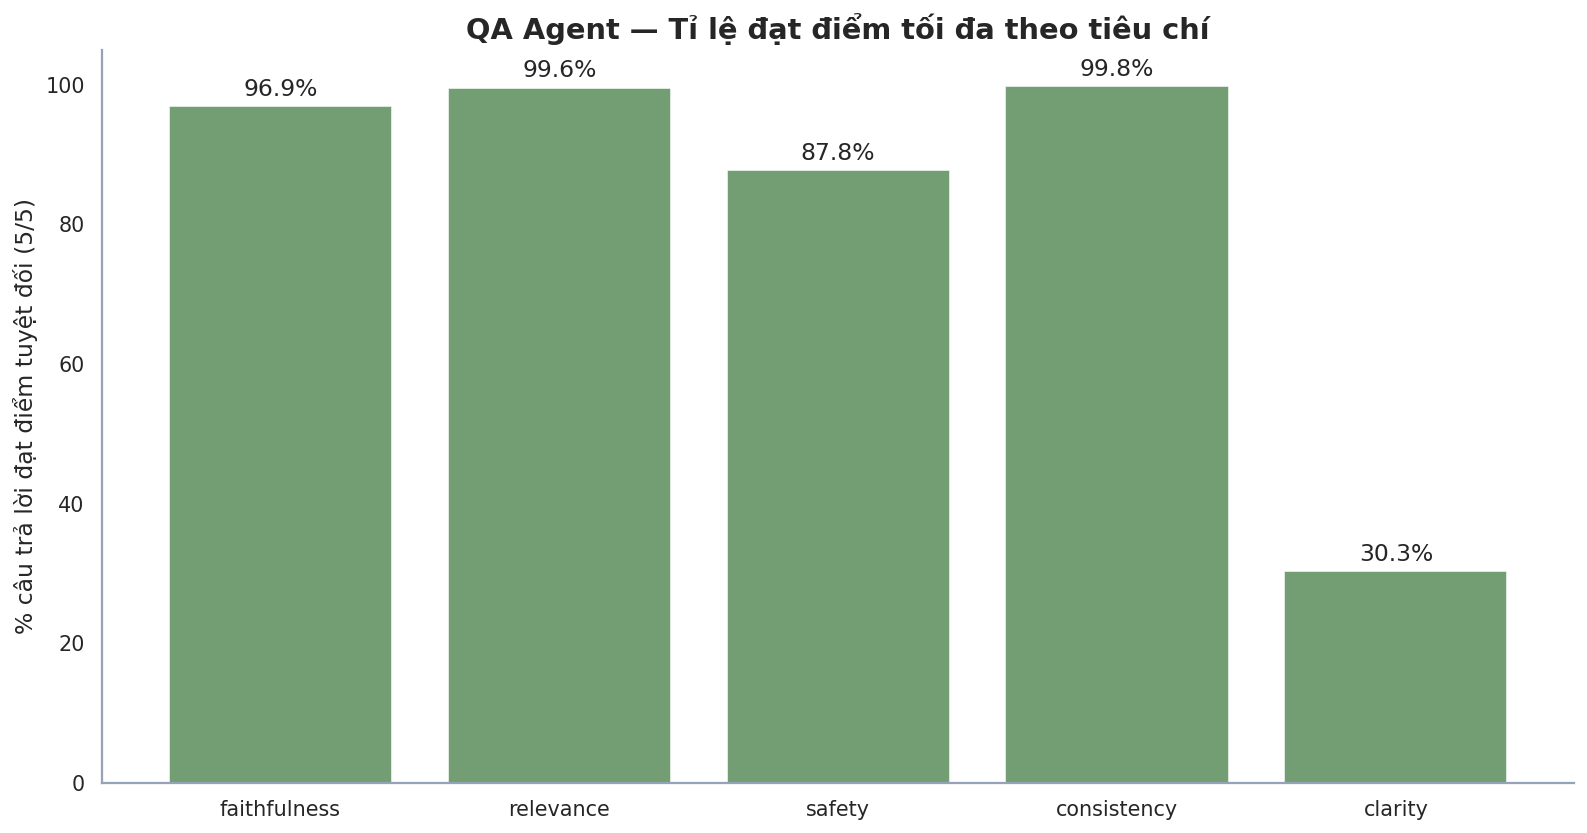

In [31]:
# --- Hình 6.3: Tỉ lệ câu trả lời đạt điểm tuyệt đối (5/5) theo từng tiêu chí ---
perfect_rate = (df_qa[score_cols] == 5).mean() * 100
fig, ax = plt.subplots(figsize=(12.4, 6.6))
bars = ax.bar(perfect_rate.index, perfect_rate.values, color=PALETTE["success"], alpha=0.85)
ax.bar_label(bars, fmt="%.1f%%", padding=3)
ax.set_ylim(0, 105)
ax.set_ylabel("% câu trả lời đạt điểm tuyệt đối (5/5)")
ax.set_title("QA Agent — Tỉ lệ đạt điểm tối đa theo tiêu chí")
plt.tight_layout()
plt.show()


**Nhận xét — QA Agent:** Chất lượng câu trả lời rất cao trên hầu hết tiêu chí — **faithfulness, relevance,
safety, consistency** đều đạt trung bình **>4.8/5**. Tiêu chí **clarity** thấp hơn đáng kể (**4.30/5**), gợi ý câu
trả lời đôi khi vẫn dùng thuật ngữ y khoa khó hiểu với người không chuyên.


## 7. Pipeline Outputs — Kết quả Đầu-cuối trên các Ca Thực tế

Phân tích các báo cáo hoàn chỉnh mà pipeline sinh ra cho từng ca bệnh thực tế.


In [32]:
pipeline_dir = RESULTS_DIR / "pipeline_outputs"
pipeline_files = sorted(pipeline_dir.glob("*.json"))

rows = []
for fp in pipeline_files:
    d = load_json(fp)
    report = d.get("report", {})
    t1 = report.get("tier_1_structured", {})
    rows.append({
        "file": fp.stem,
        "image_id": report.get("image_id", fp.stem),
        "organ": t1.get("organ"),
        "label": t1.get("label"),
        "confidence": t1.get("confidence"),
        "risk_category": t1.get("risk_category"),
        "severity": t1.get("severity"),
        "severity_level": t1.get("severity_level"),
        "label_agreement": t1.get("label_agreement"),
        "hard_conflict": t1.get("hard_conflict"),
        "icd10_agreement": t1.get("icd10_agreement"),
    })
df_pipeline = pd.DataFrame(rows)
print(f"Tổng số ca trong pipeline_outputs: {len(df_pipeline)}")
df_pipeline.head(10)


Tổng số ca trong pipeline_outputs: 41


,file,image_id,organ,label,confidence,risk_category,severity,severity_level,label_agreement,hard_conflict,icd10_agreement
0,0000,0000,thyroid,malignant,0.9976,Highly suspicious (TI-RADS 5),critical,4,False,True,False
1,0002,0002,thyroid,benign,1.0000,Mildly suspicious (TI-RADS 3),significant,2,True,False,False
2,0003,0003,thyroid,benign,0.9734,Mildly suspicious (TI-RADS 3),significant,2,True,False,False
3,0004,0004,thyroid,malignant,0.9497,Highly suspicious (TI-RADS 5),critical,4,False,True,False
4,0005,0005,thyroid,malignant,0.8704,Highly suspicious (TI-RADS 5),urgent,3,False,True,False
5,0006,0006,thyroid,benign,0.9991,Mildly suspicious (TI-RADS 3),significant,2,False,True,False
6,0007,0007,thyroid,benign,0.9061,Mildly suspicious (TI-RADS 3),significant,2,True,False,False
7,0009,0009,thyroid,benign,0.7395,Mildly suspicious (TI-RADS 3),significant,2,True,False,False
8,0379,0379,thyroid,benign,0.9995,Mildly suspicious (TI-RADS 3),significant,2,True,False,True
9,0380,0380,thyroid,malignant,0.9981,Highly suspicious (TI-RADS 5),critical,4,False,True,False


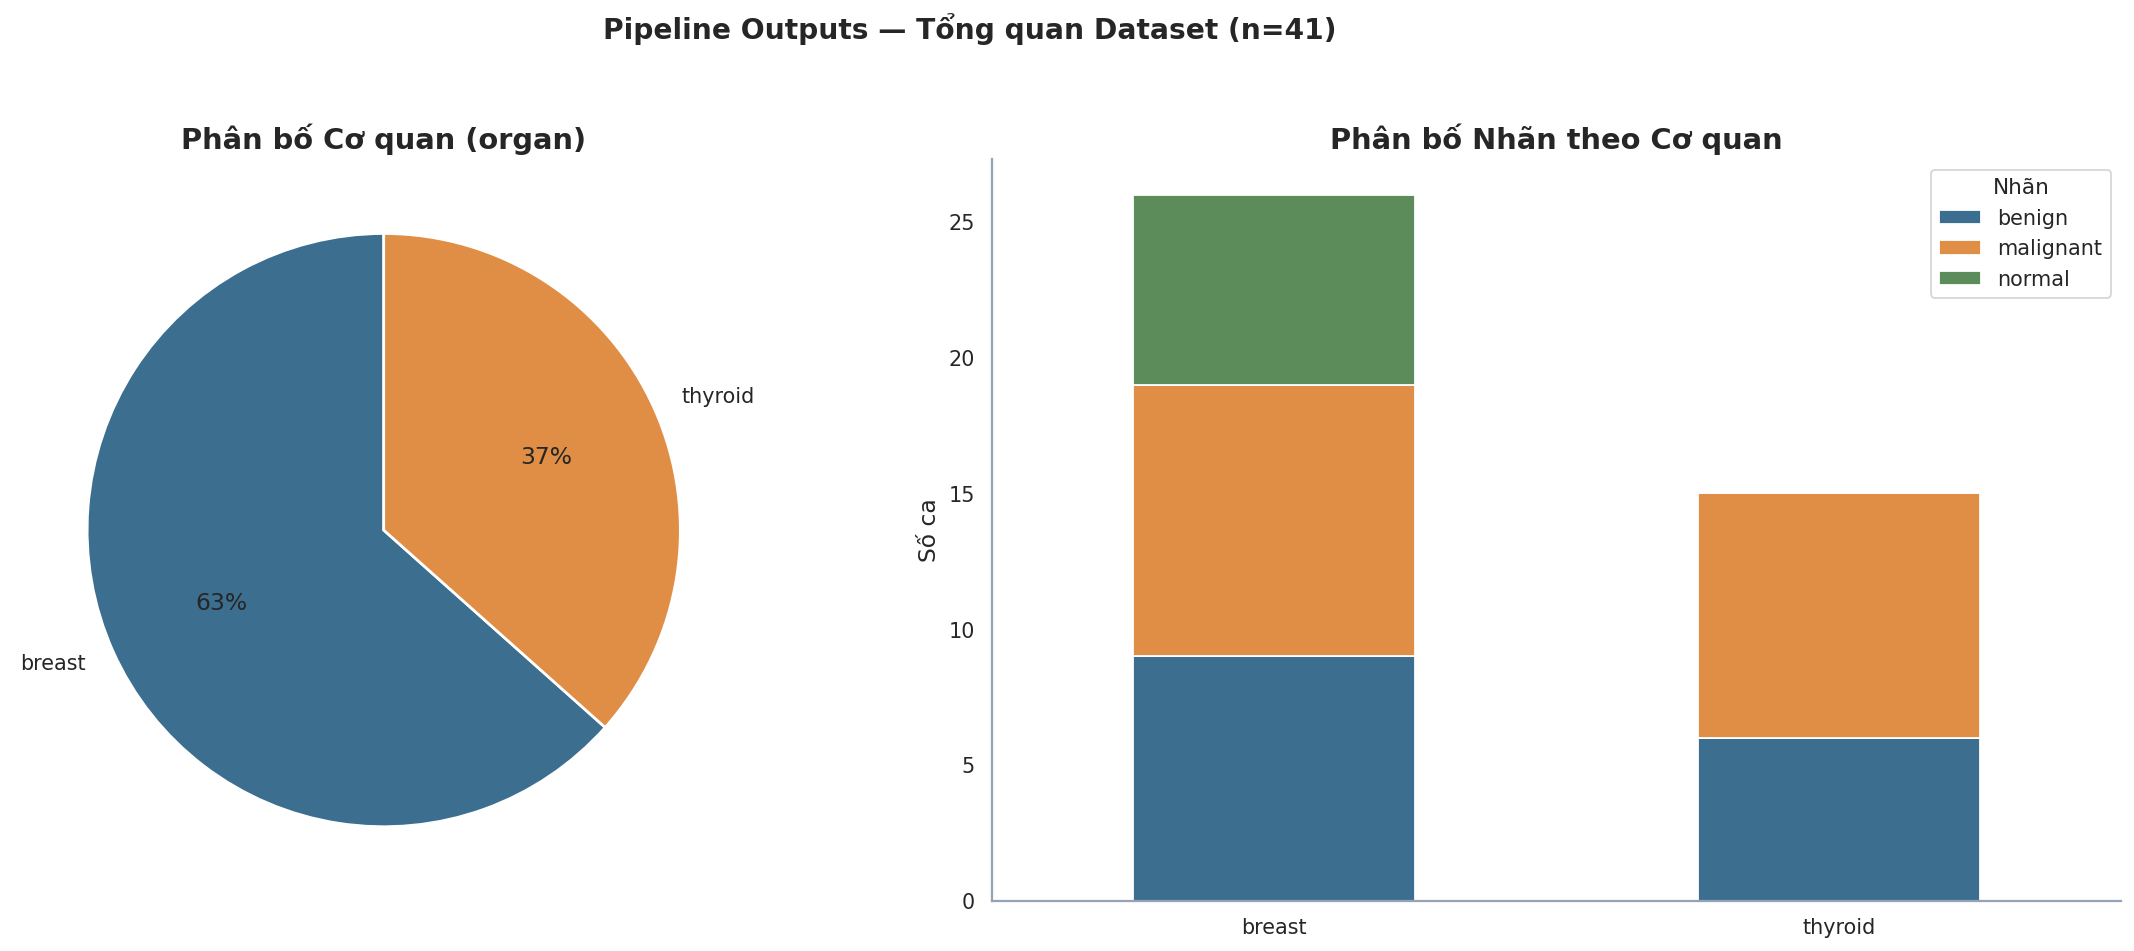

In [33]:
# --- Hình 7.1: Phân bố nhãn dự đoán theo cơ quan (organ) ---
fig, axes = plt.subplots(1, 2, figsize=(18.1, 7.1))

organ_counts = df_pipeline["organ"].value_counts()
axes[0].pie(organ_counts.values, labels=organ_counts.index, autopct="%1.0f%%",
            colors=CAT_PALETTE[:len(organ_counts)], startangle=90,
            wedgeprops={"edgecolor": "white", "linewidth": 1.5})
axes[0].set_title("Phân bố Cơ quan (organ)")

label_organ = df_pipeline.groupby(["organ", "label"]).size().unstack(fill_value=0)
label_organ.plot(kind="bar", stacked=True, ax=axes[1], color=CAT_PALETTE[:label_organ.shape[1]])
axes[1].set_title("Phân bố Nhãn theo Cơ quan")
axes[1].set_xlabel(""); axes[1].set_ylabel("Số ca")
axes[1].tick_params(axis="x", rotation=0)
axes[1].legend(title="Nhãn")

fig.suptitle(f"Pipeline Outputs — Tổng quan Dataset (n={len(df_pipeline)})", fontweight="bold", y=1.03)
plt.tight_layout()
plt.show()


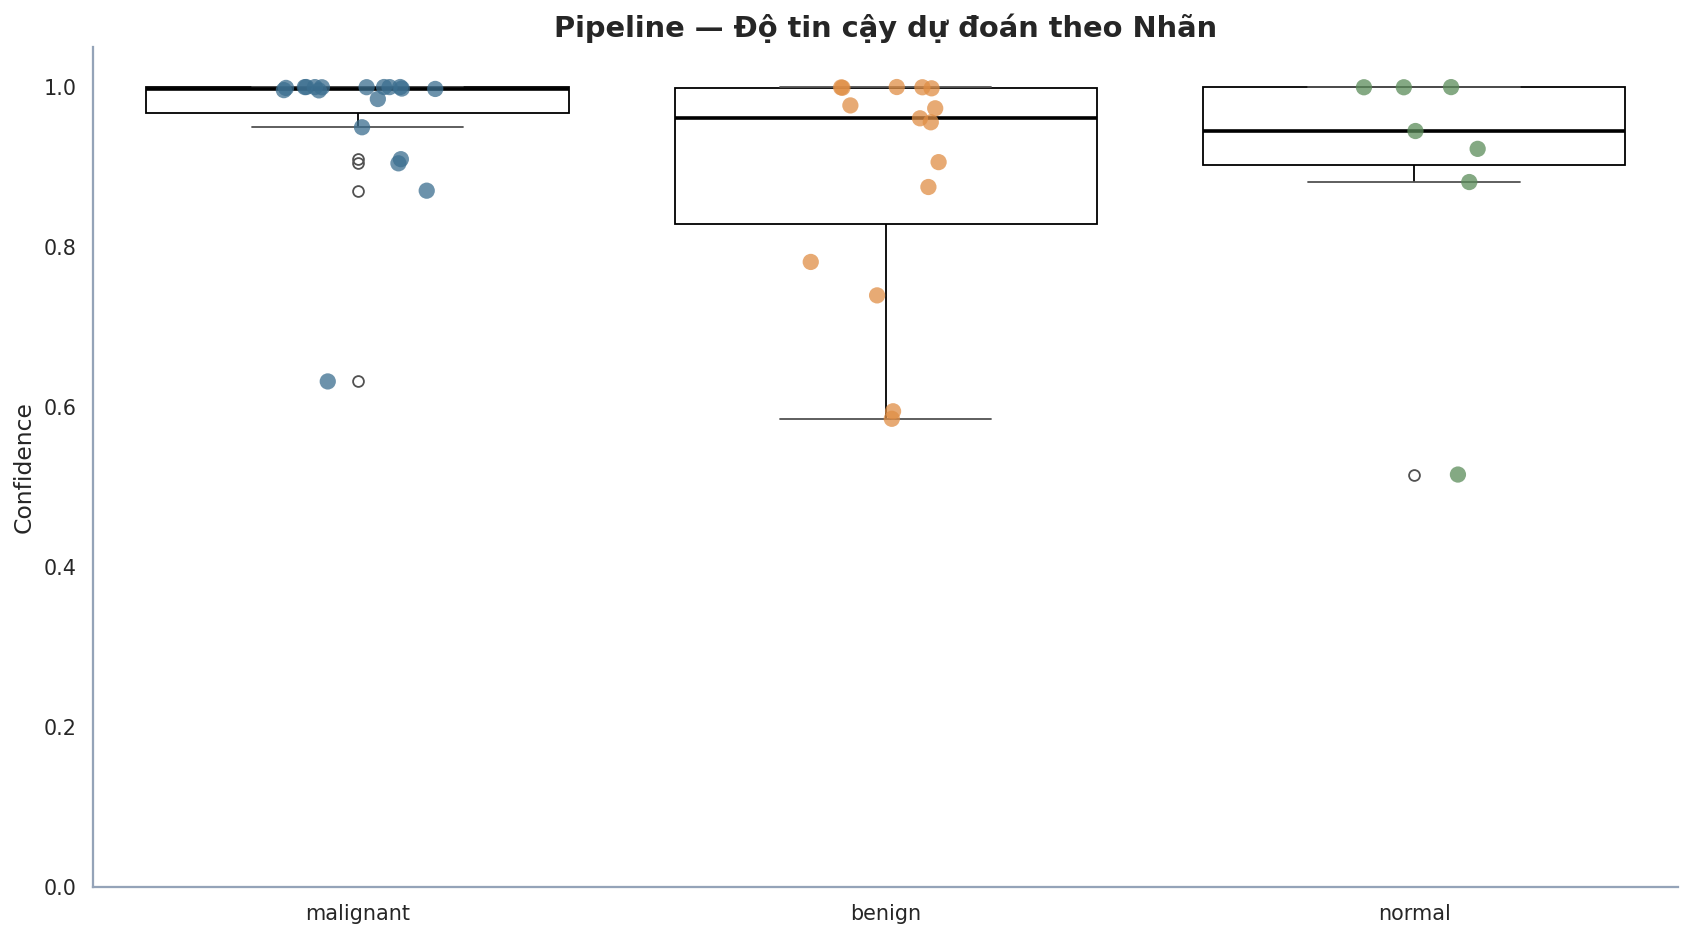

In [34]:
# --- Hình 7.2: Phân phối độ tin cậy (confidence) theo nhãn dự đoán ---
fig, ax = plt.subplots(figsize=(13.2, 7.4))
sns.stripplot(data=df_pipeline, x="label", y="confidence", hue="label", ax=ax,
              palette=CAT_PALETTE, size=9, alpha=0.75, jitter=0.15, legend=False)
sns.boxplot(data=df_pipeline, x="label", y="confidence", ax=ax,
            showcaps=True, boxprops={"facecolor": "none", "edgecolor": "black"},
            whiskerprops={"color": "black"}, medianprops={"color": "black", "linewidth": 2})
ax.set_ylim(0, 1.05)
ax.set_xlabel(""); ax.set_ylabel("Confidence")
ax.set_title("Pipeline — Độ tin cậy dự đoán theo Nhãn")
plt.tight_layout()
plt.show()


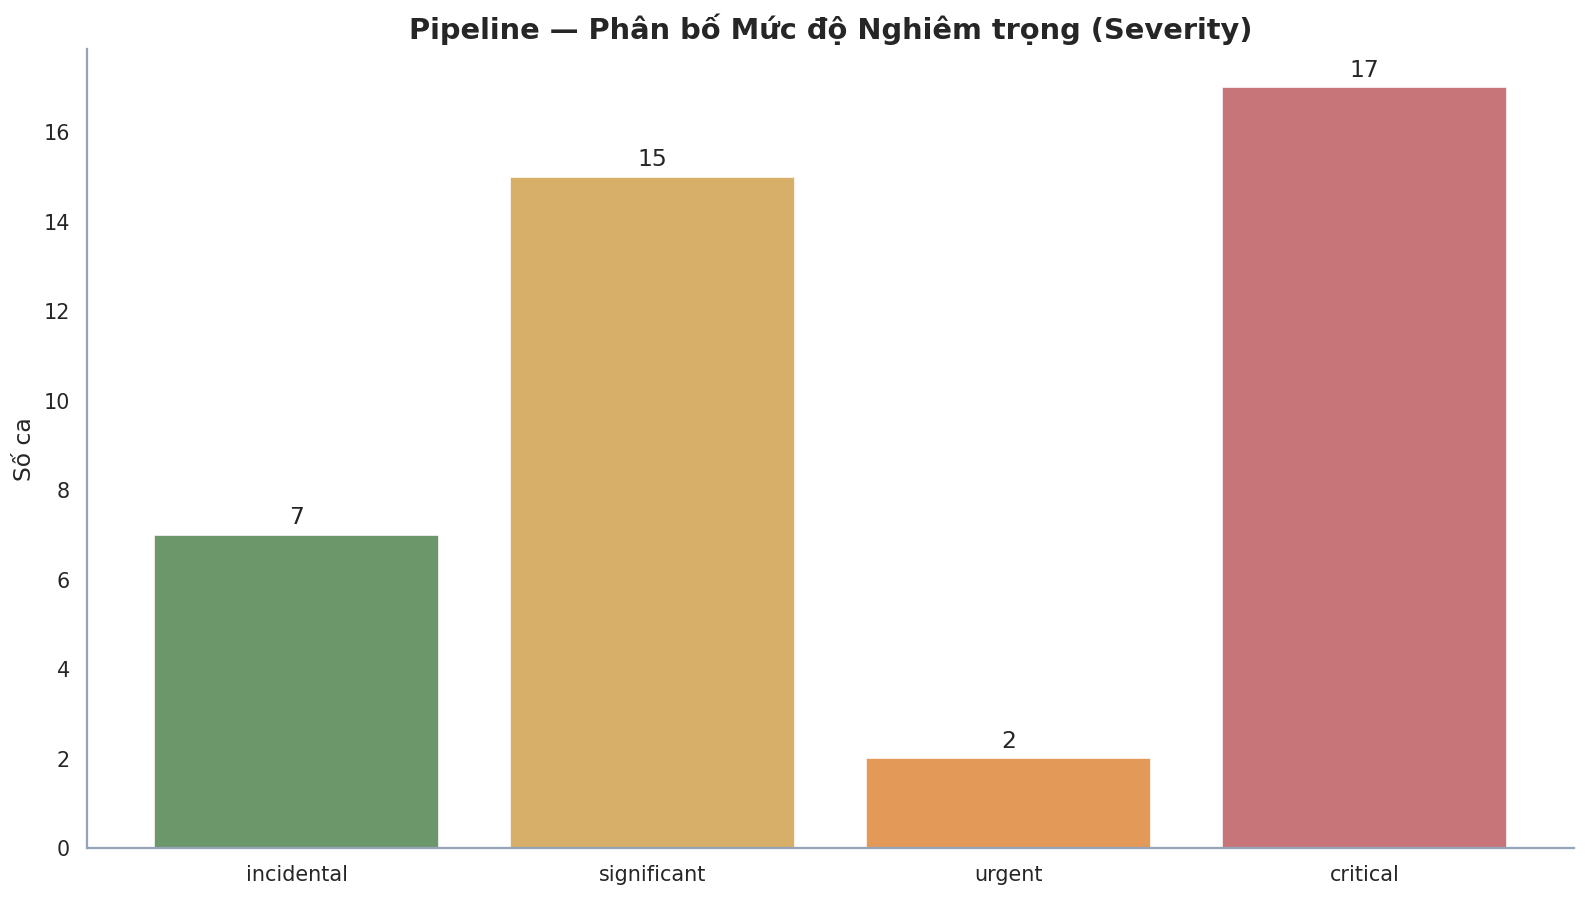

In [35]:
# --- Hình 7.3: Mức độ nghiêm trọng (severity) — thứ tự hợp lý ---
severity_order = ["incidental", "significant", "urgent", "critical"]
sev_counts = df_pipeline["severity"].value_counts().reindex(severity_order).fillna(0)

fig, ax = plt.subplots(figsize=(12.4, 7.1))
colors_sev = [PALETTE["success"], PALETTE["warning"], PALETTE["secondary"], PALETTE["danger"]]
bars = ax.bar(sev_counts.index, sev_counts.values, color=colors_sev, alpha=0.9)
ax.bar_label(bars, fmt="%.0f", padding=3)
ax.set_ylabel("Số ca")
ax.set_title("Pipeline — Phân bố Mức độ Nghiêm trọng (Severity)")
plt.tight_layout()
plt.show()


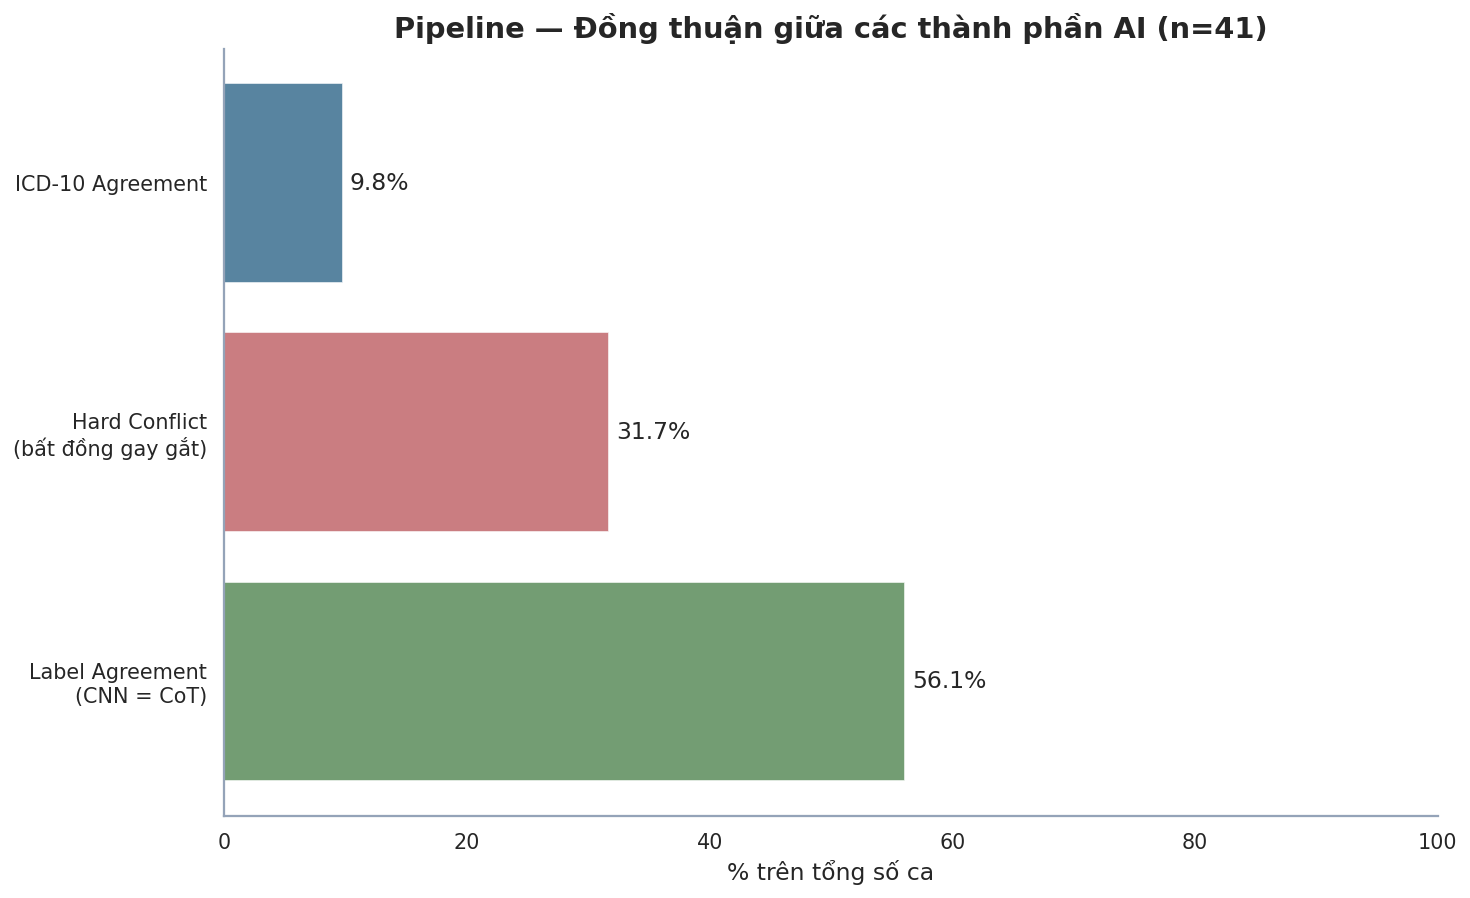

In [36]:
# --- Hình 7.4: Tỉ lệ đồng thuận CNN vs CoT & ICD-10 agreement trên các ca thực tế ---
agreement_summary = pd.DataFrame({
    "Chỉ số": ["Label Agreement\n(CNN = CoT)", "Hard Conflict\n(bất đồng gay gắt)", "ICD-10 Agreement"],
    "Tỷ lệ (%)": [
        df_pipeline["label_agreement"].mean() * 100,
        df_pipeline["hard_conflict"].mean() * 100,
        df_pipeline["icd10_agreement"].mean() * 100,
    ]
})

fig, ax = plt.subplots(figsize=(11.5, 7.1))
colors_agree = [PALETTE["success"], PALETTE["danger"], PALETTE["primary"]]
bars = ax.barh(agreement_summary["Chỉ số"], agreement_summary["Tỷ lệ (%)"], color=colors_agree, alpha=0.85)
ax.bar_label(bars, fmt="%.1f%%", padding=4)
ax.set_xlim(0, 100)
ax.set_xlabel("% trên tổng số ca")
ax.set_title(f"Pipeline — Đồng thuận giữa các thành phần AI (n={len(df_pipeline)})")
plt.tight_layout()
plt.show()


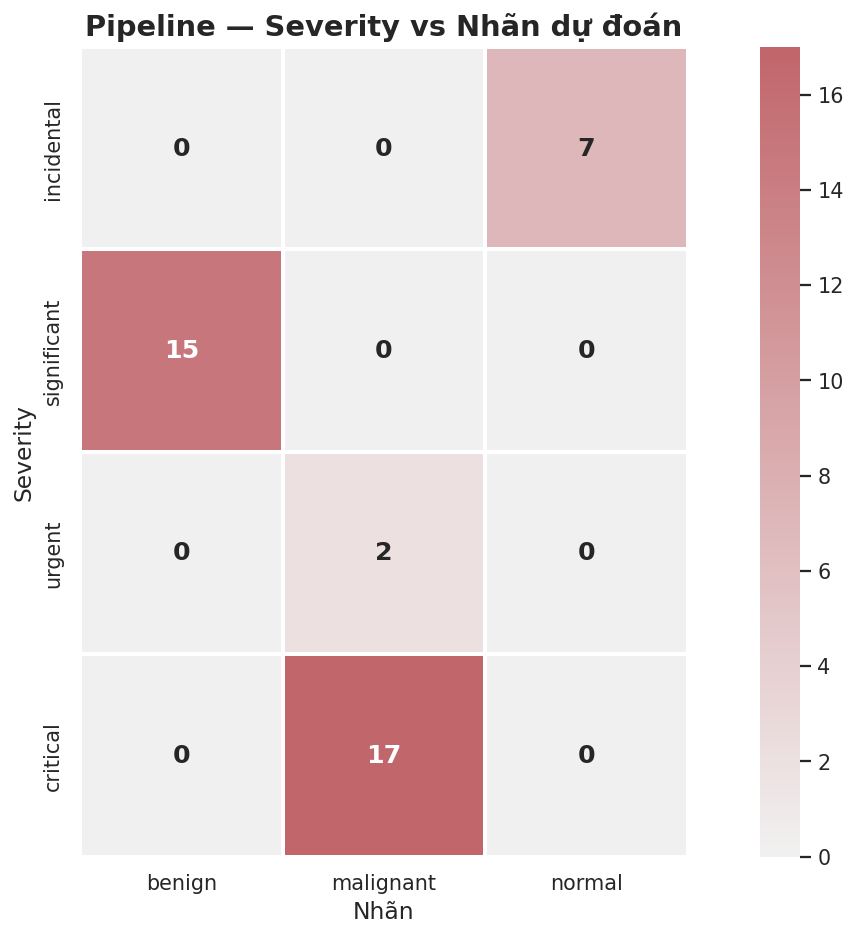

In [37]:
# --- Hình 7.5: Ma trận nhiệt Severity x Label ---
pivot_sev_label = pd.crosstab(df_pipeline["severity"], df_pipeline["label"])
pivot_sev_label = pivot_sev_label.reindex(severity_order).fillna(0).astype(int)

fig, ax = plt.subplots(figsize=(11.5, 7.4))
sns.heatmap(pivot_sev_label, annot=True, fmt="d", cmap=SEQ_CMAP_WARM, linewidths=2, linecolor="white", ax=ax,
            annot_kws={"size": 14, "weight": "bold"}, square=True)
ax.set_title("Pipeline — Severity vs Nhãn dự đoán")
ax.set_xlabel("Nhãn"); ax.set_ylabel("Severity")
plt.tight_layout()
plt.show()


In [38]:
# --- Bảng 7.6: Danh sách các ca có hard_conflict = True (cần bác sĩ review ưu tiên) ---
conflict_cases = df_pipeline[df_pipeline["hard_conflict"] == True][
    ["file", "organ", "label", "confidence", "severity", "risk_category"]
].sort_values("confidence", ascending=False).reset_index(drop=True)

print(f"Số ca có xung đột gay gắt (hard_conflict=True): {len(conflict_cases)} / {len(df_pipeline)} "
      f"({len(conflict_cases)/len(df_pipeline):.1%})")
conflict_cases.style.background_gradient(subset=["confidence"], cmap="Reds")


Số ca có xung đột gay gắt (hard_conflict=True): 13 / 41 (31.7%)


,file,organ,label,confidence,severity,risk_category
0,0388,thyroid,malignant,1.000000,critical,Highly suspicious (TI-RADS 5)
1,0383,thyroid,malignant,0.999900,critical,Highly suspicious (TI-RADS 5)
2,0384,thyroid,malignant,0.999900,critical,Highly suspicious (TI-RADS 5)
3,normal (107),breast,normal,0.999700,incidental,Negative (BI-RADS 1)
4,0006,thyroid,benign,0.999100,significant,Mildly suspicious (TI-RADS 3)
5,0380,thyroid,malignant,0.998100,critical,Highly suspicious (TI-RADS 5)
6,0000,thyroid,malignant,0.997600,critical,Highly suspicious (TI-RADS 5)
7,0385,thyroid,malignant,0.996100,critical,Highly suspicious (TI-RADS 5)
8,malignant (167),breast,benign,0.977000,significant,Probably benign (BI-RADS 3)
9,0004,thyroid,malignant,0.949700,critical,Highly suspicious (TI-RADS 5)


**Nhận xét — Pipeline tổng hợp:** Trên tập 41 ca thực tế (26 breast, 15 thyroid), tỉ lệ **ICD-10 agreement**
thấp hơn nhiều so với label agreement — dù CNN và CoT đồng ý về nhãn, việc gán mã ICD-10 chi tiết vẫn phân kỳ.
Các ca có `hard_conflict=True` nên được ưu tiên đưa cho bác sĩ radiologist xem xét thủ công.


## 8. Tổng kết — Đóng góp & Cải thiện Xuyên suốt Hệ thống

Bảng dưới đây tổng hợp **mức độ cải thiện trước/sau** ở từng nơi có phiên bản so sánh, giúp thấy rõ đóng góp của
từng thay đổi kỹ thuật.


In [39]:
contribution_rows = [
    {
        "Thành phần": "Router — OOD Threshold",
        "Trước": f"F1={ood_old['f1']:.3f} (thresh={ood_old['ood_threshold']})",
        "Sau": f"F1={ood_new['f1']:.3f} (thresh={ood_new['ood_threshold']})",
        "Cải thiện": f"{(ood_new['f1']-ood_old['f1'])/ood_old['f1']:+.0%}",
        "Loại thay đổi": "Điều chỉnh vận hành (không train lại)",
    },
    {
        "Thành phần": "CoT — BIRADS prompt (Gemini, BUSI)",
        "Trước": f"F1={df_cot[(df_cot.config=='Gemini (chuẩn)')&(df_cot.dataset=='BUSI')]['macro_f1'].iloc[0]:.3f}",
        "Sau": f"F1={df_cot[(df_cot.config=='Gemini + BIRADS')&(df_cot.dataset=='BUSI')]['macro_f1'].iloc[0]:.3f}",
        "Cải thiện": f"{(df_cot[(df_cot.config=='Gemini + BIRADS')&(df_cot.dataset=='BUSI')]['macro_f1'].iloc[0] - df_cot[(df_cot.config=='Gemini (chuẩn)')&(df_cot.dataset=='BUSI')]['macro_f1'].iloc[0])/df_cot[(df_cot.config=='Gemini (chuẩn)')&(df_cot.dataset=='BUSI')]['macro_f1'].iloc[0]:+.0%}",
        "Loại thay đổi": "Cải tiến prompt engineering",
    },
    {
        "Thành phần": "CoT — BIRADS prompt (Gemini, TN3K)",
        "Trước": f"F1={df_cot[(df_cot.config=='Gemini (chuẩn)')&(df_cot.dataset=='TN3K')]['macro_f1'].iloc[0]:.3f}",
        "Sau": f"F1={df_cot[(df_cot.config=='Gemini + BIRADS')&(df_cot.dataset=='TN3K')]['macro_f1'].iloc[0]:.3f}",
        "Cải thiện": f"{(df_cot[(df_cot.config=='Gemini + BIRADS')&(df_cot.dataset=='TN3K')]['macro_f1'].iloc[0] - df_cot[(df_cot.config=='Gemini (chuẩn)')&(df_cot.dataset=='TN3K')]['macro_f1'].iloc[0])/df_cot[(df_cot.config=='Gemini (chuẩn)')&(df_cot.dataset=='TN3K')]['macro_f1'].iloc[0]:+.0%}",
        "Loại thay đổi": "Cải tiến prompt engineering",
    },
    {
        "Thành phần": "CoT — BIRADS prompt (GPT, TN3K)",
        "Trước": f"F1={df_cot[(df_cot.config=='GPT (chuẩn)')&(df_cot.dataset=='TN3K')]['macro_f1'].iloc[0]:.3f}",
        "Sau": f"F1={df_cot[(df_cot.config=='GPT + BIRADS')&(df_cot.dataset=='TN3K')]['macro_f1'].iloc[0]:.3f}",
        "Cải thiện": f"{(df_cot[(df_cot.config=='GPT + BIRADS')&(df_cot.dataset=='TN3K')]['macro_f1'].iloc[0] - df_cot[(df_cot.config=='GPT (chuẩn)')&(df_cot.dataset=='TN3K')]['macro_f1'].iloc[0])/df_cot[(df_cot.config=='GPT (chuẩn)')&(df_cot.dataset=='TN3K')]['macro_f1'].iloc[0]:+.0%}",
        "Loại thay đổi": "Cải tiến prompt engineering",
    },
    {
        "Thành phần": "RAG — Natural Question Recall@100",
        "Trước": f"{df_nq.loc[stage_order[0], 'recall_at_100']:.1%}",
        "Sau": f"{df_nq.loc[stage_order[-1], 'recall_at_100']:.1%}",
        "Cải thiện": f"{(df_nq.loc[stage_order[-1],'recall_at_100']-df_nq.loc[stage_order[0],'recall_at_100'])/df_nq.loc[stage_order[0],'recall_at_100']:+.0%}",
        "Loại thay đổi": "Tiền xử lý + fine-tune embedding + rerank",
    },
    {
        "Thành phần": "RAG — Natural Question NDCG@3",
        "Trước": f"{df_nq.loc[stage_order[0], 'ndcg_at_3']:.3f}",
        "Sau": f"{df_nq.loc[stage_order[-1], 'ndcg_at_3']:.3f}",
        "Cải thiện": f"{(df_nq.loc[stage_order[-1],'ndcg_at_3']-df_nq.loc[stage_order[0],'ndcg_at_3'])/df_nq.loc[stage_order[0],'ndcg_at_3']:+.0%}",
        "Loại thay đổi": "Tiền xử lý + fine-tune embedding + rerank",
    },
    {
        "Thành phần": "Ragas — Context Precision",
        "Trước": f"{df_ragas_ret_summary.loc[0,'context_precision_mean']:.3f}",
        "Sau": f"{df_ragas_ret_summary.loc[2,'context_precision_mean']:.3f}",
        "Cải thiện": f"{(df_ragas_ret_summary.loc[2,'context_precision_mean']-df_ragas_ret_summary.loc[0,'context_precision_mean'])/df_ragas_ret_summary.loc[0,'context_precision_mean']:+.0%}",
        "Loại thay đổi": "Tiền xử lý + fine-tune embedding + rerank",
    },
    {
        "Thành phần": "Ragas Pipeline — Faithfulness",
        "Trước": f"{df_ragas_pipe_summary.loc[0,'faithfulness_mean']:.3f} (bug user_input)",
        "Sau": f"{df_ragas_pipe_summary.loc[2,'faithfulness_mean']:.3f} (đã vá lỗi)",
        "Cải thiện": f"{(df_ragas_pipe_summary.loc[2,'faithfulness_mean']-df_ragas_pipe_summary.loc[0,'faithfulness_mean'])/df_ragas_pipe_summary.loc[0,'faithfulness_mean']:+.0%}",
        "Loại thay đổi": "Vá lỗi đo lường (không phải thay đổi model)",
    },
    {
        "Thành phần": "Ragas Pipeline — Answer Relevancy",
        "Trước": f"{df_ragas_pipe_summary.loc[0,'answer_relevancy_mean']:.3f} (bug user_input)",
        "Sau": f"{df_ragas_pipe_summary.loc[2,'answer_relevancy_mean']:.3f} (đã vá lỗi)",
        "Cải thiện": f"{(df_ragas_pipe_summary.loc[2,'answer_relevancy_mean']-df_ragas_pipe_summary.loc[0,'answer_relevancy_mean'])/df_ragas_pipe_summary.loc[0,'answer_relevancy_mean']:+.0%}",
        "Loại thay đổi": "Vá lỗi đo lường (không phải thay đổi model)",
    },
]
df_contribution = pd.DataFrame(contribution_rows)
df_contribution.style.background_gradient(subset=["Cải thiện"], cmap="Greens",
                                            gmap=[float(x.strip('%').replace('+','')) for x in df_contribution["Cải thiện"]])\
                     .hide(axis="index")


Thành phần,Trước,Sau,Cải thiện,Loại thay đổi
Router — OOD Threshold,F1=0.659 (thresh=0.6),F1=0.906 (thresh=0.7),+37%,Điều chỉnh vận hành (không train lại)
"CoT — BIRADS prompt (Gemini, BUSI)",F1=0.775,F1=0.829,+7%,Cải tiến prompt engineering
"CoT — BIRADS prompt (Gemini, TN3K)",F1=0.533,F1=0.756,+42%,Cải tiến prompt engineering
"CoT — BIRADS prompt (GPT, TN3K)",F1=0.541,F1=0.557,+3%,Cải tiến prompt engineering
RAG — Natural Question Recall@100,23.5%,95.5%,+306%,Tiền xử lý + fine-tune embedding + rerank
RAG — Natural Question NDCG@3,0.181,0.811,+347%,Tiền xử lý + fine-tune embedding + rerank
Ragas — Context Precision,0.618,0.843,+36%,Tiền xử lý + fine-tune embedding + rerank
Ragas Pipeline — Faithfulness,0.034 (bug user_input),0.111 (đã vá lỗi),+222%,Vá lỗi đo lường (không phải thay đổi model)
Ragas Pipeline — Answer Relevancy,0.058 (bug user_input),0.278 (đã vá lỗi),+383%,Vá lỗi đo lường (không phải thay đổi model)


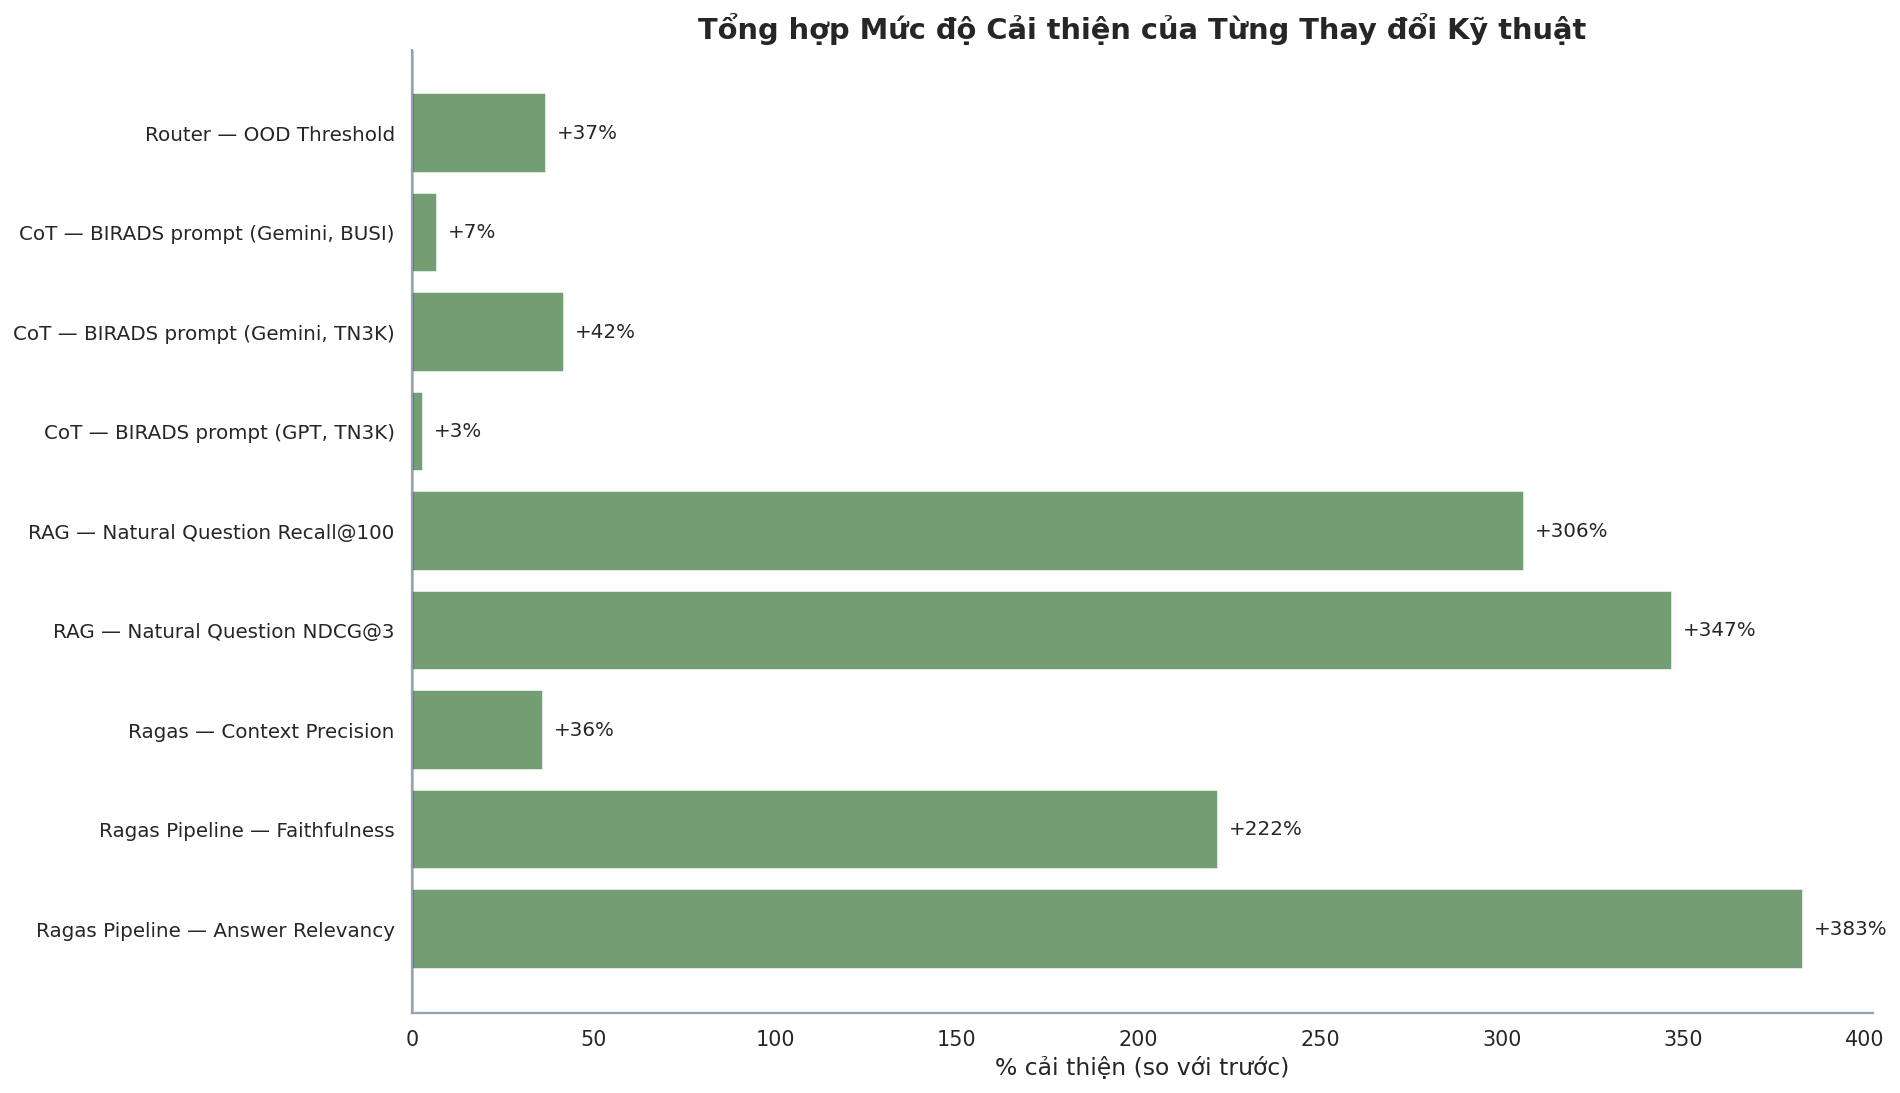

In [40]:
# --- Hình 8.1: Tổng hợp % cải thiện của tất cả các cải tiến (nhìn nhanh) ---
gains = [float(x.strip('%').replace('+', '')) for x in df_contribution["Cải thiện"]]
labels_gain = df_contribution["Thành phần"].tolist()

fig, ax = plt.subplots(figsize=(14.8, 8.6))
colors_gain = [PALETTE["success"] if g >= 0 else PALETTE["danger"] for g in gains]
y = np.arange(len(labels_gain))
bars = ax.barh(y, gains, color=colors_gain, alpha=0.85)
ax.bar_label(bars, fmt="%+.0f%%", padding=6, fontsize=11)
ax.set_yticks(y); ax.set_yticklabels(labels_gain, fontsize=11)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("% cải thiện (so với trước)")
ax.set_title("Tổng hợp Mức độ Cải thiện của Từng Thay đổi Kỹ thuật")
ax.invert_yaxis()
plt.tight_layout()
plt.show()


### Bảng chỉ số snapshot hiện tại (phiên bản mới nhất mỗi thành phần)


In [41]:
overview_rows = [
    {"Thành phần": "Router — Phân loại breast/thyroid", "Chỉ số chính": "Accuracy", "Giá trị": f"{idc['accuracy']:.1%}", "Đánh giá": "Tốt"},
    {"Thành phần": "Router — OOD Detection (ngưỡng mới)", "Chỉ số chính": "F1", "Giá trị": f"{ood_new['f1']:.3f}", "Đánh giá": "Xuất sắc"},
    {"Thành phần": "Vision — Segmentation (BUSI)", "Chỉ số chính": "Dice mean", "Giá trị": f"{vision_eval['busi']['segmentation']['lesion_samples']['dice']['mean']:.3f}", "Đánh giá": "Trung bình"},
    {"Thành phần": "Vision — Segmentation (TN3K)", "Chỉ số chính": "Dice mean", "Giá trị": f"{vision_eval['tn3k']['segmentation']['lesion_samples']['dice']['mean']:.3f}", "Đánh giá": "Tốt"},
    {"Thành phần": "CoT — Best config (GPT+BIRADS, BUSI)", "Chỉ số chính": "Macro F1", "Giá trị": f"{df_cot[(df_cot.config=='GPT + BIRADS')&(df_cot.dataset=='BUSI')]['macro_f1'].iloc[0]:.3f}", "Đánh giá": "Tốt"},
    {"Thành phần": "CoT — Best config (Gemini+BIRADS, TN3K)", "Chỉ số chính": "Macro F1", "Giá trị": f"{df_cot[(df_cot.config=='Gemini + BIRADS')&(df_cot.dataset=='TN3K')]['macro_f1'].iloc[0]:.3f}", "Đánh giá": "Tốt"},
    {"Thành phần": "RAG — Natural Question (mới nhất)", "Chỉ số chính": "NDCG@3", "Giá trị": f"{df_nq.loc[stage_order[-1],'ndcg_at_3']:.3f}", "Đánh giá": "Tốt"},
    {"Thành phần": "RAG — Production Query", "Chỉ số chính": "NDCG@3", "Giá trị": f"{df_pq.loc[stage_order[-1],'ndcg_at_3']:.3f}", "Đánh giá": "⚠️ Cần đánh giá lại kịch bản test"},
    {"Thành phần": "Ragas Pipeline — Faithfulness (mới nhất)", "Chỉ số chính": "Ragas score", "Giá trị": f"{df_ragas_pipe_summary.loc[2,'faithfulness_mean']:.3f}", "Đánh giá": "Cần theo dõi thêm"},
    {"Thành phần": "QA Agent — Faithfulness", "Chỉ số chính": "G-Eval (1-5)", "Giá trị": f"{qa_summary['average_scores']['faithfulness']:.2f}", "Đánh giá": "Xuất sắc"},
    {"Thành phần": "QA Agent — Safety", "Chỉ số chính": "G-Eval (1-5)", "Giá trị": f"{qa_summary['average_scores']['safety']:.2f}", "Đánh giá": "Xuất sắc"},
    {"Thành phần": "QA Agent — Clarity", "Chỉ số chính": "G-Eval (1-5)", "Giá trị": f"{qa_summary['average_scores']['clarity']:.2f}", "Đánh giá": "Trung bình"},
    {"Thành phần": "Pipeline — Hard Conflict Rate", "Chỉ số chính": "% ca", "Giá trị": f"{df_pipeline['hard_conflict'].mean():.1%}", "Đánh giá": "Cần review thủ công"},
]
df_overview = pd.DataFrame(overview_rows)

def color_eval(val):
    colors = {
        "Xuất sắc": "background-color: #bbf7d0",
        "Tốt": "background-color: #dcfce7",
        "Trung bình": "background-color: #fef9c3",
        "⚠️ Cần đánh giá lại kịch bản test": "background-color: #fed7aa",
        "Cần theo dõi thêm": "background-color: #fef9c3",
        "Cần review thủ công": "background-color: #fed7aa",
    }
    return colors.get(val, "")

try:
    df_overview.style.map(color_eval, subset=["Đánh giá"]).hide(axis="index")
except AttributeError:
    df_overview.style.applymap(color_eval, subset=["Đánh giá"]).hide(axis="index")


### Điểm mạnh & Đóng góp nổi bật
- **Router:** Chỉ điều chỉnh threshold (không train lại) đã tăng F1 phát hiện OOD từ 0.66 → 0.91 (+37%).
- **CoT:** Prompt BIRADS là đòn bẩy cải thiện chính, nhất quán trên cả 2 model — cải thiện rõ nhất trên TN3K (+21-22pp Macro F1).
- **RAG:** 3 giai đoạn cải tiến (tiền xử lý → fine-tune embedding → rerank) tăng NDCG@3 (natural question) từ 0.18 → 0.81, được Ragas Context Precision/Recall xác nhận độc lập.
- **QA Agent:** Faithfulness, relevance, safety, consistency đều >4.8/5.

### Điểm cần tiếp tục theo dõi / cải thiện
- **`production_query` (RAG):** Kịch bản test hiện tại build query từ metadata thô, chưa mô phỏng đúng ngữ cảnh CNN thực tế trong production — cần thiết kế lại kịch bản test hoặc cân nhắc bỏ chỉ số này khỏi báo cáo so sánh chính.
- **Ragas Pipeline Faithfulness/Relevancy:** Đã tăng đáng kể sau khi vá lỗi user_input, nhưng vẫn ở mức khiêm tốn so với G-Eval — cần điều tra thêm liệu do phạm vi đối chiếu hẹp (chỉ 3 chunk) hay do chất lượng retrieval Stage 2 vẫn còn dư địa cải thiện.
- **Clarity của QA Agent:** Thấp hơn các tiêu chí khác — có thể do thuật ngữ y khoa còn khó hiểu với người không chuyên.
- **ICD-10 agreement** thấp hơn nhiều so với label agreement — logic mapping mã bệnh cần rà soát.
- Khoảng 20-30% số ca CoT rơi vào "hard conflict" với CNN — cần quy trình escalation rõ ràng cho bác sĩ.
